# Prediksi Gagal Bayar Kredit (Credit Default): End-to-End

**Kasus bisnis:** bank ingin memprediksi apakah pengaju pinjaman akan **gagal bayar (default)**, supaya keputusan approval dan pricing lebih tepat.

Alur notebook:
1. **Load data**: 10.000 aplikasi kredit, **18 kolom fitur** (11 numerik + 7 kategorikal) dan target `default`, termasuk data **pekerjaan, gaji, dan status karyawan**
2. **EDA**: kualitas data, default rate per segmen
3. **Feature engineering di dalam pipeline**
   - **Binning domain**: `age` → kelompok umur, `credit_score` → band skor kredit (poor … excellent), `monthly_salary` → rentang gaji berbasis UMR
   - **Binning kuantil**: `annual_income` → 5 kuantil (`KBinsDiscretizer`)
   - **One-hot encoding**: 7 kolom kategorikal (termasuk pekerjaan & status karyawan) + hasil binning
   - Imputasi missing value + scaling numerik
4. **Training 2 model**: Logistic Regression vs Random Forest (`GridSearchCV`)
5. **Pemilihan model terbaik** berdasarkan CV ROC-AUC
6. **Tuning threshold** keputusan (out-of-fold, tanpa menyentuh test set)
7. **Evaluasi akhir** di test set
8. **Evaluasi statistik lengkap**: uji statistik fitur (Mann-Whitney, chi-square, IV/WoE, VIF), cross-validation lanjutan (repeated, nested, uji signifikansi), bootstrap CI, uji DeLong & McNemar, kalibrasi (Hosmer-Lemeshow, Brier), KS/Gini
9. **Backtesting**: out-of-time validation, walk-forward per kuartal, uji binomial per grade (traffic light), stabilitas PSI/CSI
10. **Simpan model dalam format JSON** (`models/model.json`) beserta ringkasan evaluasi, lalu validasi hasilnya identik
11. Model JSON disajikan lewat FastAPI (`app/`) dan Docker, tanpa pickle/joblib

> Dataset dibuat oleh `scripts/generate_data.py` (sintetis, tapi polanya mengikuti logika risiko kredit). Untuk data asli, ganti saja CSV-nya dengan skema kolom yang sama.

## 0. Peta Alur Data

Sebelum setiap cell kode ada kotak **🔄 Alur data** yang menjelaskan **Input → Proses → Output → Berikutnya**. Gambaran besarnya:

```
 data/credit_default.csv  (18 fitur + target + application_date)
          │  pd.read_csv
          ▼
 df (10.000 × 20) ──────────────► EDA (Bagian 3) & uji statistik fitur (Bagian 4): hanya DIBACA
          │  X = 18 fitur, y = default
          ▼
 train_test_split (80/20, stratified)
     │                                   │
     ▼                                   ▼
 X_train (8.000 × 18)               X_test (2.000 × 18)  ← DIKUNCI sampai Bagian 13
     │
     │  Pipeline = [preprocess → model]
     │     preprocess: binning domain + binning kuantil + one-hot + imputasi + scaling
     │                 18 kolom mentah  ──►  64 kolom angka
     ▼
 GridSearchCV 5-fold  ×  2 model (Bagian 8–9)
     │
     ├──► CV lanjutan (Bagian 10): repeated CV 5×5, uji signifikansi, nested CV, learning curve
     ▼
 best_model (Bagian 11) ──► threshold out-of-fold (Bagian 12)
     │
     ▼
 Evaluasi di X_test (Bagian 13) ──► evaluasi statistik: bootstrap CI, DeLong, McNemar,
     │                                KS, kalibrasi, trade-off bisnis (Bagian 14)
     ▼
 Interpretasi: koefisien + permutation importance (Bagian 15)
     │
     ▼
 Backtesting berbasis application_date (Bagian 16):
     out-of-time 2025Q3–Q4, walk-forward 8 kuartal, kalibrasi per grade, PSI/CSI
     │
     ▼
 Ringkasan evaluasi statistik (Bagian 17) ──► model.json (Bagian 18) ──► validasi (Bagian 19) ──► API (Bagian 20)
```

### Siklus hidup variabel utama

| Variabel | Bentuk | Dibuat di | Dipakai di | Isi |
|---|---|---|---|---|
| `df` | 10.000 × 20 | Bagian 2 | Bagian 3–5, 16 | Data mentah lengkap (fitur + target + tanggal) |
| `num_tests`, `cat_tests`, `iv_summary` | tabel | Bagian 4 | Bagian 17 | Uji statistik & daya pisah fitur |
| `X`, `y` | 10.000 × 18, 10.000 | Bagian 5 | split | Fitur dan target (tanpa tanggal) |
| `X_train`, `y_train` | 8.000 × 18 | Bagian 5 | Bagian 6–12 | Satu-satunya data untuk **belajar** |
| `X_test`, `y_test` | 2.000 × 18 | Bagian 5 | Bagian 13–15, 19 | Data untuk **ujian akhir** |
| `searches`, `cv_summary` | GridSearchCV, tabel | Bagian 8–9 | Bagian 10–14 | Hasil tuning kedua model |
| `rep_results`, `nested` | dict, tabel | Bagian 10 | Bagian 17 | 25 skor repeated CV & hasil nested CV |
| `best_model` | Pipeline | Bagian 11 | Bagian 12–19 | Preprocessor + model terbaik (fit di 8.000 baris) |
| `THRESHOLD` | float | Bagian 12 | Bagian 13–14, API | Batas probabilitas untuk label default |
| `test_proba`, `y_pred` | 2.000 | Bagian 13 | Bagian 13–15, 19 | Probabilitas & prediksi di test |
| `final_ci`, `hl`, `cal` | tabel/dict | Bagian 14 | Bagian 17 | CI bootstrap & kalibrasi |
| `df_bt`, `walk_forward`, `grade_backtest`, `csi_table` | tabel | Bagian 16 | Bagian 17 | Hasil backtesting |
| `evaluation_summary` | tabel | Bagian 17 | `model.json` | Rangkuman semua bukti statistik |
| `model_json` / `model.json` | dict / file | Bagian 18 | Bagian 19, API | Seluruh pipeline + metadata evaluasi |

**Aturan penting yang dijaga sepanjang notebook:**
1. `df` tidak pernah dimodifikasi setelah dibaca. EDA dan uji statistik hanya membuat salinan atau ringkasan.
2. Semua yang “dipelajari” dari data (median, mean/std, batas kuantil, kategori, bobot model, threshold) **hanya berasal dari data train**.
3. `X_test` dipakai untuk evaluasi akhir, tidak untuk memilih model atau threshold.
4. Backtesting **melatih ulang** model hanya dengan data sebelum periode uji, agar tidak ada informasi dari masa depan.

## 1. Import & Konfigurasi

> **🔄 Alur data: Import & Konfigurasi**
>
> - **Input:** Belum ada data. Cell ini hanya menyiapkan alat dan aturan main.
> - **Proses:**
>   1. Import library: pandas/numpy (olah data), matplotlib/seaborn (grafik), scipy (uji statistik), scikit-learn (model, metrik, cross-validation, permutation importance).
>   2. Menetapkan konstanta yang dipakai di seluruh notebook: `RANDOM_STATE=42` (hasil acak bisa diulang), `TEST_SIZE=0.2`, `CV_FOLDS=5`, metrik pemilihan `roc_auc`, nama target `default`, dan label `0=no_default`, `1=default`.
>   3. Mendaftarkan root proyek ke `sys.path`, lalu import dari `src/features.py` (daftar 18 fitur, aturan binning, fungsi `build_preprocessor`), dari `src/evaluation.py` (fungsi uji statistik: bootstrap, DeLong, McNemar, Hosmer-Lemeshow, PSI, IV/WoE, VIF, uji binomial, dll.), dan dari `src/json_model.py` (fungsi ekspor/baca model JSON).
>   4. Menyiapkan path `DATA_PATH` dan `MODEL_DIR` (folder `models/` dibuat jika belum ada).
> - **Output:** Semua fungsi dan konstanta siap dipakai. Belum ada variabel data.
> - **Berikutnya:** `DATA_PATH` dipakai untuk membaca CSV.

In [1]:
import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from scipy import stats
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

from src.features import (  # noqa: E402
    CATEGORICAL_COLS,
    DOMAIN_BINS,
    FEATURES,
    NUMERIC_COLS,
    QUANTILE_BIN_COLS,
    build_preprocessor,
)
from src.evaluation import (  # noqa: E402
    binomial_backtest,
    bootstrap_ci,
    calibration_slope_intercept,
    classification_metrics,
    corrected_mean_ci,
    corrected_resampled_ttest,
    cramers_v,
    delong_auc_ci,
    delong_test,
    gini,
    holm_correction,
    hosmer_lemeshow,
    iv_label,
    mann_whitney,
    mcnemar_test,
    mean_ci,
    psi,
    psi_categorical,
    stability_label,
    vif,
    wilson_ci,
    woe_iv,
)
from src.json_model import JsonModel, export_pipeline, save_json  # noqa: E402

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
PRIMARY_METRIC = "roc_auc"
TARGET = "default"
DATE_COL = "application_date"  # hanya untuk backtesting, BUKAN fitur model
LABELS = {0: "no_default", 1: "default"}

DATA_PATH = PROJECT_DIR / "data" / "credit_default.csv"
MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
print(f"Python {platform.python_version()} | scikit-learn {sklearn.__version__} | pandas {pd.__version__}")

Python 3.14.6 | scikit-learn 1.9.1 | pandas 3.0.6


## 2. Load Data

> **🔄 Alur data: Load Data**
>
> - **Input:** File `data/credit_default.csv` (dibuat oleh `scripts/generate_data.py`).
> - **Proses:**
>   1. Mengecek file ada. Kalau tidak ada, notebook berhenti dengan pesan cara membuatnya.
>   2. `pd.read_csv` membaca file ke memori.
> - **Output:** `df` berukuran **10.000 baris × 20 kolom**. Satu baris = satu aplikasi kredit: 18 kolom fitur (termasuk pekerjaan, gaji, dan status karyawan), 1 kolom target `default`, dan 1 kolom `application_date` (tanggal pengajuan, hanya untuk backtesting). Nilai kosong di CSV menjadi `NaN`.
> - **Berikutnya:** Struktur `df` dicek terhadap kamus data.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"{DATA_PATH} belum ada. Jalankan dulu: python scripts/generate_data.py")

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(10000, 20)


,age,annual_income,monthly_salary,years_employed,credit_score,debt_to_income,num_credit_lines,num_late_payments_12m,loan_amount,loan_term_months,interest_rate,occupation,employment_type,employee_status,marital_status,education,home_ownership,loan_purpose,default,application_date
0,25,65.4,4.67,0.6,814.0,0.256,4,0,36.1,48,10.41,retail_service,salaried,contract,single,high_school,own,debt_consolidation,0,2024-09-28
1,55,59.0,4.15,7.9,699.0,0.321,6,0,27.4,60,12.34,driver_ojol,self_employed,not_applicable,single,bachelor,own,debt_consolidation,0,2025-05-08
2,50,94.9,6.42,3.4,725.0,0.186,4,0,113.1,36,14.52,private_employee,salaried,permanent,single,bachelor,own,home_improvement,0,2023-10-16
3,40,123.1,6.93,6.7,698.0,0.266,9,0,97.9,36,14.27,soe_employee,salaried,permanent,married,high_school,mortgage,car,0,2023-07-04
4,40,126.5,8.59,3.8,628.0,0.358,1,1,86.2,36,14.48,private_employee,salaried,outsourcing,married,high_school,mortgage,home_improvement,0,2023-02-05


### Kamus Data (18 fitur)

| # | Kolom | Tipe | Keterangan | Perlakuan di pipeline |
|---|---|---|---|---|
| 1 | `age` | numerik | Umur pemohon (tahun) | **Binning domain** → one-hot |
| 2 | `credit_score` | numerik | Skor kredit 300–850 | **Binning domain (band FICO)** → one-hot |
| 3 | `monthly_salary` 🆕 | numerik | **Gaji / penghasilan bulanan** (juta Rp); 0 = tidak berpenghasilan | **Binning domain (rentang UMR)** → one-hot |
| 4 | `annual_income` | numerik | Total pendapatan tahunan (juta Rp) = gaji × 12 + bonus/THR + penghasilan lain | **Binning kuantil (5)** → one-hot |
| 5 | `years_employed` | numerik | Lama bekerja (tahun) | Imputasi median + scaling |
| 6 | `debt_to_income` | numerik | Rasio cicilan / pendapatan (0–1) | Scaling |
| 7 | `num_credit_lines` | numerik | Jumlah fasilitas kredit aktif | Scaling |
| 8 | `num_late_payments_12m` | numerik | Jumlah telat bayar 12 bulan terakhir | Scaling |
| 9 | `loan_amount` | numerik | Plafon pinjaman (juta Rp) | Scaling |
| 10 | `loan_term_months` | numerik | Tenor (bulan) | Scaling |
| 11 | `interest_rate` | numerik | Suku bunga (% p.a.) | Scaling |
| 12 | `occupation` 🆕 | kategorikal | **Pekerjaan**: civil_servant (PNS/TNI/Polri), soe_employee (BUMN), private_employee (swasta), professional (dokter/pengacara/akuntan), factory_worker (buruh pabrik), retail_service, driver_ojol, entrepreneur (wiraswasta/UMKM), unemployed | **One-hot** |
| 13 | `employment_type` | kategorikal | Jenis kerja: salaried / self_employed / unemployed | **One-hot** |
| 14 | `employee_status` 🆕 | kategorikal | **Status karyawan**: permanent (tetap/PKWTT), contract (PKWT), probation, outsourcing, not_applicable (bukan karyawan) | **One-hot** |
| 15 | `marital_status` | kategorikal | single / married / divorced | **One-hot** |
| 16 | `education` | kategorikal | high_school / diploma / bachelor / master | Imputasi `missing` + **one-hot** |
| 17 | `home_ownership` | kategorikal | rent / mortgage / own | **One-hot** |
| 18 | `loan_purpose` | kategorikal | debt_consolidation / home_improvement / business / education / car / personal | **One-hot** |

**Aturan konsistensi data pekerjaan** (dijaga di data dan divalidasi API):
- `occupation = unemployed` ⇔ `employment_type = unemployed`, dan gajinya 0.
- `driver_ojol` & `entrepreneur` → `self_employed`. `professional` bisa `salaried` atau `self_employed` (praktik mandiri).
- `employee_status` hanya berlaku untuk `salaried` (permanent/contract/probation/outsourcing). Untuk `self_employed`/`unemployed` nilainya `not_applicable`.
| | **`default`** | target | 1 = gagal bayar, 0 = lancar | |
| | `application_date` | tanggal | Tanggal pengajuan (Jan 2023 – Des 2025) | **Tidak dipakai model**, hanya untuk backtesting (Bagian 16) |

> **🔄 Alur data: Validasi Skema**
>
> - **Input:** `df` (10.000 × 20).
> - **Proses:**
>   1. `assert` memastikan kolom `df` **persis** = 18 `FEATURES` + `default` + `application_date`. Jika CSV diganti dengan data asli dan ada kolom yang beda/kurang, notebook langsung berhenti di sini (*fail fast*), tidak error di tengah jalan.
>   2. `df.info()` menampilkan tipe data dan jumlah nilai terisi per kolom.
> - **Output:** **Data tidak berubah.** Terlihat ada kolom yang tidak penuh 10.000: `years_employed` (9.636), `credit_score` (9.713), `monthly_salary` (9.726), `education` (9.821). Kolom kategorikal bertipe teks (`str`).
> - **Berikutnya:** Masalah kualitas data dihitung lebih detail.

In [3]:
assert len(FEATURES) == 18 and set(FEATURES) | {TARGET, DATE_COL} == set(df.columns)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    10000 non-null  int64  
 1   annual_income          10000 non-null  float64
 2   monthly_salary         9726 non-null   float64
 3   years_employed         9636 non-null   float64
 4   credit_score           9713 non-null   float64
 5   debt_to_income         10000 non-null  float64
 6   num_credit_lines       10000 non-null  int64  
 7   num_late_payments_12m  10000 non-null  int64  
 8   loan_amount            10000 non-null  float64
 9   loan_term_months       10000 non-null  int64  
 10  interest_rate          10000 non-null  float64
 11  occupation             10000 non-null  str    
 12  employment_type        10000 non-null  str    
 13  employee_status        10000 non-null  str    
 14  marital_status         10000 non-null  str    
 15  education     

## 3. Exploratory Data Analysis

> **🔄 Alur data: Cek Kualitas Data**
>
> - **Input:** `df`.
> - **Proses:**
>   1. Per kolom dihitung: tipe data, jumlah & persentase missing, jumlah nilai unik.
>   2. Menghitung baris duplikat.
> - **Output:** Tabel `quality` (hanya laporan, `df` tidak berubah). Missing: `years_employed` 3,64%, `credit_score` 2,87%, `monthly_salary` 2,74%, `education` 1,79%. Duplikat: 0. `occupation` punya 9 nilai unik, `employee_status` 5, `employment_type` 3. `application_date` mencakup 36 bulan (Jan 2023 – Des 2025).
> - **Berikutnya:** Missing value **sengaja tidak dihapus/diisi di sini**. Pengisian dilakukan di dalam pipeline (Bagian 6), supaya (1) nilai pengisi dipelajari dari data train saja dan (2) API nanti bisa menerima `null` dengan perlakuan yang sama.

In [4]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
print("Baris duplikat:", int(df.duplicated().sum()))
quality

Baris duplikat: 0


,dtype,missing,missing_%,n_unique
age,int64,0,0.00,45
annual_income,float64,0,0.00,3089
monthly_salary,float64,274,2.74,2359
years_employed,float64,364,3.64,307
credit_score,float64,287,2.87,369
debt_to_income,float64,0,0.00,704
num_credit_lines,int64,0,0.00,15
num_late_payments_12m,int64,0,0.00,10
loan_amount,float64,0,0.00,2547
loan_term_months,int64,0,0.00,5


> **🔄 Alur data: Statistik Ringkas**
>
> - **Input:** `df` (kolom numerik).
> - **Proses:**
>   1. Menghitung count, mean, std, min, kuartil, max per kolom numerik.
> - **Output:** Tabel statistik (data tidak berubah). Contoh: `monthly_salary` mean 10,0 > median 8,1 juta dan `annual_income` mean 141,9 > median 119,1 juta, artinya distribusinya miring ke kanan (ada penghasilan sangat tinggi, max gaji 146,5 jt). Min gaji = 0 (tidak bekerja).
> - **Berikutnya:** Lihat keseimbangan target.

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,10000.0,42.84,12.93,21.00,32.00,43.00,54.00,65.00
annual_income,10000.0,141.85,106.16,0.90,80.07,119.10,175.02,1771.90
monthly_salary,9726.0,9.99,8.46,0.00,5.31,8.09,12.19,146.50
years_employed,9636.0,7.38,7.01,0.00,1.50,5.40,11.40,31.30
credit_score,9713.0,690.37,70.15,459.00,643.00,690.00,739.00,850.00
debt_to_income,10000.0,0.31,0.14,0.02,0.19,0.29,0.40,0.88
num_credit_lines,10000.0,4.99,1.99,1.00,4.00,5.00,6.00,16.00
num_late_payments_12m,10000.0,0.78,1.21,0.00,0.00,0.00,1.00,9.00
loan_amount,10000.0,92.36,86.83,5.00,35.30,70.80,122.02,1363.80
loan_term_months,10000.0,37.87,14.79,12.00,24.00,36.00,48.00,60.00


> **🔄 Alur data: Distribusi Target**
>
> - **Input:** Kolom `df['default']`.
> - **Proses:**
>   1. Menghitung jumlah 0 dan 1, lalu diberi label `no_default`/`default` untuk grafik.
> - **Output:** Grafik: 7.690 lancar (76,9%) vs **2.310 default (23,1%)**.
> - **Berikutnya:** Karena tidak seimbang: split harus *stratified*, metrik utama ROC-AUC (bukan akurasi), dan `class_weight` ikut di-tuning.

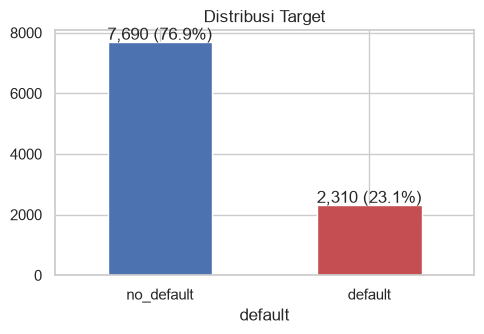

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df[TARGET].map(LABELS).value_counts()
counts.plot.bar(ax=ax, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts):
    ax.text(i, v + 80, f"{v:,} ({v / len(df):.1%})", ha="center")
ax.set_title("Distribusi Target")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

Default rate sekitar 23%, jadi kelasnya **imbalanced**. Karena itu split dibuat stratified, metrik utama memakai ROC-AUC/PR-AUC (bukan akurasi), dan `class_weight` ikut di-tuning.

> **🔄 Alur data: Distribusi Fitur Numerik per Kelas**
>
> - **Input:** `df`: 8 kolom numerik (termasuk `monthly_salary`) + target.
> - **Proses:**
>   1. Histogram tiap kolom, dipisah warna per kelas target.
>   2. `common_norm=False` membuat kedua kelas dinormalisasi sendiri-sendiri, sehingga bentuknya bisa dibandingkan walaupun jumlah default jauh lebih sedikit.
> - **Output:** Grafik. Nasabah default cenderung punya `credit_score` lebih rendah, `debt_to_income` dan `interest_rate` lebih tinggi, serta lebih banyak yang bergaji 0. `monthly_salary`, `annual_income` & `loan_amount` sangat miring.
> - **Berikutnya:** Lihat fitur kategorikal.

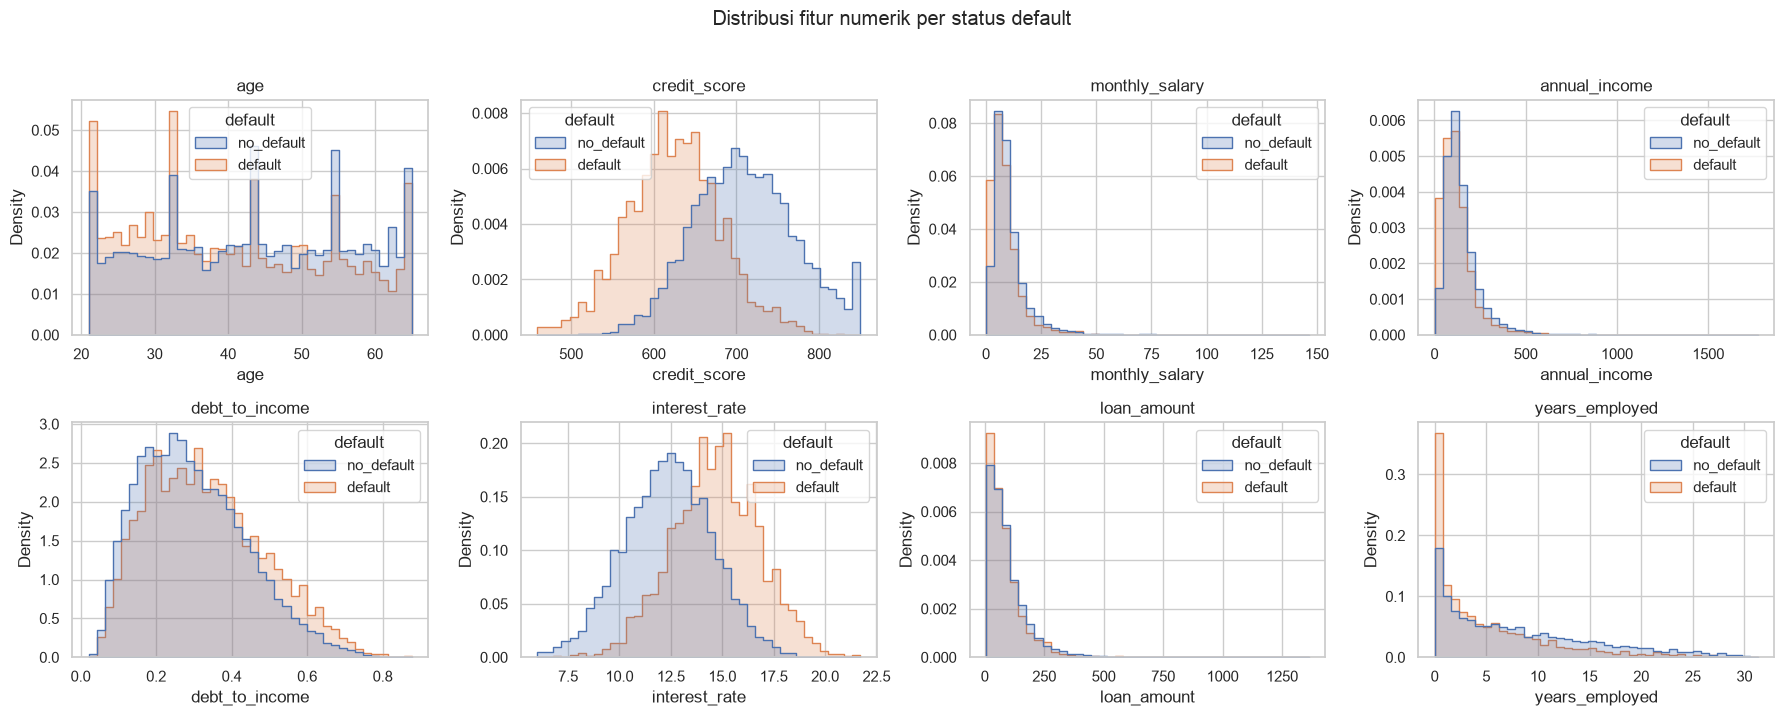

In [7]:
num_plot = ["age", "credit_score", "monthly_salary", "annual_income", "debt_to_income", "interest_rate", "loan_amount", "years_employed"]
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), num_plot):
    sns.histplot(data=df, x=col, hue=df[TARGET].map(LABELS), bins=40, stat="density",
                 common_norm=False, element="step", ax=ax)
    ax.set_title(col)
plt.suptitle("Distribusi fitur numerik per status default", y=1.02)
plt.tight_layout()
plt.show()

`monthly_salary`, `annual_income`, dan `loan_amount` sangat *right-skewed*. Karena itu keduanya tidak dipakai mentah: `annual_income` dibinning per **kuantil** (tiap bin berisi jumlah nasabah yang sama), sedangkan `monthly_salary` dibinning per **rentang gaji yang bermakna bisnis** (sekitar UMR, menengah, tinggi). Ada juga lonjakan di gaji 0, yaitu nasabah yang tidak bekerja.

> **🔄 Alur data: Default Rate per Kategori**
>
> - **Input:** `df`: 7 kolom kategorikal (termasuk `occupation` & `employee_status`) + `num_late_payments_12m` + target.
> - **Proses:**
>   1. Nilai kosong diisi teks `missing` **hanya untuk grafik** (`fillna` menghasilkan salinan, `df` asli tetap).
>   2. `groupby(kategori)` → `mean` target = **default rate** tiap kategori, `size` = jumlah nasabah.
>   3. Garis putus-putus = default rate rata-rata (23,1%).
> - **Output:** Grafik. Contoh: `employment_type=unemployed` 55%, `employee_status=probation` 36% dan `outsourcing` 26%, jauh di atas karyawan `permanent` (16,5%).
> - **Berikutnya:** Ini dasar **one-hot encoding**: karena tiap kategori punya tingkat risiko berbeda, setiap kategori nanti dijadikan kolom 0/1 sendiri agar model bisa memberi bobot berbeda.

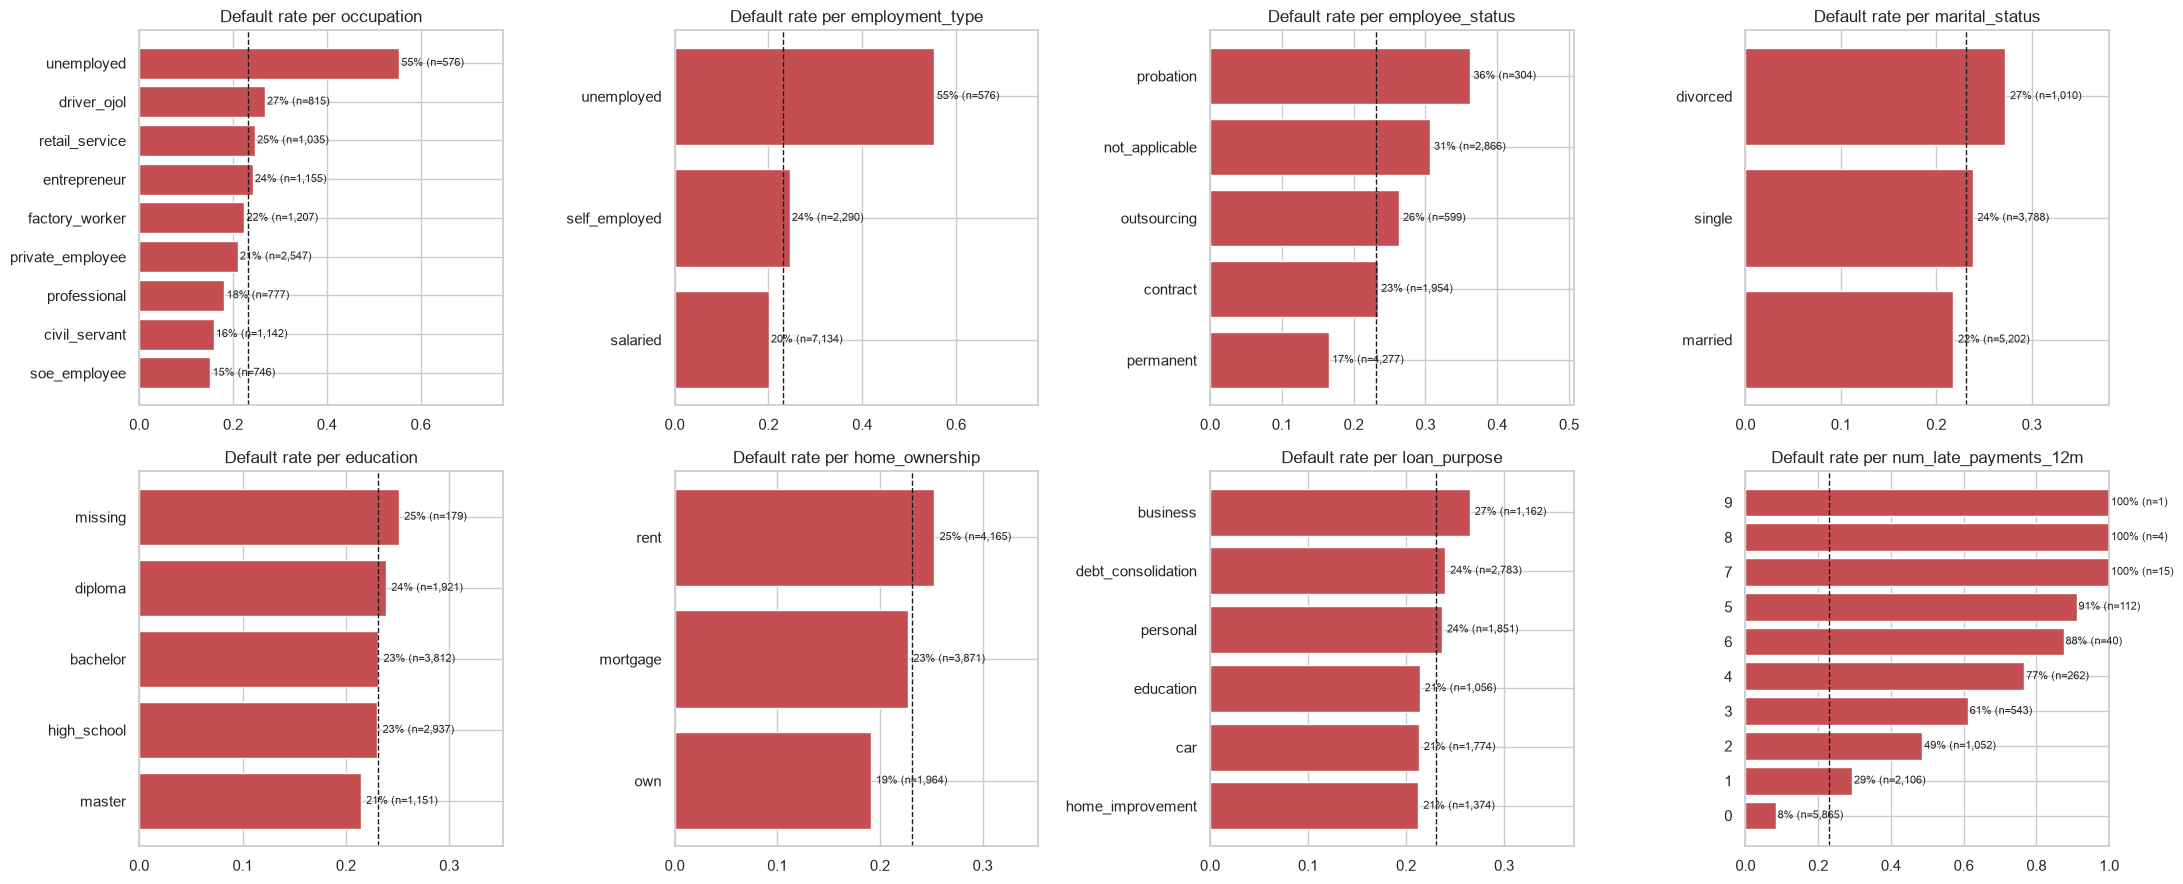

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
for ax, col in zip(axes.ravel(), CATEGORICAL_COLS + ["num_late_payments_12m"]):
    rate = df.groupby(df[col].fillna("missing"))[TARGET].agg(["mean", "size"]).sort_values("mean")
    ax.barh(rate.index.astype(str), rate["mean"], color="#C44E52")
    ax.axvline(df[TARGET].mean(), color="k", ls="--", lw=1)
    for y_, (m, s) in enumerate(rate.values):
        ax.text(m + 0.005, y_, f"{m:.0%} (n={int(s):,})", va="center", fontsize=8)
    ax.set_title(f"Default rate per {col}")
    ax.set_xlim(0, min(1, rate["mean"].max() * 1.4))
plt.tight_layout()
plt.show()

### Profil Pekerjaan, Gaji & Status Karyawan

Tiga kolom ini saling berkaitan, jadi dilihat bersama: (1) apakah kombinasi pekerjaan × status karyawan konsisten, (2) berapa gaji tiap pekerjaan, dan (3) bagaimana risikonya bila pekerjaan dan status karyawan digabung.

> **🔄 Alur data: Profil Pekerjaan, Gaji & Status Karyawan**
>
> - **Input:** `df`: `occupation`, `employee_status`, `monthly_salary`, `annual_income`, `default`.
> - **Proses:**
>   1. `pd.crosstab` menghitung jumlah nasabah untuk setiap kombinasi pekerjaan × status karyawan, untuk memastikan datanya konsisten (mis. PNS selalu `permanent`, driver/wiraswasta/unemployed selalu `not_applicable`).
>   2. `groupby(occupation)` menghitung jumlah nasabah, median gaji, median pendapatan tahunan, dan default rate per pekerjaan.
>   3. Boxplot gaji per pekerjaan (nasabah bergaji 0 dikeluarkan dari grafik ini), dengan garis acuan UMR ±3,5 jt.
>   4. `pivot_table` menghitung default rate untuk setiap kombinasi pekerjaan × status karyawan, lalu ditampilkan sebagai heatmap.
> - **Output:** Tabel & grafik (`df` tidak berubah). Kombinasi konsisten: PNS 100% `permanent`, driver ojol/wiraswasta/unemployed 100% `not_applicable`, buruh pabrik paling banyak kontrak/outsourcing. Median gaji: professional 19,4 jt, BUMN 11,1 jt, PNS 8,0 jt, retail 5,0 jt, unemployed 0. Default rate: BUMN 15,1% dan PNS 15,8% (terendah), driver ojol 26,7%, unemployed **55,4%**. Di heatmap, karyawan swasta/retail berstatus probation/outsourcing lebih berisiko daripada rekan seprofesinya yang `permanent`.
> - **Berikutnya:** Temuan ini menjadi alasan `occupation` & `employee_status` di-one-hot (setiap kategori punya risiko sendiri) dan `monthly_salary` dibinning per rentang gaji.

Jumlah nasabah: pekerjaan × status karyawan


employee_status,contract,not_applicable,outsourcing,permanent,probation,total
occupation,,,,,,
civil_servant,0,0,0,1142,0,1142
driver_ojol,0,815,0,0,0,815
entrepreneur,0,1155,0,0,0,1155
factory_worker,522,0,280,405,0,1207
private_employee,751,0,166,1436,194,2547
professional,107,320,0,350,0,777
retail_service,446,0,153,326,110,1035
soe_employee,128,0,0,618,0,746
unemployed,0,576,0,0,0,576


,n,gaji_median,pendapatan_tahunan_median,default_rate
occupation,,,,
soe_employee,746,11.120,165.15,0.151
civil_servant,1142,7.950,123.60,0.158
professional,777,19.370,267.10,0.181
private_employee,2547,9.450,139.30,0.210
factory_worker,1207,5.870,88.60,0.224
entrepreneur,1155,13.255,173.10,0.242
retail_service,1035,4.980,76.20,0.246
driver_ojol,815,5.470,75.10,0.267
unemployed,576,0.000,8.10,0.554


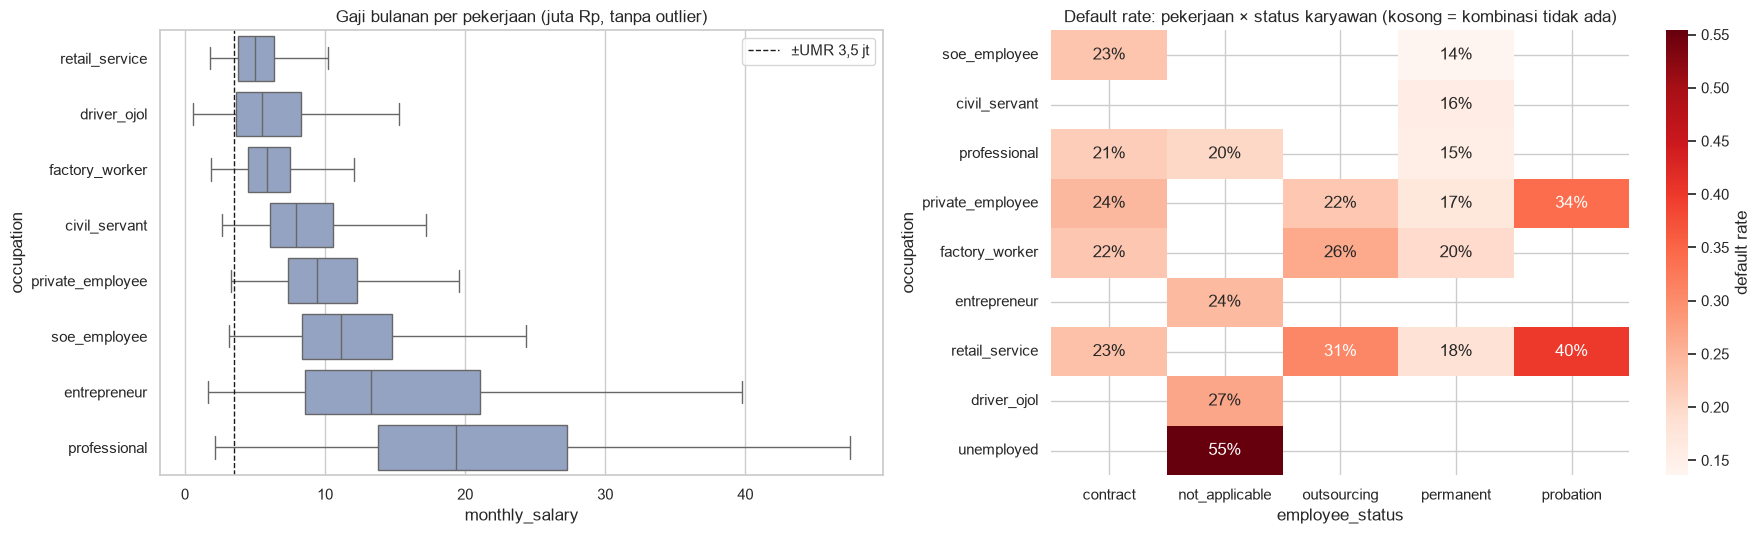

In [9]:
print("Jumlah nasabah: pekerjaan × status karyawan")
display(pd.crosstab(df["occupation"], df["employee_status"], margins=True, margins_name="total"))

job = df.groupby("occupation").agg(
    n=("default", "size"),
    gaji_median=("monthly_salary", "median"),
    pendapatan_tahunan_median=("annual_income", "median"),
    default_rate=("default", "mean"),
).sort_values("default_rate")
display(job.round(3))

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
order = df.groupby("occupation")["monthly_salary"].median().sort_values().index
sns.boxplot(data=df[df["monthly_salary"] > 0], y="occupation", x="monthly_salary", order=[o for o in order if o != "unemployed"],
            ax=axes[0], color="#8DA0CB", showfliers=False)
axes[0].axvline(3.5, color="k", ls="--", lw=1, label="±UMR 3,5 jt")
axes[0].set_title("Gaji bulanan per pekerjaan (juta Rp, tanpa outlier)")
axes[0].legend()

heat = df.pivot_table(index="occupation", columns="employee_status", values="default", aggfunc="mean").loc[job.index]
sns.heatmap(heat, annot=True, fmt=".0%", cmap="Reds", ax=axes[1], cbar_kws={"label": "default rate"})
axes[1].set_title("Default rate: pekerjaan × status karyawan (kosong = kombinasi tidak ada)")
plt.tight_layout()
plt.show()

### Preview Binning

Sebelum masuk pipeline, kita lihat dulu bagaimana bin yang dibuat memisahkan risiko. Default rate yang naik/turun secara monoton antar bin menandakan binning-nya bermakna.

> **🔄 Alur data: Preview Binning**
>
> - **Input:** `df`: `age`, `credit_score`, `monthly_salary`, `annual_income`, `default`.
> - **Proses:**
>   1. `pd.cut` dengan batas dari `DOMAIN_BINS` (batas yang **sama persis** dengan pipeline): umur → 5 kelompok, skor kredit → 5 band, gaji → 6 rentang (`no_salary` = 0, `below_3.5m`, `3.5m-5m`, `5m-10m`, `10m-20m`, `above_20m`).
>   2. `pd.qcut` membagi `annual_income` jadi 5 kuantil (masing-masing ±2.000 nasabah).
>   3. Hasilnya disimpan di DataFrame terpisah `preview`, sehingga `df` tidak berubah.
>   4. Default rate dihitung per bin.
> - **Output:** Grafik. Default rate turun dari band `poor` ke `excellent`, dari Q1 ke Q5 pendapatan, dan dari gaji `no_salary` (55%) → `below_3.5m` (27%) → `above_20m` (16%), artinya bin-nya bermakna.
> - **Berikutnya:** Ini hanya pembuktian. Binning yang sebenarnya dilakukan di pipeline, dan batas kuantilnya nanti dihitung **dari data train saja** (di sini memakai seluruh data karena hanya eksplorasi).

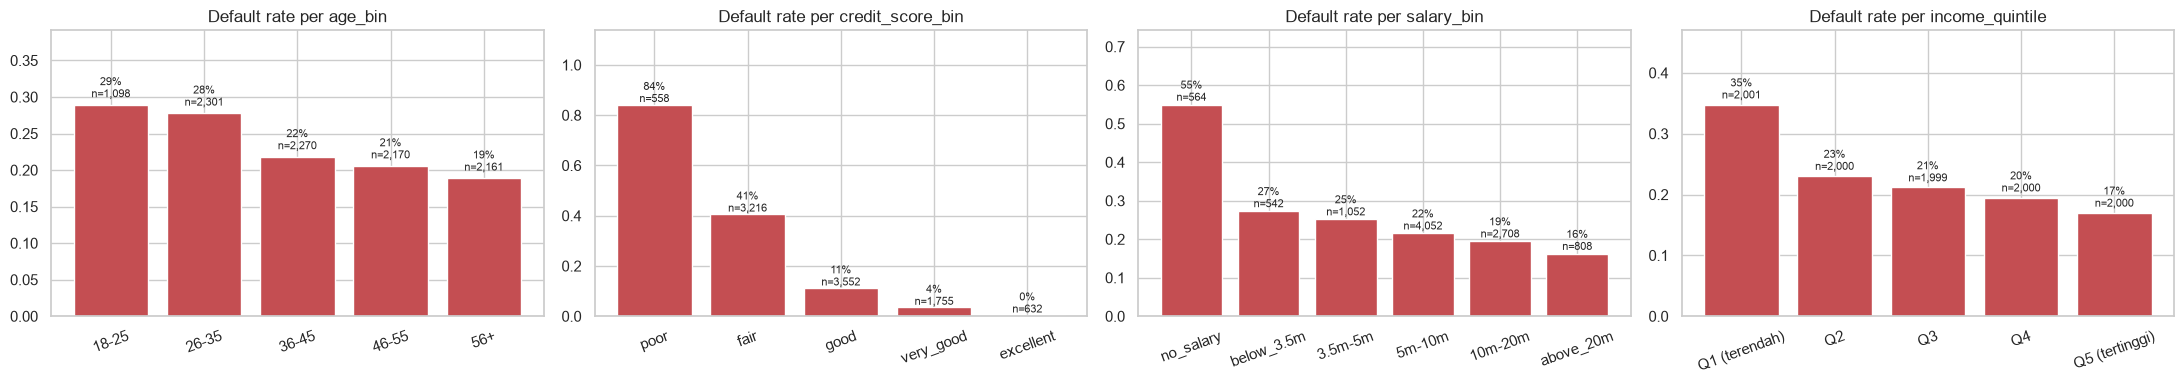

In [10]:
preview = pd.DataFrame({
    "age_bin": pd.cut(df["age"], DOMAIN_BINS["age"]["edges"], labels=DOMAIN_BINS["age"]["labels"]),
    "credit_score_bin": pd.cut(df["credit_score"], DOMAIN_BINS["credit_score"]["edges"], labels=DOMAIN_BINS["credit_score"]["labels"]),
    "salary_bin": pd.cut(df["monthly_salary"], DOMAIN_BINS["monthly_salary"]["edges"], labels=DOMAIN_BINS["monthly_salary"]["labels"]),
    "income_quintile": pd.qcut(df["annual_income"], 5, labels=["Q1 (terendah)", "Q2", "Q3", "Q4", "Q5 (tertinggi)"]),
    TARGET: df[TARGET],
})

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
for ax, col in zip(axes, ["age_bin", "credit_score_bin", "salary_bin", "income_quintile"]):
    rate = preview.groupby(col, observed=True)[TARGET].agg(["mean", "size"])
    ax.bar(rate.index.astype(str), rate["mean"], color="#C44E52")
    for x_, (m, s) in enumerate(rate.values):
        ax.text(x_, m + 0.01, f"{m:.0%}\nn={int(s):,}", ha="center", fontsize=8)
    ax.set_title(f"Default rate per {col}")
    ax.set_ylim(0, rate["mean"].max() * 1.35)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

> **🔄 Alur data: Korelasi**
>
> - **Input:** `df`: 11 kolom numerik + target.
> - **Proses:**
>   1. Korelasi Pearson antar pasangan kolom (NaN diabaikan per pasangan).
> - **Output:** Heatmap. `monthly_salary` & `annual_income` berkorelasi **0,99** (gaji adalah komponen utama pendapatan). `interest_rate` berkorelasi negatif kuat dengan `credit_score` (bunga ditentukan oleh risiko).
> - **Berikutnya:** EDA selesai. Data mulai disiapkan untuk model.

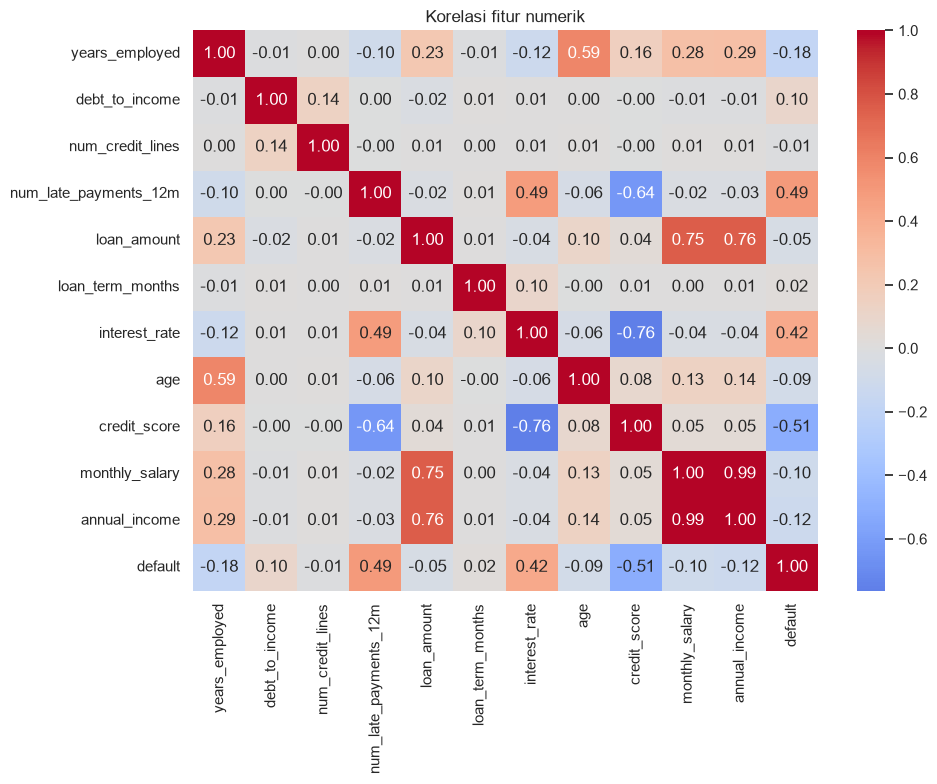

In [11]:
corr = df[NUMERIC_COLS + ["age", "credit_score", "monthly_salary", "annual_income", TARGET]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasi fitur numerik")
plt.tight_layout()
plt.show()

**Insight EDA:**
- Missing value ada di `years_employed` (~4%), `credit_score` (~3%), `monthly_salary` (~3%), dan `education` (~2%). Semuanya ditangani di pipeline. Pada `credit_score` dan `monthly_salary`, nilai kosong dijadikan kategori `missing` tersendiri, karena "tidak punya skor kredit" atau "tidak melaporkan gaji" adalah informasi risiko.
- Risiko naik tajam pada **band skor kredit poor/fair**, **tidak bekerja / gaji rendah**, status karyawan **probation & outsourcing**, DTI tinggi, dan riwayat **telat bayar**.
- **Pekerjaan** membedakan risiko: PNS & BUMN paling rendah, driver ojol, retail, dan unemployed paling tinggi.
- `monthly_salary` berkorelasi tinggi dengan `annual_income` (gaji adalah komponen utama pendapatan). Keduanya tetap dipakai karena `annual_income` juga mencakup bonus dan penghasilan lain.
- `interest_rate` berkorelasi negatif kuat dengan `credit_score` (bunga ditetapkan berbasis risiko). Regularisasi pada Logistic Regression membantu menangani hal ini.

## 4. Uji Statistik Fitur

EDA visual di Bagian 3 menunjukkan *pola*. Bagian ini menguji apakah pola itu **signifikan secara statistik** dan **seberapa besar** efeknya. Ada 4 sudut pandang yang saling melengkapi:

| Uji | Untuk | H0 (hipotesis nol) | Besar efek |
|---|---|---|---|
| **Mann-Whitney U** | fitur numerik vs default | distribusi fitur sama antara nasabah default & lancar | rank-biserial r (−1…1) |
| **Chi-square independensi** | fitur kategorikal vs default | kategori tidak berhubungan dengan default | Cramér's V (0…1) |
| **Information Value (IV)** | semua fitur (standar credit scoring) | — | IV: <0,02 tidak prediktif, 0,02–0,1 lemah, 0,1–0,3 sedang, 0,3–0,5 kuat |
| **VIF** | antar fitur numerik | — | >5 multikolinearitas sedang, >10 tinggi |

**Kenapa Mann-Whitney, bukan t-test?** Banyak fitur sangat miring (gaji, pendapatan, plafon), sehingga asumsi normalitas t-test tidak terpenuhi. Mann-Whitney berbasis peringkat, jadi tahan terhadap outlier.

**Koreksi multiple testing:** karena menguji belasan fitur sekaligus, peluang ada yang “signifikan” secara kebetulan ikut naik. p-value dikoreksi dengan **Holm-Bonferroni** (`p_holm`).

> Catatan: dengan n = 10.000, efek yang sangat kecil pun bisa signifikan. Karena itu yang dilihat bukan hanya p-value, tetapi juga **besar efeknya**.

> **🔄 Alur data: Mann-Whitney U untuk Fitur Numerik**
>
> - **Input:** `df`: 11 kolom numerik + `default`.
> - **Proses:**
>   1. Untuk setiap fitur, nilai nasabah default dan lancar dipisah (NaN dibuang per fitur).
>   2. `mann_whitney` (src/evaluation.py) menjalankan uji Mann-Whitney U dua sisi dan menghitung **rank-biserial r** = 2U/(n₁n₂) − 1. Arti r: peluang nilai nasabah default > nasabah lancar, dikurangi peluang sebaliknya.
>   3. p-value dikoreksi Holm-Bonferroni (`p_holm`) karena 11 uji dijalankan sekaligus.
>   4. Besar efek dikelompokkan: |r| < 0,1 sangat kecil, 0,1–0,3 kecil, 0,3–0,5 sedang, ≥ 0,5 besar.
> - **Output:** Tabel `num_tests` (11 baris). **9 dari 11** fitur signifikan setelah koreksi Holm. Efek **besar**: `credit_score` (r = −0,70; median 624 vs 707), `num_late_payments_12m` (+0,58), `interest_rate` (+0,56). Gaji & pendapatan efeknya kecil (r ≈ −0,18/−0,20). `loan_term_months` & `num_credit_lines` tidak signifikan.
> - **Berikutnya:** Uji yang setara untuk fitur kategorikal.

In [12]:
def fmt_p(p: float) -> str:
    return "<0,001" if p < 0.001 else f"{p:.3f}"


NUMERIC_ALL = list(DOMAIN_BINS) + QUANTILE_BIN_COLS + NUMERIC_COLS
rows = []
for col in NUMERIC_ALL:
    _, p, r = mann_whitney(df[col], df[TARGET])
    rows.append({
        "fitur": col,
        "median_default": df.loc[df[TARGET] == 1, col].median(),
        "median_lancar": df.loc[df[TARGET] == 0, col].median(),
        "p_value": p,
        "rank_biserial_r": r,
    })
num_tests = pd.DataFrame(rows).set_index("fitur")
num_tests["p_holm"] = holm_correction(num_tests["p_value"])
num_tests["signifikan (α=5%)"] = np.where(num_tests["p_holm"] < 0.05, "ya", "tidak")
num_tests["besar_efek"] = pd.cut(num_tests["rank_biserial_r"].abs(), [0, 0.1, 0.3, 0.5, 1],
                                 labels=["sangat kecil", "kecil", "sedang", "besar"], include_lowest=True)
num_tests["arah"] = np.where(num_tests["rank_biserial_r"] > 0, "lebih tinggi pada default", "lebih rendah pada default")
num_tests = num_tests.sort_values("rank_biserial_r", key=abs, ascending=False)

out = num_tests.copy()
out[["p_value", "p_holm"]] = out[["p_value", "p_holm"]].map(fmt_p)
display(out.round(3))

,median_default,median_lancar,p_value,rank_biserial_r,p_holm,signifikan (α=5%),besar_efek,arah
fitur,,,,,,,,
credit_score,624.000,707.000,"<0,001",-0.697,"<0,001",ya,besar,lebih rendah pada default
num_late_payments_12m,2.000,0.000,"<0,001",0.575,"<0,001",ya,besar,lebih tinggi pada default
interest_rate,14.690,12.390,"<0,001",0.559,"<0,001",ya,besar,lebih tinggi pada default
years_employed,2.900,6.200,"<0,001",-0.279,"<0,001",ya,kecil,lebih rendah pada default
annual_income,102.850,123.500,"<0,001",-0.195,"<0,001",ya,kecil,lebih rendah pada default
monthly_salary,7.060,8.380,"<0,001",-0.179,"<0,001",ya,kecil,lebih rendah pada default
debt_to_income,0.315,0.279,"<0,001",0.125,"<0,001",ya,kecil,lebih tinggi pada default
age,39.000,44.000,"<0,001",-0.120,"<0,001",ya,kecil,lebih rendah pada default
loan_amount,65.450,72.300,"<0,001",-0.089,"<0,001",ya,sangat kecil,lebih rendah pada default


> **🔄 Alur data: Chi-square & Cramér's V untuk Fitur Kategorikal**
>
> - **Input:** `df`: 7 kolom kategorikal + `default`.
> - **Proses:**
>   1. Tabel kontingensi kategori × default dibuat (NaN = kategori `missing`).
>   2. `stats.chi2_contingency` menguji H0: kategori dan default independen.
>   3. **Cramér's V** = √(χ² / (n × (min(baris, kolom) − 1))) mengukur kekuatan hubungan (0 = tidak ada, 1 = sempurna), tidak terpengaruh besar sampel seperti χ².
>   4. p-value dikoreksi Holm.
> - **Output:** Tabel `cat_tests` (7 baris). **6 dari 7** signifikan. Hubungan terkuat justru dari kolom pekerjaan: `occupation` (V = 0,21), `employment_type` (0,19), `employee_status` (0,15). `education` tidak signifikan (p = 0,58).
> - **Berikutnya:** Ukuran daya pisah standar perbankan (IV) untuk semua fitur.

In [13]:
rows = []
for col in CATEGORICAL_COLS:
    chi2, p, v = cramers_v(df[col], df[TARGET])
    rows.append({"fitur": col, "n_kategori": df[col].nunique(), "chi2": chi2, "p_value": p, "cramers_v": v})
cat_tests = pd.DataFrame(rows).set_index("fitur")
cat_tests["p_holm"] = holm_correction(cat_tests["p_value"])
cat_tests["signifikan (α=5%)"] = np.where(cat_tests["p_holm"] < 0.05, "ya", "tidak")
cat_tests["kekuatan"] = pd.cut(cat_tests["cramers_v"], [0, 0.1, 0.3, 1], labels=["lemah", "sedang", "kuat"], include_lowest=True)
cat_tests = cat_tests.sort_values("cramers_v", ascending=False)

out = cat_tests.copy()
out[["p_value", "p_holm"]] = out[["p_value", "p_holm"]].map(fmt_p)
display(out.round(3))

,n_kategori,chi2,p_value,cramers_v,p_holm,signifikan (α=5%),kekuatan
fitur,,,,,,,
occupation,9,424.102,"<0,001",0.206,"<0,001",ya,sedang
employment_type,3,377.916,"<0,001",0.194,"<0,001",ya,sedang
employee_status,5,230.948,"<0,001",0.152,"<0,001",ya,sedang
home_ownership,3,29.410,"<0,001",0.054,"<0,001",ya,lemah
loan_purpose,6,16.761,0.005,0.041,0.010,ya,lemah
marital_status,3,15.870,"<0,001",0.040,0.001,ya,lemah
education,4,2.851,0.583,0.017,0.583,tidak,lemah


### Information Value (IV) & Weight of Evidence (WoE)

IV adalah ukuran daya pisah fitur yang paling umum di industri perbankan. Cara menghitungnya:
1. Fitur dibagi ke grup: kuantil untuk numerik, kategori untuk kategorikal, dan grup `missing` untuk nilai kosong.
2. **WoE** per grup = ln(%nasabah lancar / %nasabah default). WoE negatif berarti grup itu **lebih berisiko** dari rata-rata.
3. **IV** = Σ (%lancar − %default) × WoE.

> **🔄 Alur data: Information Value & Weight of Evidence**
>
> - **Input:** `df`: 18 fitur + `default`.
> - **Proses:**
>   1. `woe_iv` membagi setiap fitur ke grup (numerik: 5 kuantil; kategorikal: per kategori; NaN: `missing`).
>   2. Per grup dihitung distribusi nasabah lancar (*good*) & default (*bad*), WoE = ln(%good/%bad), dan kontribusi IV.
>   3. IV per fitur dijumlahkan, lalu diberi label kekuatan (tidak prediktif / lemah / sedang / kuat).
>   4. Contoh tabel WoE ditampilkan untuk `occupation` dan `monthly_salary`.
> - **Output:** `iv_summary` + grafik, `woe_tables` (dict 18 tabel WoE). 3 fitur IV > 0,5 (`credit_score` 1,77, `interest_rate` 1,04, `num_late_payments_12m` 0,97), 6 fitur sedang (termasuk 3 kolom pekerjaan & gaji), 3 lemah, 6 tidak prediktif (IV < 0,02).
> - **Berikutnya:** Cek multikolinearitas antar fitur numerik.

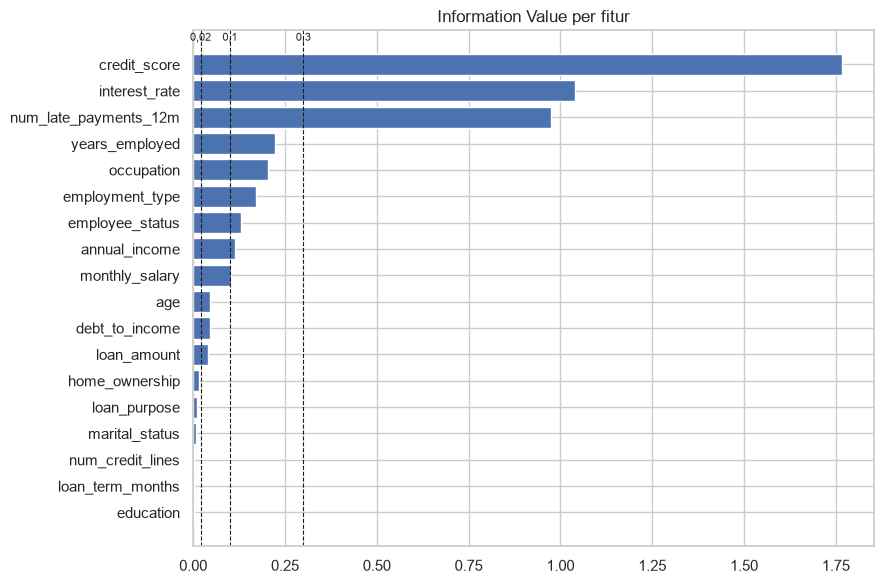

,IV,kekuatan
fitur,,
credit_score,1.7657,sangat kuat (cek leakage)
interest_rate,1.0390,sangat kuat (cek leakage)
num_late_payments_12m,0.9740,sangat kuat (cek leakage)
years_employed,0.2231,sedang
occupation,0.2027,sedang
employment_type,0.1721,sedang
employee_status,0.1303,sedang
annual_income,0.1130,sedang
monthly_salary,0.1028,sedang


Contoh WoE: occupation


,good,bad,bad_rate,woe,iv
occupation,,,,,
unemployed,257,319,0.554,-1.419,0.149
driver_ojol,597,218,0.267,-0.195,0.003
retail_service,780,255,0.246,-0.085,0.001
entrepreneur,876,279,0.242,-0.059,0.000
factory_worker,937,270,0.224,0.042,0.000
private_employee,2013,534,0.210,0.124,0.004
professional,636,141,0.181,0.304,0.007
civil_servant,961,181,0.158,0.467,0.022
soe_employee,633,113,0.151,0.520,0.017


Contoh WoE: monthly_salary (kuantil)


,good,bad,bad_rate,woe,iv
monthly_salary,,,,,
"(-0.001, 4.74]",1277,675,0.346,-0.565,0.071
"(4.74, 6.96]",1510,430,0.222,0.053,0.001
"(6.96, 9.42]",1541,410,0.210,0.121,0.003
"(9.42, 13.59]",1536,406,0.209,0.128,0.003
"(13.59, 146.5]",1609,332,0.171,0.376,0.025
missing,217,57,0.208,0.134,0.000


In [14]:
iv_rows, woe_tables = [], {}
for col in FEATURES:
    table, iv = woe_iv(df[col], df[TARGET])
    woe_tables[col] = table
    iv_rows.append({"fitur": col, "IV": iv, "kekuatan": iv_label(iv)})
iv_summary = pd.DataFrame(iv_rows).set_index("fitur").sort_values("IV", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(iv_summary.index, iv_summary["IV"], color="#4C72B0")
for x, lbl in [(0.02, "0,02"), (0.1, "0,1"), (0.3, "0,3")]:
    ax.axvline(x, color="k", ls="--", lw=0.8)
    ax.text(x, -0.9, lbl, ha="center", fontsize=8)
ax.invert_yaxis()
ax.set_title("Information Value per fitur")
plt.tight_layout()
plt.show()
display(iv_summary.round(4))

print("Contoh WoE: occupation")
display(woe_tables["occupation"].sort_values("woe").round(3))
print("Contoh WoE: monthly_salary (kuantil)")
display(woe_tables["monthly_salary"].round(3))

> **🔄 Alur data: Variance Inflation Factor**
>
> - **Input:** `df`: 11 kolom numerik (NaN diisi median, hanya untuk perhitungan ini).
> - **Proses:**
>   1. Untuk setiap fitur numerik, fitur itu diregresikan terhadap 10 fitur numerik lainnya → R².
>   2. VIF = 1 / (1 − R²). Artinya: seberapa besar variance koefisien membengkak karena fitur ini bisa ditebak dari fitur lain.
> - **Output:** `vif_table`. `annual_income` (25,5) & `monthly_salary` (24,1) VIF **tinggi** karena korelasinya 0,99. Fitur lain < 3.
> - **Berikutnya:** Hasil uji statistik dirangkum, lalu data di-split untuk modelling.

In [15]:
vif_table = vif(df[NUMERIC_ALL]).to_frame()
vif_table["status"] = pd.cut(vif_table["VIF"], [0, 5, 10, np.inf], labels=["aman", "sedang", "tinggi"])
display(vif_table.round(2))

,VIF,status
annual_income,25.47,tinggi
monthly_salary,24.05,tinggi
credit_score,2.94,aman
loan_amount,2.39,aman
interest_rate,2.36,aman
num_late_payments_12m,1.65,aman
years_employed,1.64,aman
age,1.51,aman
loan_term_months,1.03,aman
debt_to_income,1.02,aman


### Interpretasi Uji Statistik Fitur

**Fitur numerik (Mann-Whitney U)**
- **9 dari 11** fitur numerik berbeda signifikan antara nasabah default dan lancar, bahkan setelah koreksi Holm.
- Efek **besar** (|r| ≥ 0,5): `credit_score` (r = −0,70; median 624 vs 707), `num_late_payments_12m` (+0,58; median 2 vs 0), dan `interest_rate` (+0,56; 14,7% vs 12,4%).
- Gaji dan pendapatan signifikan tetapi efeknya **kecil**. Median gaji nasabah default 7,1 jt vs lancar 8,4 jt (r = −0,18). Jadi gaji membantu, tetapi bukan pembeda utama.
- `loan_term_months` (p_holm = 0,24) dan `num_credit_lines` (p_holm = 0,41) **tidak signifikan**.

**Fitur kategorikal (chi-square & Cramér's V)**
- **6 dari 7** signifikan. Hubungan terkuat justru dari **data pekerjaan** yang baru ditambahkan: `occupation` (V = 0,21), `employment_type` (0,19), dan `employee_status` (0,15). Ketiganya berkekuatan sedang.
- `home_ownership`, `loan_purpose`, dan `marital_status` signifikan tetapi lemah (V < 0,06). Dengan n = 10.000, efek kecil pun mudah signifikan, jadi besar efek lebih penting daripada p-value.
- `education` **tidak signifikan** (p = 0,58).

**Information Value**
- **3 fitur IV > 0,5**: `credit_score` (1,77), `interest_rate` (1,04), `num_late_payments_12m` (0,97). Label “cek leakage” adalah peringatan standar: IV setinggi ini sering menandakan fitur yang bocor dari target. Di kasus ini fitur-fitur tersebut **bukan leakage**, karena skor kredit dan riwayat telat bayar tersedia saat pengajuan (biro kredit/SLIK), dan `interest_rate` adalah bunga yang ditawarkan saat pengajuan (*risk-based pricing*). Catatannya: `interest_rate` sudah mengandung penilaian risiko bank sebelumnya, jadi harus dipastikan nilainya tersedia **sebelum** keputusan kredit dibuat.
- **6 fitur sedang** (0,1–0,3): `years_employed`, `occupation`, `employment_type`, `employee_status`, `annual_income`, dan `monthly_salary`. Data pekerjaan dan gaji memberi kontribusi yang berarti.
- **6 fitur tidak prediktif** (IV < 0,02): `home_ownership`, `loan_purpose`, `marital_status`, `num_credit_lines`, `loan_term_months`, `education`. Fitur ini tetap dipertahankan karena regularisasi menekan bobotnya, dan kontribusinya diuji ulang dengan permutation importance di Bagian 15.
- **WoE `occupation`** urut sesuai intuisi bisnis: `unemployed` −1,42 (default rate 55%), driver ojol −0,20, … PNS +0,47, BUMN +0,52. **WoE gaji**: kuantil terendah (≤ 4,7 jt) −0,57 dengan default rate 35%, sedangkan kuantil tertinggi (> 13,6 jt) +0,38 dengan default rate 17%.

**Multikolinearitas (VIF)**
- `annual_income` (25,5) dan `monthly_salary` (24,1) punya VIF **tinggi** karena korelasinya 0,99. Fitur numerik lain di bawah 3.
- Dampaknya: **prediksi tidak terganggu**, tetapi koefisien kedua fitur tidak bisa ditafsirkan terpisah (lihat Bagian 15). Kalau perlu model yang mudah diaudit, cukup pakai salah satunya, atau ganti `annual_income` dengan “penghasilan non-gaji”.

> Uji di bagian ini memakai seluruh `df` sebagai eksplorasi. **Tidak ada fitur yang dibuang** berdasarkan hasil ini, jadi tidak ada informasi test set yang bocor ke proses pemodelan.

## 5. Split Train / Test

> **🔄 Alur data: Split Train / Test**
>
> - **Input:** `df` (10.000 × 20).
> - **Proses:**
>   1. `X = df[FEATURES]`: 18 kolom fitur (`application_date` **tidak** ikut) (urutan kolom mengikuti `FEATURES`). `y = df['default']`: target.
>   2. `train_test_split(test_size=0.2, stratify=y, random_state=42)`: 80% train, 20% test, proporsi default dijaga sama di kedua bagian.
> - **Output:** `X_train` (**8.000 × 18**), `y_train` (8.000). `X_test` (**2.000 × 18**), `y_test` (2.000). Default rate 0,231 vs 0,231, jadi stratify bekerja.
> - **Berikutnya:** `X_test`/`y_test` **dikunci** dan baru dipakai di Bagian 13. Semua proses belajar (preprocessing, tuning, threshold) hanya memakai `X_train`.

In [16]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape} | default rate {y_train.mean():.3f}")
print(f"Test : {X_test.shape} | default rate {y_test.mean():.3f}")

Train: (8000, 18) | default rate 0.231
Test : (2000, 18) | default rate 0.231


## 6. Pipeline Preprocessing: Binning + One-Hot Encoding

Preprocessor didefinisikan di `src/features.py`. Setelah training, semua parameternya (batas bin, kategori, mean/scale) **diekspor ke JSON** dan dipakai API. Struktur `ColumnTransformer`:

```
domain_bin   : [age, credit_score, monthly_salary] -> DomainBinner (pd.cut, batas bisnis) -> OneHotEncoder
quantile_bin : [annual_income]       -> SimpleImputer(median) -> KBinsDiscretizer(5, quantile, onehot)
num          : [7 kolom numerik]     -> SimpleImputer(median) -> StandardScaler
cat          : [7 kolom kategorikal, termasuk occupation & employee_status]
                                     -> SimpleImputer('missing') -> OneHotEncoder(handle_unknown='ignore')
```

Karena semua langkah ada di dalam `Pipeline`:
- batas kuantil, median, dan kategori one-hot **hanya dipelajari dari fold train**, sehingga tidak ada leakage saat CV,
- API cukup menerima **18 kolom mentah**, dan transformasi dilakukan otomatis dari parameter di `model.json`.

> **🔄 Alur data: Fit Preprocessor (Inspeksi)**
>
> - **Input:** `X_train` (8.000 × 18, masih mentah: ada NaN, teks kategori, skala angka berbeda-beda).
> - **Proses:**
>   1. `build_preprocessor()` membuat `ColumnTransformer` berisi 4 blok paralel:
>      - `domain_bin` (`age`, `credit_score`, `monthly_salary`): `DomainBinner` mengubah angka jadi label bin (NaN → `missing`), lalu `OneHotEncoder`.
>      - `quantile_bin` (`annual_income`): isi NaN dengan median, lalu `KBinsDiscretizer` 5 kuantil langsung dalam bentuk one-hot.
>      - `num` (7 kolom numerik): isi NaN dengan median, lalu `StandardScaler` → z = (x − mean) / std.
>      - `cat` (7 kolom kategorikal, termasuk `occupation` & `employee_status`): isi NaN dengan `missing`, lalu `OneHotEncoder`.
>   2. `fit` = **mempelajari** parameter dari `X_train`: median, mean & std, batas kuantil, daftar kategori. `transform` = **menerapkan** parameter itu.
>   3. Hasil tiap blok digabung ke samping (horizontal).
> - **Output:** `X_train_transformed` (**8.000 × 64**). Semua angka, tanpa NaN, siap dimakan model.
> - **Berikutnya:** Preprocessor ini **hanya untuk dilihat**. Saat training, setiap model membuat preprocessor baru di dalam `Pipeline`, sehingga di cross-validation preprocessor di-fit ulang per fold (tidak ada kebocoran info dari fold validasi).

In [17]:
preprocessor = build_preprocessor()
preprocessor.set_output(transform="pandas")
X_train_transformed = preprocessor.fit_transform(X_train)

print(f"Fitur mentah: {X_train.shape[1]}  ->  fitur setelah transformasi: {X_train_transformed.shape[1]}")
X_train_transformed.head()

Fitur mentah: 18  ->  fitur setelah transformasi: 64


,domain_bin__age_bin_18-25,domain_bin__age_bin_26-35,domain_bin__age_bin_36-45,domain_bin__age_bin_46-55,domain_bin__age_bin_56+,domain_bin__credit_score_bin_excellent,domain_bin__credit_score_bin_fair,domain_bin__credit_score_bin_good,domain_bin__credit_score_bin_missing,domain_bin__credit_score_bin_poor,domain_bin__credit_score_bin_very_good,domain_bin__monthly_salary_bin_10m-20m,domain_bin__monthly_salary_bin_3.5m-5m,domain_bin__monthly_salary_bin_5m-10m,domain_bin__monthly_salary_bin_above_20m,domain_bin__monthly_salary_bin_below_3.5m,domain_bin__monthly_salary_bin_missing,domain_bin__monthly_salary_bin_no_salary,quantile_bin__annual_income_0.0,quantile_bin__annual_income_1.0,quantile_bin__annual_income_2.0,quantile_bin__annual_income_3.0,quantile_bin__annual_income_4.0,num__years_employed,num__debt_to_income,...,cat__employment_type_salaried,cat__employment_type_self_employed,cat__employment_type_unemployed,cat__employee_status_contract,cat__employee_status_not_applicable,cat__employee_status_outsourcing,cat__employee_status_permanent,cat__employee_status_probation,cat__marital_status_divorced,cat__marital_status_married,cat__marital_status_single,cat__education_bachelor,cat__education_diploma,cat__education_high_school,cat__education_master,cat__education_missing,cat__home_ownership_mortgage,cat__home_ownership_own,cat__home_ownership_rent,cat__loan_purpose_business,cat__loan_purpose_car,cat__loan_purpose_debt_consolidation,cat__loan_purpose_education,cat__loan_purpose_home_improvement,cat__loan_purpose_personal
2644,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.918771,-0.289101,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3337,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.991669,-0.850589,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4832,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.539699,0.223864,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
9036,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.189284,-0.427740,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1719,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.131469,1.138882,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


> **🔄 Alur data: Rincian 64 Kolom**
>
> - **Input:** `X_train_transformed` dan `preprocessor` yang sudah di-fit.
> - **Proses:**
>   1. Menghitung jumlah kolom per blok dari prefix nama kolom (`domain_bin__`, `cat__`, dst.).
>   2. Membaca batas kuantil `annual_income` yang dipelajari dari train.
> - **Output:** Rincian: `domain_bin` 18 (umur 5 + skor kredit 6 + gaji 7, keduanya termasuk `missing`), `quantile_bin` 5, `num` 7, `cat` 34 (occupation 9 + employment_type 3 + employee_status 5 + marital 3 + education 5 termasuk `missing` + home 3 + purpose 6). Total **64**. Batas kuantil pendapatan: 1,1 | 72,2 | 102,9 | 136,6 | 192,6 | 1.771,9.
> - **Berikutnya:** Telusuri satu nasabah untuk melihat transformasinya secara konkret.

In [18]:
groups = pd.Series(X_train_transformed.columns).str.split("__").str[0].value_counts()
print("Jumlah kolom hasil per blok transformer:")
print(groups.to_string())

print("\nBatas kuantil annual_income (juta Rp):",
      np.round(preprocessor.named_transformers_["quantile_bin"].named_steps["bin"].bin_edges_[0], 1))
print("\nContoh kolom hasil binning + one-hot:")
print([c for c in X_train_transformed.columns if c.startswith("domain_bin")])

Jumlah kolom hasil per blok transformer:
cat             34
domain_bin      18
num              7
quantile_bin     5

Batas kuantil annual_income (juta Rp): [1.1000e+00 7.2200e+01 1.0290e+02 1.3660e+02 1.9260e+02 1.7719e+03]

Contoh kolom hasil binning + one-hot:
['domain_bin__age_bin_18-25', 'domain_bin__age_bin_26-35', 'domain_bin__age_bin_36-45', 'domain_bin__age_bin_46-55', 'domain_bin__age_bin_56+', 'domain_bin__credit_score_bin_excellent', 'domain_bin__credit_score_bin_fair', 'domain_bin__credit_score_bin_good', 'domain_bin__credit_score_bin_missing', 'domain_bin__credit_score_bin_poor', 'domain_bin__credit_score_bin_very_good', 'domain_bin__monthly_salary_bin_10m-20m', 'domain_bin__monthly_salary_bin_3.5m-5m', 'domain_bin__monthly_salary_bin_5m-10m', 'domain_bin__monthly_salary_bin_above_20m', 'domain_bin__monthly_salary_bin_below_3.5m', 'domain_bin__monthly_salary_bin_missing', 'domain_bin__monthly_salary_bin_no_salary']


### Telusuri 1 Nasabah: dari 18 Kolom Mentah ke 64 Angka

> **🔄 Alur data: Telusuri 1 Nasabah**
>
> - **Input:** Baris pertama `X_train` beserta hasil transformasinya (baris pertama `X_train_transformed`).
> - **Proses:**
>   1. Menampilkan 18 nilai mentah nasabah tersebut.
>   2. Menampilkan kolom hasil transformasi yang **tidak bernilai 0**.
> - **Output:** Contoh nasabah: umur 41, skor kredit 723, gaji 18,7 jt/bulan, pendapatan 278,4 jt/tahun, **PNS (`civil_servant`), `salaried`, `permanent`**, single, bachelor, own, personal:
>   - `age` 41 → bin `36-45` → `domain_bin__age_bin_36-45 = 1` (4 kolom umur lain = 0)
>   - `credit_score` 723 → band `good` (670–739) → `credit_score_bin_good = 1`
>   - `monthly_salary` 18,7 → rentang `10m-20m` → `monthly_salary_bin_10m-20m = 1`
>   - `annual_income` 278,4 → kuantil ke-5 (192,6–1.771,9) → `annual_income_4.0 = 1`
>   - 7 kolom numerik → z-score, mis. `num_credit_lines` 3 → (3 − 4,99) / 1,99 ≈ **−1,00**
>   - 7 kolom kategori → masing-masing tepat satu kolom bernilai 1, mis. `occupation_civil_servant = 1`, `employment_type_salaried = 1`, `employee_status_permanent = 1`
>
>   Jadi dari 64 kolom, hanya 11 kolom bin/kategori bernilai 1 (3 bin domain + 1 bin kuantil + 7 kategori) dan 7 kolom numerik yang terisi; 46 kolom lainnya bernilai 0.
> - **Berikutnya:** Matriks seperti inilah yang diterima model. Berikutnya, kandidat model didefinisikan.

In [19]:
contoh = X_train.iloc[[0]]
print(f"SEBELUM: {contoh.shape[1]} kolom mentah")
display(contoh.T.rename(columns={contoh.index[0]: "nilai_mentah"}))

baris_t = X_train_transformed.iloc[0]
print(f"SESUDAH: {len(baris_t)} kolom; yang tidak bernilai 0 = {(baris_t != 0).sum()} kolom")
display(baris_t[baris_t != 0].to_frame("nilai_transformasi").round(4))

SEBELUM: 18 kolom mentah


,nilai_mentah
age,41
credit_score,723.0
monthly_salary,18.7
annual_income,278.4
years_employed,1.0
debt_to_income,0.264
num_credit_lines,3
num_late_payments_12m,0
loan_amount,152.4
loan_term_months,36


SESUDAH: 64 kolom; yang tidak bernilai 0 = 18 kolom


,nilai_transformasi
domain_bin__age_bin_36-45,1.0000
domain_bin__credit_score_bin_good,1.0000
domain_bin__monthly_salary_bin_10m-20m,1.0000
quantile_bin__annual_income_4.0,1.0000
num__years_employed,-0.9188
num__debt_to_income,-0.2891
num__num_credit_lines,-0.9987
num__num_late_payments_12m,-0.6486
num__loan_amount,0.6792
num__loan_term_months,-0.1254


## 7. Definisi 2 Model

| Model | Alasan |
|---|---|
| **Logistic Regression** | Standar industri untuk *credit scoring*: interpretable, koefisien mudah dijelaskan ke regulator/risk, dan cocok dengan fitur hasil binning (mirip konsep *scorecard*) |
| **Random Forest** | Non-linear, menangkap interaksi antar fitur secara otomatis, robust terhadap outlier |

> **🔄 Alur data: Definisi Kandidat Model**
>
> - **Input:** Tidak ada data (hanya definisi).
> - **Proses:**
>   1. Membuat dict `candidates` berisi 2 model + ruang hyperparameter yang akan dicoba:
>      - Logistic Regression: `C` (4 nilai) × `class_weight` (2) = **8 kombinasi**.
>      - Random Forest: `n_estimators` (1) × `max_depth` (3) × `min_samples_leaf` (3) × `class_weight` (2) = **18 kombinasi**.
>   2. Prefix `model__` berarti parameter milik langkah bernama `model` di dalam Pipeline.
> - **Output:** `candidates`.
> - **Berikutnya:** Setiap model digabung dengan preprocessor dan di-tuning.

In [20]:
candidates = {
    "logistic_regression": {
        "estimator": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        "param_grid": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__class_weight": [None, "balanced"],
        },
    },
    "random_forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),  # paralel di level GridSearch
        "param_grid": {
            "model__n_estimators": [300],
            "model__max_depth": [8, 12, None],
            "model__min_samples_leaf": [1, 5, 20],
            "model__class_weight": [None, "balanced_subsample"],
        },
    },
}

## 8. Training + Hyperparameter Tuning

> **🔄 Alur data: Training + Tuning (GridSearchCV)**
>
> - **Input:** `X_train` (8.000 × 18 **mentah**), `y_train`, `candidates`.
> - **Proses:**
>   1. Untuk setiap model dibuat `Pipeline([preprocess, model])`.
>   2. `StratifiedKFold(5)` membagi 8.000 baris train jadi 5 fold @1.600 baris.
>   3. Untuk **setiap kombinasi × setiap fold**: pipeline di-fit pada 6.400 baris (preprocessor belajar median/kuantil/kategori dari 6.400 baris ini saja), lalu diberi skor pada 1.600 baris sisanya. LR = 8 × 5 = **40 fit**, RF = 18 × 5 = **90 fit**.
>   4. Untuk setiap kombinasi dicatat rata-rata 5 metrik: ROC-AUC, PR-AUC, F1, recall, precision.
>   5. Kombinasi dengan rata-rata ROC-AUC tertinggi menang, lalu **di-refit pada 8.000 baris train penuh** (`refit=PRIMARY_METRIC`).
> - **Output:** `searches` (dict 2 objek GridSearchCV). LR terbaik: `C=10, class_weight=None`, CV ROC-AUC **0,8819**. RF terbaik (`max_depth=None, min_samples_leaf=5`): CV ROC-AUC **0,8762**.
> - **Berikutnya:** Hasil CV kedua model dirangkum dalam tabel.

In [21]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = ["roc_auc", "average_precision", "f1", "recall", "precision"]

searches = {}
for name, cfg in candidates.items():
    pipe = Pipeline([("preprocess", build_preprocessor()), ("model", cfg["estimator"])])
    gs = GridSearchCV(pipe, cfg["param_grid"], cv=cv, scoring=scoring, refit=PRIMARY_METRIC, n_jobs=-1)
    gs.fit(X_train, y_train)
    searches[name] = gs
    print(f"{name:<20} CV {PRIMARY_METRIC}={gs.best_score_:.4f} | {gs.best_params_}")

logistic_regression  CV roc_auc=0.8819 | {'model__C': 10, 'model__class_weight': None}


random_forest        CV roc_auc=0.8762 | {'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 300}


## 9. Perbandingan Model (Cross-Validation)

> **🔄 Alur data: Ringkasan Skor CV**
>
> - **Input:** `searches[...].cv_results_` (skor semua kombinasi).
> - **Proses:**
>   1. Untuk tiap model diambil baris kombinasi terbaik (`best_index_`), lalu mean & std kelima metrik.
>   2. Diurutkan berdasarkan CV ROC-AUC.
> - **Output:** `cv_summary` (2 baris × 10 kolom).
> - **Berikutnya:** Divisualisasikan, lalu baris teratas dipilih.

In [22]:
rows = []
for name, gs in searches.items():
    i, res = gs.best_index_, gs.cv_results_
    row = {"model": name}
    for m in scoring:
        row[f"cv_{m}"] = res[f"mean_test_{m}"][i]
        row[f"cv_{m}_std"] = res[f"std_test_{m}"][i]
    rows.append(row)

cv_summary = pd.DataFrame(rows).set_index("model").sort_values(f"cv_{PRIMARY_METRIC}", ascending=False)
cv_summary.round(4)

,cv_roc_auc,cv_roc_auc_std,cv_average_precision,cv_average_precision_std,cv_f1,cv_f1_std,cv_recall,cv_recall_std,cv_precision,cv_precision_std
model,,,,,,,,,,
logistic_regression,0.8819,0.0043,0.7255,0.0132,0.6199,0.0132,0.5384,0.0164,0.7308,0.0155
random_forest,0.8762,0.0046,0.7181,0.0108,0.5753,0.0038,0.4600,0.0030,0.7681,0.0133


> **🔄 Alur data: Grafik Perbandingan CV**
>
> - **Input:** `cv_summary`.
> - **Proses:**
>   1. Bar chart mean, dengan error bar = std antar 5 fold.
> - **Output:** Grafik. Selisih ROC-AUC LR vs RF (0,006) lebih besar dari std antar fold (±0,004), jadi LR konsisten sedikit lebih baik. Recall keduanya di threshold 0,5 masih rendah (LR 0,54), dan ini diperbaiki dengan tuning threshold.
> - **Berikutnya:** Pemilihan model.

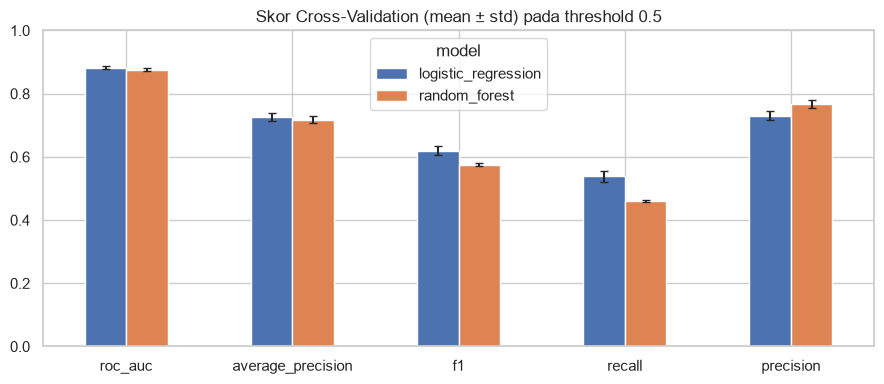

In [23]:
plot_df = cv_summary[[f"cv_{m}" for m in scoring]].rename(columns=lambda c: c.replace("cv_", ""))
err_df = cv_summary[[f"cv_{m}_std" for m in scoring]].rename(columns=lambda c: c.replace("cv_", "").replace("_std", ""))

ax = plot_df.T.plot.bar(yerr=err_df.T, figsize=(9, 4), capsize=3)
ax.set_title("Skor Cross-Validation (mean ± std) pada threshold 0.5")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

F1, recall, dan precision di atas masih memakai threshold default 0.5. Model dengan `class_weight=None` biasanya punya recall rendah di threshold tersebut, dan ini akan diperbaiki di langkah tuning threshold.

## 10. Cross-Validation Lanjutan

Bagian 8–9 memakai **satu kali** 5-fold CV. Hasilnya bergantung pada cara data dibagi secara acak. Bagian ini menjawab 4 pertanyaan statistik:

| # | Pertanyaan | Metode |
|---|---|---|
| 10.1 | Seberapa **stabil** skor CV jika pembagian fold diubah? | **Repeated Stratified K-Fold** (5 fold × 5 ulangan = 25 skor per model) dengan CI terkoreksi |
| 10.2 | Apakah selisih LR vs RF **signifikan** atau kebetulan? | **Corrected resampled t-test** (Nadeau-Bengio) + **Wilcoxon signed-rank** |
| 10.3 | Apakah skor CV **terlalu optimis** karena dipakai untuk tuning? | **Nested CV** (tuning di inner loop, penilaian di outer loop) |
| 10.4 | Apakah model kekurangan data atau overfit? | **Learning curve** |

### 10.1 Repeated Stratified K-Fold

> **🔄 Alur data: Repeated Stratified K-Fold (5 × 5)**
>
> - **Input:** Konfigurasi terbaik kedua model (`searches[...].best_estimator_`), `X_train`, `y_train`.
> - **Proses:**
>   1. `RepeatedStratifiedKFold` mengulang 5-fold CV sebanyak 5 kali dengan pengacakan berbeda, sehingga ada **25 pasangan train/validasi**.
>   2. Setiap model di-`clone` (hyperparameter sama, belum dilatih), lalu `cross_validate` melatih & menilai 25× (ROC-AUC, PR-AUC, Brier).
>   3. Untuk setiap metrik dihitung mean, std, min, max, dan **95% CI terkoreksi** (`corrected_mean_ci`: SE × √(1/k + n_test/n_train)).
> - **Output:** `rep_results` (25 skor × 3 metrik × 2 model) dan `rep_summary`. LR: ROC-AUC **0,8812 ± 0,0060** (CI terkoreksi 0,875–0,888). RF: 0,8764 ± 0,0056.
> - **Berikutnya:** 25 skor AUC dipakai untuk menguji apakah selisih kedua model signifikan.

In [24]:
rkf = RepeatedStratifiedKFold(n_splits=CV_FOLDS, n_repeats=5, random_state=RANDOM_STATE)
rep_scoring = ["roc_auc", "average_precision", "neg_brier_score"]
N_TEST_FOLD = len(X_train) // CV_FOLDS
N_TRAIN_FOLD = len(X_train) - N_TEST_FOLD

rep_results = {
    name: cross_validate(clone(gs.best_estimator_), X_train, y_train, cv=rkf, scoring=rep_scoring, n_jobs=-1)
    for name, gs in searches.items()
}

rows = []
for name, res in rep_results.items():
    for m in rep_scoring:
        vals = res[f"test_{m}"] * (-1 if m.startswith("neg_") else 1)
        mean, lo, hi = corrected_mean_ci(vals, N_TRAIN_FOLD, N_TEST_FOLD)
        rows.append({"model": name, "metrik": m.replace("neg_", ""), "mean": mean, "std": vals.std(ddof=1),
                     "ci95_lower": lo, "ci95_upper": hi, "min": vals.min(), "max": vals.max(), "n_skor": len(vals)})
rep_summary = pd.DataFrame(rows).set_index(["model", "metrik"])
rep_summary.round(4)

mean     std  ci95_lower  ci95_upper  \
model               metrik                                                      
logistic_regression roc_auc            0.8812  0.0060      0.8746      0.8879   
                    average_precision  0.7235  0.0176      0.7039      0.7431   
                    brier_score        0.1087  0.0034      0.1049      0.1126   
random_forest       roc_auc            0.8764  0.0056      0.8701      0.8827   
                    average_precision  0.7158  0.0165      0.6976      0.7341   
                    brier_score        0.1116  0.0026      0.1088      0.1145   

                                          min     max  n_skor  
model               metrik                                     
logistic_regression roc_auc            0.8692  0.8939      25  
                    average_precision  0.6914  0.7518      25  
                    brier_score        0.1031  0.1153      25  
random_forest       roc_auc            0.8679  0.8909      25  
                    average_precision  0.6867  0.7478      25  
                    brier_score        0.1062  0.1154      25

### 10.2 Uji Signifikansi Perbedaan Dua Model

Ke-25 skor kedua model **berpasangan**: fold ke-i memakai data yang sama untuk kedua model. Karena itu ujinya memakai **selisih per fold**.

- **t-test berpasangan biasa** terlalu optimis karena data train antar-fold tumpang tindih, sehingga skor-skornya tidak independen. Hasilnya ditampilkan hanya sebagai pembanding.
- **Corrected resampled t-test** (Nadeau & Bengio, 2003) mengoreksi variance dengan faktor (1/k + n_test/n_train). Ini **uji utama**.
- **Wilcoxon signed-rank** adalah versi non-parametrik (tidak mengasumsikan normalitas).

H0: rata-rata ROC-AUC kedua model sama. Jika p < 0,05, H0 ditolak dan perbedaannya signifikan.

> **🔄 Alur data: Uji Signifikansi LR vs RF**
>
> - **Input:** 25 pasangan skor ROC-AUC dari `rep_results`.
> - **Proses:**
>   1. Selisih AUC per fold dihitung (model A − model B).
>   2. Tiga uji dijalankan pada selisih tersebut: t-test berpasangan naif (pembanding), corrected resampled t-test (utama), dan Wilcoxon signed-rank (non-parametrik).
>   3. Grafik kiri: 25 skor per model, dengan garis abu-abu menghubungkan fold yang sama. Grafik kanan: histogram selisih.
> - **Output:** `cv_tests` + 2 grafik. LR menang di **24/25** fold (Δ AUC +0,0048). Corrected t-test p = **0,016**, Wilcoxon p < 0,001, jadi signifikan. t-test naif (p ≈ 0) terlalu optimis.
> - **Berikutnya:** Mengukur bias optimis dari proses tuning dengan nested CV.

logistic_regression vs random_forest: rata-rata selisih AUC = +0.0048 | logistic_regression menang di 24 dari 25 fold


,statistik,p_value,keputusan (α=5%)
uji,,,
"t-test berpasangan (naif, pembanding)",6.9714,0.0000,tolak H0: berbeda signifikan
Corrected resampled t-test (utama),2.5891,0.0161,tolak H0: berbeda signifikan
Wilcoxon signed-rank,5.0000,0.0000,tolak H0: berbeda signifikan


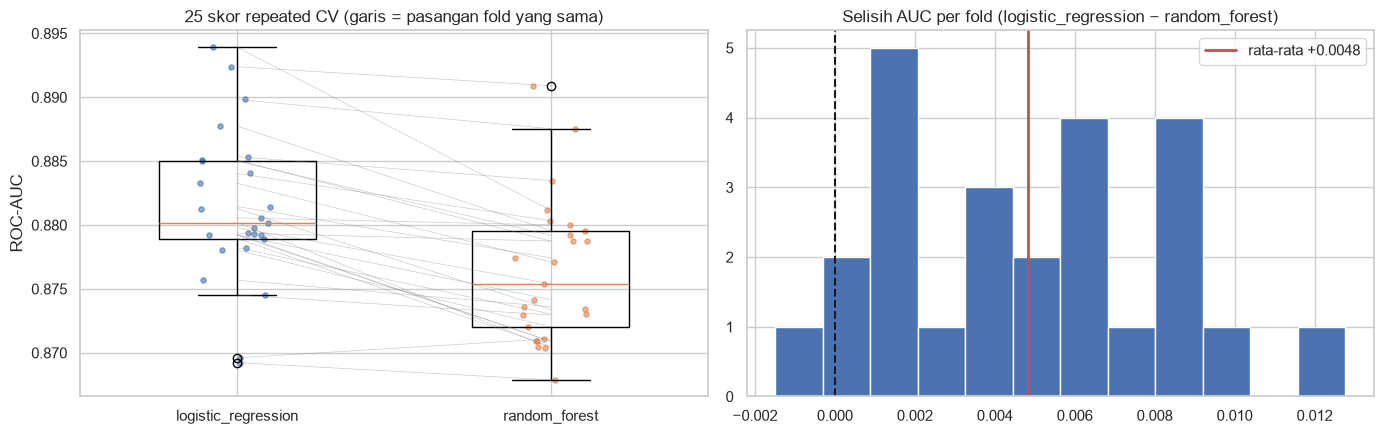

In [25]:
name_a, name_b = cv_summary.index[0], cv_summary.index[1]
auc_a = rep_results[name_a]["test_roc_auc"]
auc_b = rep_results[name_b]["test_roc_auc"]

corrected = corrected_resampled_ttest(auc_a, auc_b, N_TRAIN_FOLD, N_TEST_FOLD)
naive = stats.ttest_rel(auc_a, auc_b)
wilcoxon = stats.wilcoxon(auc_a, auc_b)

cv_tests = pd.DataFrame({
    "uji": ["t-test berpasangan (naif, pembanding)", "Corrected resampled t-test (utama)", "Wilcoxon signed-rank"],
    "statistik": [naive.statistic, corrected["t"], wilcoxon.statistic],
    "p_value": [naive.pvalue, corrected["p_value"], wilcoxon.pvalue],
}).set_index("uji")
cv_tests["keputusan (α=5%)"] = np.where(cv_tests["p_value"] < 0.05, "tolak H0: berbeda signifikan", "gagal tolak H0: tidak signifikan")
print(f"{name_a} vs {name_b}: rata-rata selisih AUC = {corrected['mean_diff']:+.4f} | "
      f"{name_a} menang di {(auc_a > auc_b).sum()} dari {len(auc_a)} fold")
display(cv_tests.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for i, (name, vals) in enumerate([(name_a, auc_a), (name_b, auc_b)]):
    axes[0].boxplot(vals, positions=[i], widths=0.5)
    axes[0].scatter(np.full(len(vals), i) + np.random.default_rng(i).uniform(-0.12, 0.12, len(vals)), vals, s=14, alpha=0.6)
for va, vb in zip(auc_a, auc_b):
    axes[0].plot([0, 1], [va, vb], color="grey", lw=0.5, alpha=0.4)
axes[0].set_xticks([0, 1], [name_a, name_b])
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("25 skor repeated CV (garis = pasangan fold yang sama)")

diff = auc_a - auc_b
axes[1].hist(diff, bins=12, color="#4C72B0", edgecolor="white")
axes[1].axvline(0, color="k", ls="--")
axes[1].axvline(diff.mean(), color="#C44E52", lw=2, label=f"rata-rata {diff.mean():+.4f}")
axes[1].set_title(f"Selisih AUC per fold ({name_a} − {name_b})")
axes[1].legend()
plt.tight_layout()
plt.show()

### 10.3 Nested Cross-Validation

Skor `best_score_` dari GridSearchCV dipakai untuk **memilih** hyperparameter dan model, sehingga sedikit bias ke atas (*optimistic bias*). Nested CV mengukur performa **seluruh prosedur** (tuning + pemilihan model) secara jujur:

```
Outer loop (5 fold)  ── untuk setiap outer fold:
   ├─ Inner loop: GridSearchCV 3-fold untuk KEDUA model di outer-train
   ├─ Pilih model dengan skor inner terbaik
   └─ Nilai model terpilih di outer-validation (data yang tidak pernah dilihat saat tuning)
```

Selisih antara skor non-nested dan nested = **optimisme** dari proses tuning.

> **🔄 Alur data: Nested Cross-Validation**
>
> - **Input:** `X_train`, `y_train`, `candidates` (2 model + grid hyperparameter).
> - **Proses:**
>   1. Outer loop 5-fold: setiap fold menyisihkan ±1.600 baris sebagai **outer-validation** yang tidak ikut tuning.
>   2. Di ±6.400 baris outer-train, GridSearchCV 3-fold (inner loop) dijalankan untuk **kedua** model.
>   3. Model dengan skor inner terbaik dipilih, lalu dinilai di outer-validation.
>   4. Rata-rata 5 skor outer = estimasi jujur performa **seluruh prosedur** (tuning + pemilihan). Selisihnya dengan `best_score_` = optimisme.
> - **Output:** `nested` (5 baris). Nested AUC **0,8808** (CI 0,864–0,898) vs non-nested 0,8819, jadi optimisme hanya **+0,001**. LR terpilih di 5/5 outer fold.
> - **Berikutnya:** Diagnosis bias/variance dengan learning curve.

In [26]:
outer_cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE + 1)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

nested_rows = []
for fold, (tr_idx, va_idx) in enumerate(outer_cv.split(X_train, y_train), 1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    inner = {}
    for name, cfg in candidates.items():
        pipe = Pipeline([("preprocess", build_preprocessor()), ("model", clone(cfg["estimator"]))])
        inner[name] = GridSearchCV(pipe, cfg["param_grid"], cv=inner_cv, scoring=PRIMARY_METRIC, n_jobs=-1).fit(X_tr, y_tr)
    chosen = max(inner, key=lambda n: inner[n].best_score_)
    row = {"outer_fold": fold, "model_terpilih": chosen, "inner_cv_auc": inner[chosen].best_score_}
    for name, gs in inner.items():
        row[f"outer_auc_{name}"] = roc_auc_score(y_va, gs.predict_proba(X_va)[:, 1])
    row["outer_auc_terpilih"] = row[f"outer_auc_{chosen}"]
    row["params_terpilih"] = inner[chosen].best_params_
    nested_rows.append(row)

nested = pd.DataFrame(nested_rows).set_index("outer_fold")
nested_mean, nested_lo, nested_hi = mean_ci(nested["outer_auc_terpilih"])
non_nested = searches[cv_summary.index[0]].best_score_
optimism = non_nested - nested_mean

display(nested.round(4))
print(f"Nested CV ROC-AUC     : {nested_mean:.4f} (95% CI {nested_lo:.4f}–{nested_hi:.4f})")
print(f"Non-nested (Bagian 8) : {non_nested:.4f}")
print(f"Optimisme tuning      : {optimism:+.4f}")
print(f"Model terpilih per outer fold: {nested['model_terpilih'].value_counts().to_dict()}")

,model_terpilih,inner_cv_auc,outer_auc_logistic_regression,outer_auc_random_forest,outer_auc_terpilih,params_terpilih
outer_fold,,,,,,
1,logistic_regression,0.8853,0.8685,0.8631,0.8685,"{'model__C': 10, 'model__class_weight': 'balan..."
2,logistic_regression,0.8811,0.8690,0.8650,0.8690,"{'model__C': 1, 'model__class_weight': None}"
3,logistic_regression,0.8755,0.8997,0.8959,0.8997,"{'model__C': 1, 'model__class_weight': None}"
4,logistic_regression,0.8767,0.8913,0.8859,0.8913,"{'model__C': 1, 'model__class_weight': None}"
5,logistic_regression,0.8806,0.8758,0.8692,0.8758,"{'model__C': 10, 'model__class_weight': None}"


Nested CV ROC-AUC     : 0.8808 (95% CI 0.8635–0.8982)
Non-nested (Bagian 8) : 0.8819
Optimisme tuning      : +0.0010
Model terpilih per outer fold: {'logistic_regression': 5}


### 10.4 Learning Curve

Model dilatih dengan porsi data train yang makin besar (10% → 100%), lalu skor train dan skor validasi (CV) dibandingkan:
- **Gap besar** antara train dan validasi menandakan *overfitting* (variance tinggi).
- **Kedua kurva rendah dan sudah datar** menandakan *underfitting* (bias tinggi), sehingga model perlu fitur yang lebih baik.
- **Kurva validasi masih naik** menandakan tambahan data masih bisa menaikkan performa.

> **🔄 Alur data: Learning Curve**
>
> - **Input:** Konfigurasi model terbaik, `X_train`, `y_train`.
> - **Proses:**
>   1. `learning_curve` melatih model dengan 8 ukuran data (10% … 100% dari porsi train tiap fold), masing-masing dengan 5-fold CV.
>   2. Untuk setiap ukuran dicatat AUC di data train-nya sendiri dan AUC validasi, lalu dihitung gap-nya.
> - **Output:** `learning` (8 baris) + grafik. Gap train–validasi turun dari 0,065 (640 baris) ke **0,006** (6.400 baris). AUC validasi mendatar di ±0,88 setelah ±4.000 baris.
> - **Berikutnya:** Bukti CV sudah lengkap, jadi model terbaik dipilih resmi (Bagian 11).

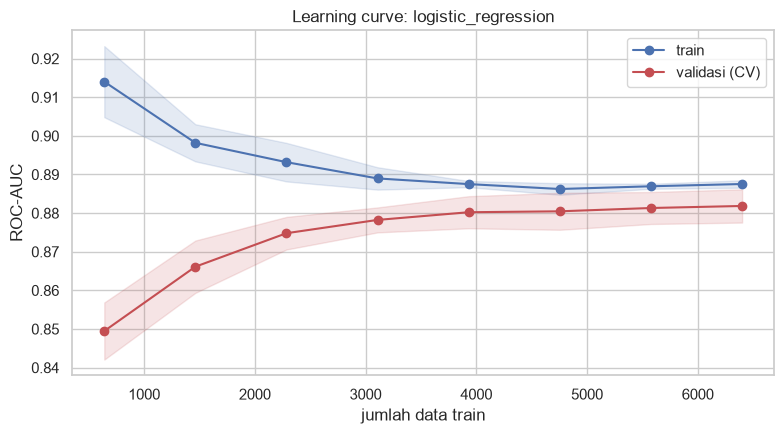

,n_train,auc_train,auc_valid,gap
0,640,0.9140,0.8495,0.0646
1,1462,0.8982,0.8661,0.0321
2,2285,0.8932,0.8748,0.0184
3,3108,0.8890,0.8782,0.0107
4,3931,0.8875,0.8802,0.0073
5,4754,0.8862,0.8805,0.0058
6,5577,0.8869,0.8813,0.0056
7,6400,0.8875,0.8819,0.0057


In [27]:
lc_sizes, lc_train, lc_valid = learning_curve(
    clone(searches[cv_summary.index[0]].best_estimator_), X_train, y_train, cv=cv, scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1, shuffle=True, random_state=RANDOM_STATE,
)
fig, ax = plt.subplots(figsize=(8, 4.5))
for scores, label, color in [(lc_train, "train", "#4C72B0"), (lc_valid, "validasi (CV)", "#C44E52")]:
    ax.plot(lc_sizes, scores.mean(axis=1), "o-", color=color, label=label)
    ax.fill_between(lc_sizes, scores.mean(axis=1) - scores.std(axis=1), scores.mean(axis=1) + scores.std(axis=1), color=color, alpha=0.15)
ax.set_xlabel("jumlah data train")
ax.set_ylabel("ROC-AUC")
ax.set_title(f"Learning curve: {cv_summary.index[0]}")
ax.legend()
plt.tight_layout()
plt.show()

learning = pd.DataFrame({"n_train": lc_sizes, "auc_train": lc_train.mean(axis=1), "auc_valid": lc_valid.mean(axis=1)})
learning["gap"] = learning["auc_train"] - learning["auc_valid"]
display(learning.round(4))

### Interpretasi Cross-Validation Lanjutan

**10.1 Stabilitas skor**
- LR: ROC-AUC **0,8812 ± 0,0060** dari 25 evaluasi (rentang 0,869–0,894), 95% CI terkoreksi **0,875–0,888**. RF: 0,8764 ± 0,0056.
- Std ±0,006 berarti skor **stabil** terhadap cara data dibagi. LR juga sedikit lebih baik di PR-AUC (0,724 vs 0,716) dan Brier (0,109 vs 0,112; makin kecil makin baik).

**10.2 Apakah LR benar-benar lebih baik?**
- LR menang di **24 dari 25** fold, dengan rata-rata selisih +0,0048 AUC.
- t-test naif memberi t = 6,97 (p ≈ 0) dan **terlalu optimis**. Corrected resampled t-test memberi t = 2,59, **p = 0,016**, dan Wilcoxon p < 0,001. Jadi LR **signifikan** lebih baik pada α = 5%.
- Namun selisihnya **kecil secara praktis** (0,005 AUC). Signifikan secara statistik tidak sama dengan besar secara bisnis.

**10.3 Apakah skor CV terlalu optimis?**
- Nested CV memberi **0,8808** (CI 0,864–0,898) vs non-nested 0,8819, jadi optimisme hanya **+0,001**. Skor CV di Bagian 9 bisa dipercaya karena grid hyperparameter kecil, sehingga tuning tidak “menghafal” fold.
- LR terpilih di **5/5** outer fold, jadi keputusan memilih LR **stabil**.
- Hyperparameter terpilih bervariasi (`C` = 1 atau 10; `class_weight` None/balanced). Artinya permukaan skornya datar dan performa **tidak sensitif** terhadap pilihan ini.

**10.4 Bias atau variance?**
- Gap train–validasi turun dari 0,065 (640 baris) ke **0,006** (6.400 baris), sehingga **tidak overfit**.
- AUC validasi naik 0,850 → 0,882 dan **mulai datar** setelah ±4.000 baris. Menambah data dengan fitur yang sama hanya memberi peningkatan kecil. Untuk naik lebih jauh dibutuhkan **fitur baru** (mis. mutasi rekening atau data biro kredit yang lebih rinci).

## 11. Pilih Model Terbaik

Kriteria: **CV ROC-AUC tertinggi**, karena ROC-AUC mengukur kemampuan model *mengurutkan* risiko dan tidak bergantung threshold. Test set belum disentuh.

> **🔄 Alur data: Pilih Model Terbaik**
>
> - **Input:** `cv_summary`, `searches`.
> - **Proses:**
>   1. Mengambil nama model di baris teratas.
>   2. `best_estimator_` = pipeline (preprocessor + model) yang **sudah di-refit di 8.000 baris train**.
> - **Output:** `best_name = 'logistic_regression'`, `best_model` (pipeline siap prediksi), `best_search`.
> - **Berikutnya:** Menentukan threshold keputusan untuk `best_model`.

In [28]:
best_name = cv_summary.index[0]
best_search = searches[best_name]
best_model = best_search.best_estimator_

print(f"Model terpilih : {best_name}")
print(f"CV ROC-AUC     : {best_search.best_score_:.4f}")
print(f"Hyperparameter : {best_search.best_params_}")

Model terpilih : logistic_regression
CV ROC-AUC     : 0.8819
Hyperparameter : {'model__C': 10, 'model__class_weight': None}


## 12. Tuning Threshold Keputusan

Di bank, salah tolak nasabah baik (*false positive*) dan salah approve nasabah yang akan default (*false negative*) punya biaya berbeda. Threshold 0.5 belum tentu optimal.

Threshold dipilih dari **prediksi out-of-fold di data train** (dengan `cross_val_predict`), lalu diambil yang memaksimalkan **F1** kelas default. Test set tetap tidak dipakai.

> **🔄 Alur data: Tuning Threshold**
>
> - **Input:** Konfigurasi `best_model`, `X_train`, `y_train`.
> - **Proses:**
>   1. `cross_val_predict` melatih ulang pipeline 5× (5 fold). Setiap baris train diprediksi oleh model yang **tidak pernah melihat baris itu**, sehingga didapat 8.000 probabilitas yang “jujur” (*out-of-fold*).
>   2. `precision_recall_curve` menghitung precision & recall di setiap kemungkinan threshold, lalu F1 dihitung dari keduanya.
>   3. Threshold dengan F1 tertinggi dipilih.
> - **Output:** `oof_proba` (8.000 probabilitas), **`THRESHOLD = 0,302`** (F1 OOF 0,657 vs 0,620 bila memakai 0,5). Threshold jauh di bawah 0,5 karena model terpilih memakai `class_weight=None`, sehingga probabilitasnya mengikuti default rate asli (23%). Untuk menangkap lebih banyak default, batasnya perlu diturunkan.
> - **Berikutnya:** `THRESHOLD` dipakai untuk evaluasi test dan disimpan ke `model.json` (dipakai API).

Threshold optimal (max F1 OOF): 0.302
  OOF precision=0.597 | recall=0.731 | F1=0.657
  vs threshold 0.5: F1=0.620


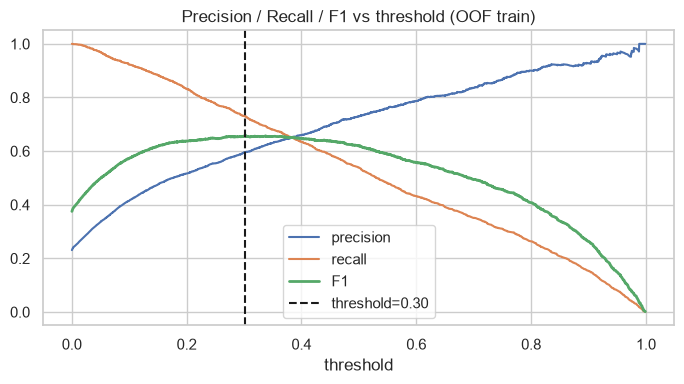

In [29]:
oof_proba = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof_proba)
f1s = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
best_idx = int(np.argmax(f1s))
THRESHOLD = round(float(thr[best_idx]), 4)

print(f"Threshold optimal (max F1 OOF): {THRESHOLD}")
print(f"  OOF precision={prec[best_idx]:.3f} | recall={rec[best_idx]:.3f} | F1={f1s[best_idx]:.3f}")
print(f"  vs threshold 0.5: F1={f1_score(y_train, oof_proba >= 0.5):.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thr, prec[:-1], label="precision")
ax.plot(thr, rec[:-1], label="recall")
ax.plot(thr, f1s, label="F1", lw=2)
ax.axvline(THRESHOLD, color="k", ls="--", label=f"threshold={THRESHOLD:.2f}")
ax.set_xlabel("threshold")
ax.set_title("Precision / Recall / F1 vs threshold (OOF train)")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Evaluasi Akhir di Test Set

> **🔄 Alur data: Evaluasi di Test Set**
>
> - **Input:** Model terbaik dari kedua GridSearch, **`X_test`/`y_test` (dipakai untuk pertama kalinya)**.
> - **Proses:**
>   1. `predict_proba` → P(default) untuk 2.000 nasabah test.
>   2. P ≥ threshold → prediksi 1, selain itu 0.
>   3. Menghitung 6 metrik. Ada 3 baris: LR @0,5, RF @0,5 (sebagai pembanding), dan **LR @0,302 (model final)**.
> - **Output:** `test_summary`. Final: ROC-AUC 0,884, PR-AUC 0,722, recall 0,714, precision 0,606, akurasi 0,827. Skor test ≈ skor CV, artinya model tidak overfit. Threshold 0,302 menaikkan recall dari 0,526 (threshold 0,5) ke 0,714.
> - **Berikutnya:** Rincian kesalahan model final.

In [30]:
def evaluate(model, X_, y_, threshold) -> dict:
    proba = model.predict_proba(X_)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_, proba),
        "pr_auc": average_precision_score(y_, proba),
        "f1": f1_score(y_, pred),
        "recall": recall_score(y_, pred),
        "precision": precision_score(y_, pred),
        "accuracy": accuracy_score(y_, pred),
    }

test_summary = pd.DataFrame({
    f"{name} @0.5": evaluate(gs.best_estimator_, X_test, y_test, 0.5) for name, gs in searches.items()
}).T
test_summary.loc[f"{best_name} @{THRESHOLD:.2f} (final)"] = evaluate(best_model, X_test, y_test, THRESHOLD)
test_summary.round(4)

,roc_auc,pr_auc,f1,recall,precision,accuracy
logistic_regression @0.5,0.8839,0.7220,0.6067,0.5260,0.7168,0.8425
random_forest @0.5,0.8781,0.7081,0.5836,0.4762,0.7534,0.8430
logistic_regression @0.30 (final),0.8839,0.7220,0.6554,0.7143,0.6055,0.8265


> **🔄 Alur data: Classification Report**
>
> - **Input:** `best_model`, `X_test`, `y_test`, `THRESHOLD`.
> - **Proses:**
>   1. Menghitung `test_proba` (2.000 probabilitas) dan `y_pred` (0/1 memakai threshold).
> - **Output:** `test_proba` & `y_pred` (dipakai lagi untuk grafik, lift, validasi JSON, dan contoh request). Dari **462** nasabah yang benar-benar default, **71,4%** tertangkap. Dari yang diprediksi default, 60,6% memang default.
> - **Berikutnya:** Visualisasi.

In [31]:
test_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (test_proba >= THRESHOLD).astype(int)
print(f"Classification report: {best_name} @ threshold {THRESHOLD}\n")
print(classification_report(y_test, y_pred, target_names=[LABELS[0], LABELS[1]], digits=4))

Classification report: logistic_regression @ threshold 0.302

              precision    recall  f1-score   support

  no_default     0.9093    0.8602    0.8841      1538
     default     0.6055    0.7143    0.6554       462

    accuracy                         0.8265      2000
   macro avg     0.7574    0.7872    0.7697      2000
weighted avg     0.8391    0.8265    0.8312      2000



> **🔄 Alur data: Confusion Matrix, ROC & PR Curve**
>
> - **Input:** `y_test`, `y_pred`, kedua model, `X_test`.
> - **Proses:**
>   1. Confusion matrix untuk model final.
>   2. Kurva ROC & Precision-Recall untuk kedua model di test set.
> - **Output:** Grafik. Confusion matrix: 330 default tertangkap (TP), 132 lolos (FN), 215 nasabah baik ikut ditandai berisiko (FP), 1.323 nasabah baik lolos dengan benar (TN).
> - **Berikutnya:** Melihat dari sisi bisnis (lift).

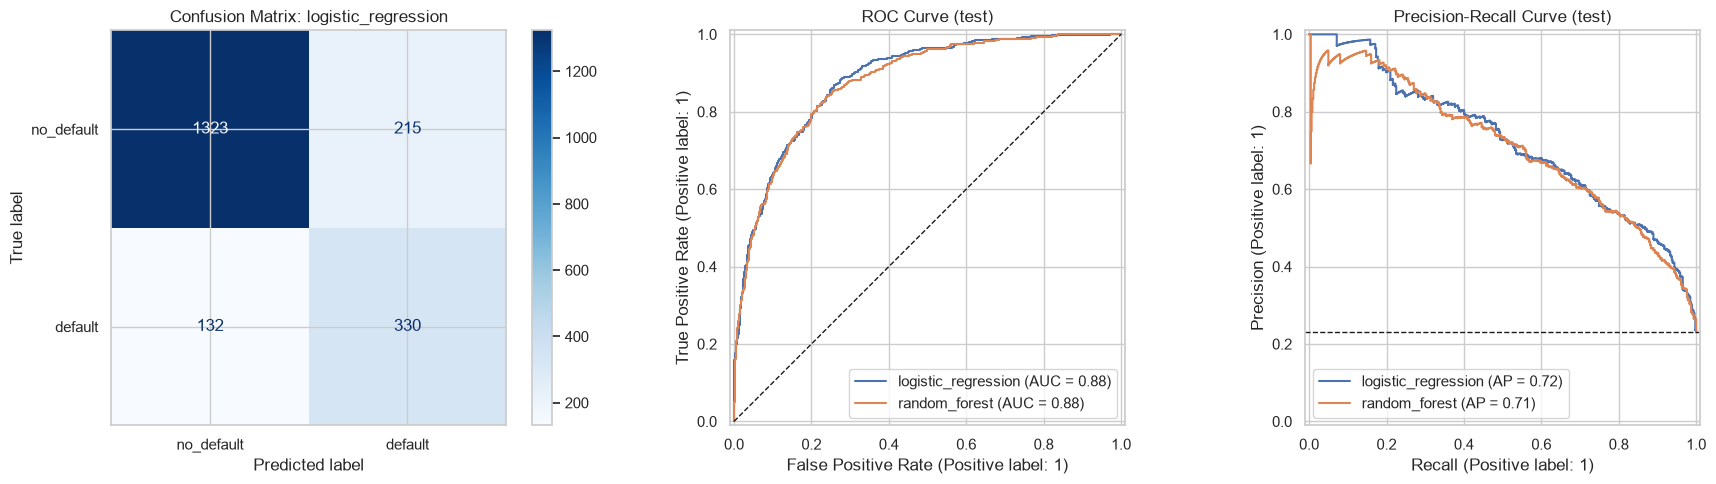

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=[LABELS[0], LABELS[1]], cmap="Blues", ax=axes[0])
axes[0].set_title(f"Confusion Matrix: {best_name}")

for name, gs in searches.items():
    RocCurveDisplay.from_estimator(gs.best_estimator_, X_test, y_test, name=name, ax=axes[1])
    PrecisionRecallDisplay.from_estimator(gs.best_estimator_, X_test, y_test, name=name, ax=axes[2])
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("ROC Curve (test)")
axes[2].axhline(y_test.mean(), color="k", ls="--", lw=1, label="baseline")
axes[2].set_title("Precision-Recall Curve (test)")
plt.tight_layout()
plt.show()

> **🔄 Alur data: Analisis Lift per Desil**
>
> - **Input:** `test_proba`, `y_test`.
> - **Proses:**
>   1. Nasabah test diurutkan berdasarkan P(default), lalu dibagi 10 desil @200 orang (desil 1 = risiko terendah).
>   2. Per desil dihitung: rata-rata probabilitas, default rate aktual, dan lift (= default rate desil / default rate total 23,1%).
> - **Output:** `lift`. Desil 10: default rate aktual **82,5%** (lift 3,6×). Desil 1: **0,5%**. Artinya model mengurutkan risiko dengan baik.
> - **Berikutnya:** Melihat fitur apa yang mendorong prediksi.

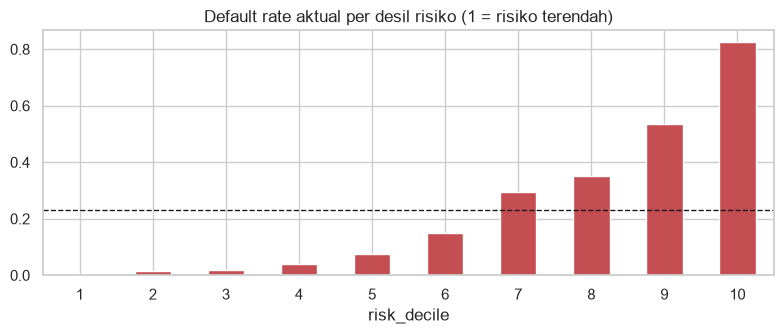

,n,avg_proba,default_rate,lift
risk_decile,,,,
1,200,0.004,0.005,0.022
2,200,0.017,0.015,0.065
3,200,0.032,0.020,0.087
4,200,0.052,0.040,0.173
5,200,0.081,0.075,0.325
6,200,0.130,0.150,0.649
7,200,0.210,0.295,1.277
8,200,0.341,0.350,1.515
9,200,0.552,0.535,2.316


In [33]:
# Analisis bisnis: default rate aktual per desil skor risiko
deciles = pd.DataFrame({"proba": test_proba, "actual": y_test.values})
deciles["risk_decile"] = pd.qcut(deciles["proba"].rank(method="first"), 10, labels=range(1, 11))
lift = deciles.groupby("risk_decile", observed=True).agg(
    n=("actual", "size"), avg_proba=("proba", "mean"), default_rate=("actual", "mean")
)
lift["lift"] = lift["default_rate"] / y_test.mean()

ax = lift["default_rate"].plot.bar(figsize=(8, 3.5), color="#C44E52")
ax.axhline(y_test.mean(), color="k", ls="--", lw=1)
ax.set_title("Default rate aktual per desil risiko (1 = risiko terendah)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
lift.round(3)

Desil risiko tertinggi seharusnya punya default rate jauh di atas rata-rata. Dari sini bank bisa membuat kebijakan berjenjang, misalnya auto-approve di desil rendah, review manual di desil tengah, dan tolak atau beri bunga lebih tinggi di desil teratas.

## 14. Evaluasi Statistik di Test Set

Angka metrik di Bagian 13 adalah **estimasi titik** dari 2.000 nasabah. Dengan sampel lain hasilnya akan sedikit berbeda. Bagian ini mengukur **ketidakpastian** dan **kualitas** prediksi dari lima sisi:

| # | Aspek | Metode |
|---|---|---|
| 14.1 | Ketidakpastian metrik | **Bootstrap** 1.000× (stratified) → 95% CI; AUC juga dengan **CI DeLong** |
| 14.2 | Model terpilih vs pesaing di test set | **Uji DeLong** (selisih AUC) & **uji McNemar** (selisih kesalahan) |
| 14.3 | Daya pisah skor | **KS statistic** & distribusi skor per kelas |
| 14.4 | Kalibrasi (apakah PD = peluang sebenarnya?) | Reliability diagram, **Brier skill score**, **Hosmer-Lemeshow**, calibration slope/intercept |
| 14.5 | Keputusan bisnis | Trade-off **approval rate vs bad rate**, threshold berbasis **biaya** |

**Metrik khas credit scoring:**
- **Gini** = 2 × AUC − 1. Untuk application scorecard: >0,4 cukup, >0,5 baik, >0,6 sangat baik.
- **KS** = jarak maksimum antara distribusi kumulatif skor nasabah default vs lancar. >0,3 baik, >0,4 sangat baik.
- **Brier score** = rata-rata (PD − aktual)². Makin kecil makin baik.

### 14.1 Bootstrap Confidence Interval

> **🔄 Alur data: Bootstrap Confidence Interval**
>
> - **Input:** `y_test`, `test_proba` (2.000 nasabah), `THRESHOLD`.
> - **Proses:**
>   1. `bootstrap_ci` melakukan resampling **1.000×** dengan pengembalian, stratified per kelas (jumlah default & lancar tetap sama tiap sampel).
>   2. Di setiap sampel bootstrap dihitung 8 metrik: ROC-AUC, Gini, KS, PR-AUC, Brier, F1, recall, precision.
>   3. 95% CI = persentil 2,5% dan 97,5% dari 1.000 nilai. *Standard error* = std dari 1.000 nilai.
>   4. AUC juga dihitung CI analitiknya dengan metode **DeLong** sebagai pembanding.
> - **Output:** `final_ci` (9 baris) + grafik. AUC 0,884 [0,868–0,900], Gini 0,768 [0,736–0,801], KS 0,610 [0,581–0,651], recall 0,714 [0,671–0,758]. CI DeLong AUC (0,868–0,900) ≈ CI bootstrap.
> - **Berikutnya:** Bandingkan model terpilih dengan pesaingnya secara statistik di test set.

,estimate,ci_lower,ci_upper,std_error,lebar_ci
roc_auc,0.8839,0.8682,0.9003,0.0085,0.0321
gini,0.7678,0.7364,0.8005,0.0170,0.0641
ks,0.6098,0.5808,0.6514,0.0186,0.0706
pr_auc,0.7220,0.6861,0.7579,0.0179,0.0719
brier,0.1094,0.1015,0.1171,0.0039,0.0157
f1,0.6554,0.6257,0.6864,0.0160,0.0607
recall,0.7143,0.6710,0.7576,0.0212,0.0866
precision,0.6055,0.5746,0.6387,0.0171,0.0641
roc_auc (CI DeLong),0.8839,0.8675,0.9003,0.0084,0.0329


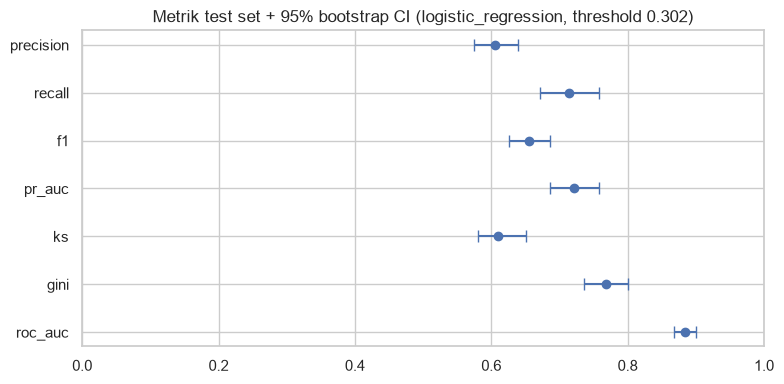

In [34]:
final_ci = bootstrap_ci(y_test, test_proba, THRESHOLD, n_boot=1000, seed=RANDOM_STATE)
auc_point, auc_lo, auc_hi = delong_auc_ci(y_test, test_proba)
final_ci.loc["roc_auc (CI DeLong)"] = [auc_point, auc_lo, auc_hi, (auc_hi - auc_lo) / (2 * 1.96)]
final_ci["lebar_ci"] = final_ci["ci_upper"] - final_ci["ci_lower"]
display(final_ci.round(4))

plot_ci = final_ci.drop(index=["roc_auc (CI DeLong)", "brier"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(plot_ci["estimate"], plot_ci.index,
            xerr=[plot_ci["estimate"] - plot_ci["ci_lower"], plot_ci["ci_upper"] - plot_ci["estimate"]],
            fmt="o", capsize=4, color="#4C72B0")
ax.set_xlim(0, 1)
ax.set_title(f"Metrik test set + 95% bootstrap CI ({best_name}, threshold {THRESHOLD:.3f})")
plt.tight_layout()
plt.show()

### 14.2 Uji Perbandingan Model di Test Set

- **Uji DeLong**: H0 = AUC kedua model sama. Uji ini memperhitungkan bahwa kedua model menilai **nasabah yang sama** (berpasangan).
- **Uji McNemar**: H0 = tingkat kesalahan klasifikasi kedua model sama. Yang dihitung hanya nasabah yang diklasifikasi **berbeda** oleh kedua model. Agar adil, model pesaing juga memakai threshold optimalnya sendiri (dari OOF train, dengan cara yang sama seperti Bagian 12).

> **🔄 Alur data: Uji DeLong & McNemar**
>
> - **Input:** `test_proba` (model terpilih), model pesaing, `X_train`/`y_train` (untuk threshold pesaing), `X_test`, `y_test`.
> - **Proses:**
>   1. Model pesaing memprediksi test set (`other_proba`).
>   2. Threshold optimal pesaing dicari dari OOF train (`cross_val_predict` + max F1), dengan cara yang sama seperti Bagian 12.
>   3. **DeLong**: menghitung selisih AUC berpasangan, z-statistic, p-value, dan 95% CI selisih.
>   4. **McNemar**: menghitung nasabah yang diklasifikasi benar oleh satu model tapi salah oleh yang lain, lalu χ² dengan koreksi kontinuitas.
> - **Output:** `model_tests`, `OTHER_THRESHOLD` = 0,330. DeLong: Δ AUC +0,0058, p = **0,062** (CI selisih mencakup 0). McNemar: 64 vs 60 kasus, p = **0,79**. Keduanya **tidak signifikan** di test set.
> - **Berikutnya:** Lihat daya pisah skor lewat KS.

In [35]:
other_name = [n for n in searches if n != best_name][0]
other_model = searches[other_name].best_estimator_
other_proba = other_model.predict_proba(X_test)[:, 1]

other_oof = cross_val_predict(other_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
p_o, r_o, t_o = precision_recall_curve(y_train, other_oof)
f1_o = 2 * p_o[:-1] * r_o[:-1] / np.clip(p_o[:-1] + r_o[:-1], 1e-12, None)
OTHER_THRESHOLD = float(t_o[np.argmax(f1_o)])
other_pred = (other_proba >= OTHER_THRESHOLD).astype(int)

dl = delong_test(y_test, test_proba, other_proba)
mc = mcnemar_test(y_test, y_pred, other_pred)

model_tests = pd.DataFrame([
    {"uji": "DeLong (selisih AUC)", "nilai": f"AUC {best_name} {dl['auc_a']:.4f} vs {other_name} {dl['auc_b']:.4f} | "
                                         f"selisih {dl['diff']:+.4f} (95% CI {dl['ci_lower']:+.4f}…{dl['ci_upper']:+.4f})",
     "statistik": dl["z"], "p_value": dl["p_value"]},
    {"uji": "McNemar (selisih kesalahan)", "nilai": f"{best_name} benar & {other_name} salah: {mc['a_right_b_wrong']} | "
                                               f"sebaliknya: {mc['a_wrong_b_right']} (threshold {THRESHOLD:.3f} vs {OTHER_THRESHOLD:.3f})",
     "statistik": mc["chi2"], "p_value": mc["p_value"]},
]).set_index("uji")
model_tests["keputusan (α=5%)"] = np.where(model_tests["p_value"] < 0.05, "berbeda signifikan", "tidak berbeda signifikan")
pd.set_option("display.max_colwidth", 140)
display(model_tests.round(4))

,nilai,statistik,p_value,keputusan (α=5%)
uji,,,,
DeLong (selisih AUC),AUC logistic_regression 0.8839 vs random_forest 0.8781 | selisih +0.0058 (95% CI -0.0003…+0.0118),1.8661,0.0620,tidak berbeda signifikan
McNemar (selisih kesalahan),logistic_regression benar & random_forest salah: 64 | sebaliknya: 60 (threshold 0.302 vs 0.330),0.0726,0.7876,tidak berbeda signifikan


### 14.3 KS Statistic & Distribusi Skor

Grafik kiri menunjukkan distribusi kumulatif skor (PD) nasabah default vs lancar. **KS** adalah jarak vertikal terbesar antara kedua kurva: makin jauh terpisah, makin baik model membedakan keduanya. Grafik kanan menunjukkan sebaran PD per kelas dan posisi threshold.

> **🔄 Alur data: KS Statistic & Distribusi Skor**
>
> - **Input:** `test_proba`, `y_test`, `THRESHOLD`.
> - **Proses:**
>   1. Untuk setiap nilai PD dihitung proporsi kumulatif nasabah lancar dan default dengan PD ≤ nilai itu (empirical CDF).
>   2. KS = selisih vertikal terbesar antara dua CDF, beserta posisi PD tempat KS terjadi.
>   3. Histogram PD per kelas memperlihatkan seberapa banyak kedua kelas tumpang tindih di sekitar threshold.
> - **Output:** `KS_TEST` = **0,610**, Gini = 0,768, grafik CDF & histogram skor.
> - **Berikutnya:** Diskriminasi sudah dinilai, selanjutnya kalibrasi.

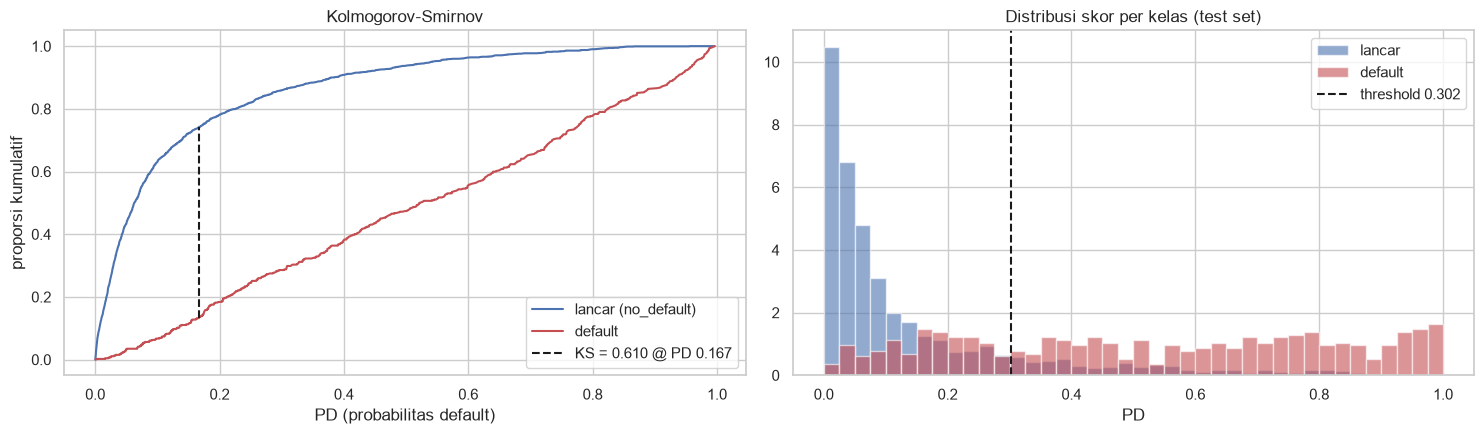

KS = 0.6098 | Gini = 0.7678


In [36]:
grid = np.sort(np.unique(test_proba))
cdf_bad = np.searchsorted(np.sort(test_proba[y_test.values == 1]), grid, side="right") / (y_test == 1).sum()
cdf_good = np.searchsorted(np.sort(test_proba[y_test.values == 0]), grid, side="right") / (y_test == 0).sum()
ks_idx = np.argmax(cdf_good - cdf_bad)
KS_TEST = float(cdf_good[ks_idx] - cdf_bad[ks_idx])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(grid, cdf_good, label="lancar (no_default)", color="#4C72B0")
axes[0].plot(grid, cdf_bad, label="default", color="#C44E52")
axes[0].vlines(grid[ks_idx], cdf_bad[ks_idx], cdf_good[ks_idx], color="k", ls="--", label=f"KS = {KS_TEST:.3f} @ PD {grid[ks_idx]:.3f}")
axes[0].set_xlabel("PD (probabilitas default)")
axes[0].set_ylabel("proporsi kumulatif")
axes[0].set_title("Kolmogorov-Smirnov")
axes[0].legend()

bins = np.linspace(0, 1, 41)
axes[1].hist(test_proba[y_test.values == 0], bins=bins, alpha=0.6, density=True, label="lancar", color="#4C72B0")
axes[1].hist(test_proba[y_test.values == 1], bins=bins, alpha=0.6, density=True, label="default", color="#C44E52")
axes[1].axvline(THRESHOLD, color="k", ls="--", label=f"threshold {THRESHOLD:.3f}")
axes[1].set_xlabel("PD")
axes[1].set_title("Distribusi skor per kelas (test set)")
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"KS = {KS_TEST:.4f} | Gini = {gini(y_test, test_proba):.4f}")

### 14.4 Kalibrasi

Diskriminasi (AUC/Gini/KS) hanya menilai **urutan** risiko. Bank juga butuh PD yang **akurat secara absolut**, misalnya untuk pricing, perhitungan CKPN/IFRS 9 (expected loss = PD × LGD × EAD), dan modal. Ada empat ukuran kalibrasi:

| Ukuran | Ideal | Arti |
|---|---|---|
| **Reliability diagram** | titik di garis diagonal | PD rata-rata per grup = default rate aktual |
| **Brier Skill Score** = 1 − Brier / Brier_referensi | > 0 | lebih baik daripada menebak default rate rata-rata untuk semua nasabah |
| **Hosmer-Lemeshow** (10 grup, χ² df=8) | p > 0,05 | H0 “model terkalibrasi” tidak ditolak |
| **Calibration slope / intercept** | slope = 1, intercept = 0 | slope < 1: PD terlalu ekstrem; intercept ≠ 0: PD rata-rata bias |

> **🔄 Alur data: Kalibrasi**
>
> - **Input:** `test_proba`, `y_test`.
> - **Proses:**
>   1. Test set dibagi 10 desil PD. Per desil dihitung PD rata-rata, default rate aktual (+ CI Wilson), default diharapkan (Σ PD), dan default aktual.
>   2. **Hosmer-Lemeshow**: χ² = Σ (aktual − diharapkan)² / (diharapkan × (1 − diharapkan/n)), df = 8.
>   3. **Calibration slope/intercept**: regresi logistik y ~ logit(PD).
>   4. **Brier Skill Score** = 1 − Brier model / Brier tebakan rata-rata.
> - **Output:** `hl`, `cal`, `BSS`, `calibration`, `hl_table`. PD rata-rata 0,226 vs DR 0,231. Hosmer-Lemeshow χ² = 11,7, **p = 0,16** (terkalibrasi). Slope **0,97**, BSS **0,38**.
> - **Berikutnya:** Terjemahkan prediksi ke keputusan bisnis (threshold & approval).

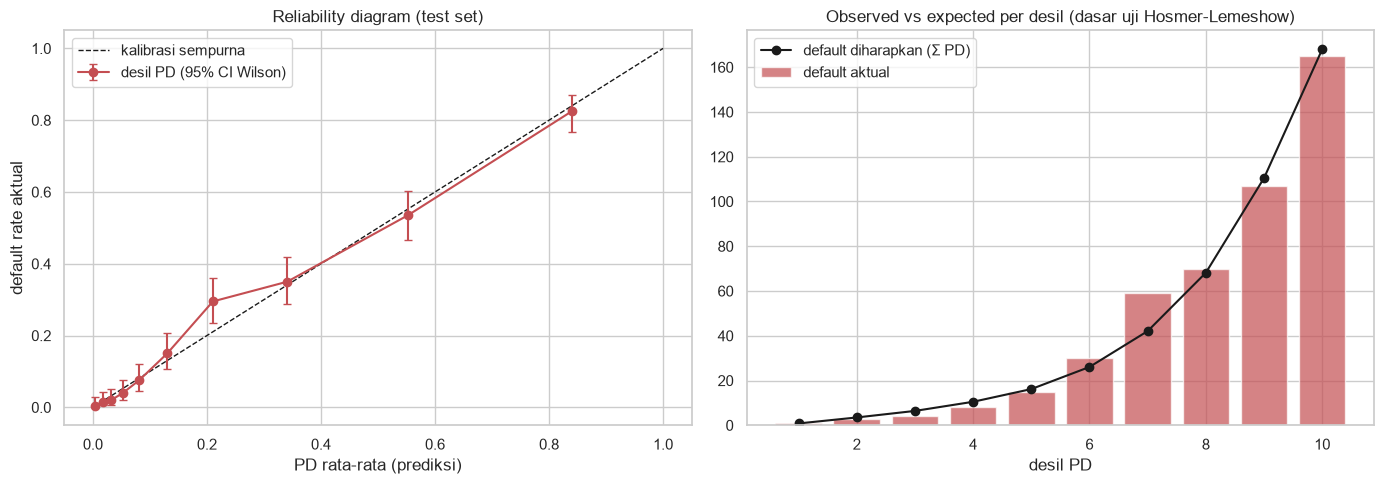

,nilai
Brier score,0.1094
Brier referensi (tebak rata-rata),0.1776
Brier Skill Score,0.3840
PD rata-rata prediksi,0.2261
Default rate aktual,0.2310
Hosmer-Lemeshow χ²,11.7309
Hosmer-Lemeshow p-value,0.1636
Calibration slope,0.9742
Calibration intercept,0.0244
Calibration-in-the-large,0.0279


,n,mean_pd,observed_rate,ci_lower,ci_upper,expected,observed
group,,,,,,,
0,200,0.0041,0.005,0.0009,0.0278,0.8147,1
1,200,0.0175,0.015,0.0051,0.0432,3.4906,3
2,200,0.0321,0.020,0.0078,0.0503,6.4125,4
3,200,0.0525,0.040,0.0204,0.0769,10.4949,8
4,200,0.0809,0.075,0.0460,0.1200,16.1773,15
5,200,0.1303,0.150,0.1071,0.2061,26.0511,30
6,200,0.2104,0.295,0.2361,0.3616,42.0801,59
7,200,0.3408,0.350,0.2873,0.4184,68.1596,70
8,200,0.5524,0.535,0.4659,0.6028,110.4769,107


In [37]:
hl = hosmer_lemeshow(y_test, test_proba)
cal = calibration_slope_intercept(y_test, test_proba)
brier = brier_score_loss(y_test, test_proba)
brier_ref = y_test.mean() * (1 - y_test.mean())
BSS = 1 - brier / brier_ref

hl_table = hl["table"].copy()
hl_table[["ci_lower", "ci_upper"]] = [wilson_ci(o, n) for o, n in zip(hl_table["observed"], hl_table["n"])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="kalibrasi sempurna")
axes[0].errorbar(hl_table["mean_pd"], hl_table["observed_rate"],
                 yerr=[hl_table["observed_rate"] - hl_table["ci_lower"], hl_table["ci_upper"] - hl_table["observed_rate"]],
                 fmt="o-", capsize=3, color="#C44E52", label="desil PD (95% CI Wilson)")
axes[0].set_xlabel("PD rata-rata (prediksi)")
axes[0].set_ylabel("default rate aktual")
axes[0].set_title("Reliability diagram (test set)")
axes[0].legend()
axes[1].bar(range(1, 11), hl_table["observed"], alpha=0.7, label="default aktual", color="#C44E52")
axes[1].plot(range(1, 11), hl_table["expected"], "ko-", label="default diharapkan (Σ PD)")
axes[1].set_xlabel("desil PD")
axes[1].set_title("Observed vs expected per desil (dasar uji Hosmer-Lemeshow)")
axes[1].legend()
plt.tight_layout()
plt.show()

calibration = pd.Series({
    "Brier score": brier,
    "Brier referensi (tebak rata-rata)": brier_ref,
    "Brier Skill Score": BSS,
    "PD rata-rata prediksi": test_proba.mean(),
    "Default rate aktual": y_test.mean(),
    "Hosmer-Lemeshow χ²": hl["statistic"],
    "Hosmer-Lemeshow p-value": hl["p_value"],
    "Calibration slope": cal["slope"],
    "Calibration intercept": cal["intercept"],
    "Calibration-in-the-large": cal["calibration_in_the_large"],
})
display(calibration.to_frame("nilai").round(4))
display(hl_table[["n", "mean_pd", "observed_rate", "ci_lower", "ci_upper", "expected", "observed"]].round(4))

### 14.5 Threshold & Trade-off Bisnis

Threshold menentukan siapa yang **disetujui** (PD < threshold) dan siapa yang **ditolak/di-review**. Dua cara pandang:
1. **Approval rate vs bad rate**: makin longgar threshold, makin banyak nasabah disetujui, tetapi bad rate di portofolio yang disetujui ikut naik.
2. **Threshold berbasis biaya**: dengan **asumsi** kerugian 1 kredit macet yang lolos (FN) = **5×** kerugian menolak 1 nasabah baik (FP, kehilangan margin bunga), dipilih threshold dengan total biaya terkecil. Threshold ini dicari dari **OOF train** (bukan test) agar tidak bocor, lalu dilaporkan di test.

> Rasio biaya 5:1 hanyalah ilustrasi. Di praktik angka ini dihitung dari LGD, EAD, dan margin produk.

> **🔄 Alur data: Trade-off Approval & Threshold Berbasis Biaya**
>
> - **Input:** `oof_proba` & `y_train` (untuk memilih threshold), `test_proba` & `y_test` (untuk melaporkan).
> - **Proses:**
>   1. `tradeoff_table` menghitung, untuk setiap threshold 0,05–0,95: approval rate, bad rate di nasabah yang disetujui, recall default, FN, FP, dan biaya per nasabah = (5 × FN + 1 × FP) / n.
>   2. Threshold dengan biaya minimum dicari di **OOF train** (`COST_THRESHOLD`), lalu diterapkan ke test.
>   3. Kurva approval rate vs bad rate dan kurva biaya ditampilkan, beserta tabel beberapa titik operasi.
> - **Output:** `COST_THRESHOLD` = **0,15**, `operating_points`. Threshold F1 0,302: approve 72,8%, bad rate 9,1%. Threshold biaya 0,15: approve 58,1%, bad rate 4,5%, biaya per nasabah turun 0,438 → 0,344.
> - **Berikutnya:** Lihat fitur mana yang mendorong prediksi (Bagian 15).

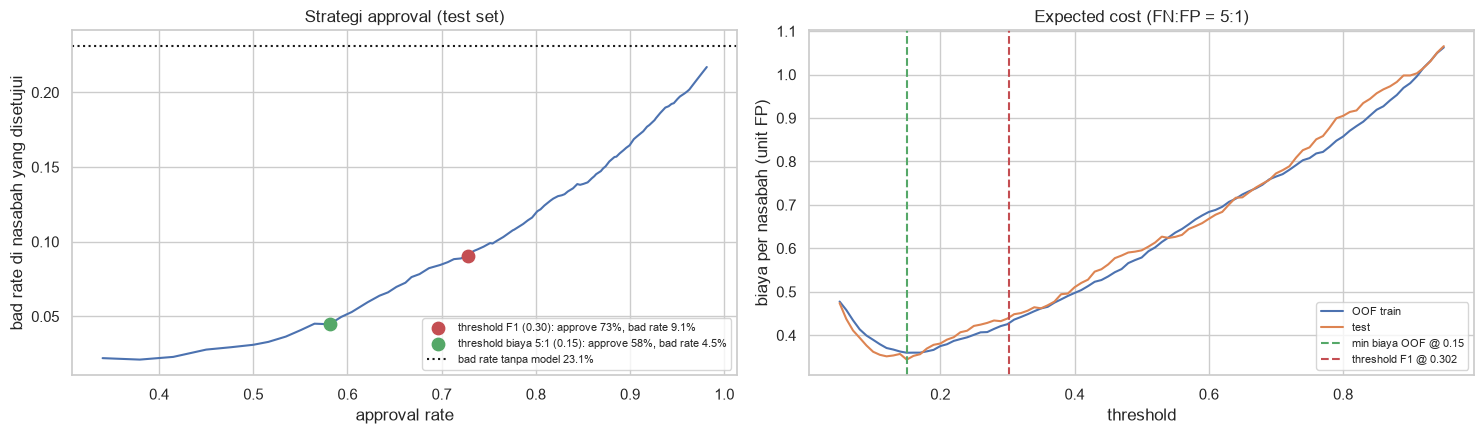

,threshold,approval_rate,bad_rate_approved,recall_default,FN,FP,biaya_per_nasabah
0,0.100,0.5000,0.0310,0.9329,31,569,0.3620
1,0.150,0.5810,0.0448,0.8874,52,428,0.3440
2,0.200,0.6430,0.0661,0.8160,85,337,0.3810
3,0.302,0.7275,0.0907,0.7143,132,215,0.4375
4,0.400,0.7865,0.1119,0.6190,176,141,0.5105
5,0.500,0.8305,0.1318,0.5260,219,96,0.5955


In [38]:
COST_FN, COST_FP = 5.0, 1.0


def tradeoff_table(y_true, proba, thresholds):
    y_true, proba = np.asarray(y_true), np.asarray(proba)
    rows = []
    for t in thresholds:
        reject = proba >= t
        approved = ~reject
        fn = int(np.sum(approved & (y_true == 1)))
        fp = int(np.sum(reject & (y_true == 0)))
        rows.append({
            "threshold": t,
            "approval_rate": approved.mean(),
            "bad_rate_approved": y_true[approved].mean() if approved.any() else np.nan,
            "recall_default": np.sum(reject & (y_true == 1)) / max(1, y_true.sum()),
            "FN": fn, "FP": fp,
            "biaya_per_nasabah": (COST_FN * fn + COST_FP * fp) / len(y_true),
        })
    return pd.DataFrame(rows)


grid_t = np.round(np.arange(0.05, 0.96, 0.01), 2)
oof_trade = tradeoff_table(y_train, oof_proba, grid_t)
COST_THRESHOLD = float(oof_trade.loc[oof_trade["biaya_per_nasabah"].idxmin(), "threshold"])
test_trade = tradeoff_table(y_test, test_proba, grid_t)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(test_trade["approval_rate"], test_trade["bad_rate_approved"], color="#4C72B0")
for t, lbl, c in [(THRESHOLD, "threshold F1", "#C44E52"), (COST_THRESHOLD, "threshold biaya 5:1", "#55A868")]:
    r = tradeoff_table(y_test, test_proba, [t]).iloc[0]
    axes[0].scatter(r["approval_rate"], r["bad_rate_approved"], s=80, color=c, zorder=3,
                    label=f"{lbl} ({t:.2f}): approve {r['approval_rate']:.0%}, bad rate {r['bad_rate_approved']:.1%}")
axes[0].axhline(y_test.mean(), color="k", ls=":", label=f"bad rate tanpa model {y_test.mean():.1%}")
axes[0].set_xlabel("approval rate")
axes[0].set_ylabel("bad rate di nasabah yang disetujui")
axes[0].set_title("Strategi approval (test set)")
axes[0].legend(fontsize=8)
axes[1].plot(oof_trade["threshold"], oof_trade["biaya_per_nasabah"], label="OOF train")
axes[1].plot(test_trade["threshold"], test_trade["biaya_per_nasabah"], label="test")
axes[1].axvline(COST_THRESHOLD, color="#55A868", ls="--", label=f"min biaya OOF @ {COST_THRESHOLD:.2f}")
axes[1].axvline(THRESHOLD, color="#C44E52", ls="--", label=f"threshold F1 @ {THRESHOLD:.3f}")
axes[1].set_xlabel("threshold")
axes[1].set_ylabel("biaya per nasabah (unit FP)")
axes[1].set_title(f"Expected cost (FN:FP = {COST_FN:.0f}:{COST_FP:.0f})")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

operating_points = (tradeoff_table(y_test, test_proba, [0.1, 0.2, COST_THRESHOLD, THRESHOLD, 0.4, 0.5])
                    .drop_duplicates("threshold").sort_values("threshold").reset_index(drop=True))
display(operating_points.round(4))

### Interpretasi Evaluasi Statistik Test Set

**14.1 Ketidakpastian metrik**
- ROC-AUC **0,884** (95% CI 0,868–0,900). CI DeLong (0,868–0,900) hampir sama dengan bootstrap, jadi kedua metode konsisten.
- Gini **0,768** (0,736–0,801) dan KS **0,610** (0,581–0,651). **Batas bawah CI** pun masih di atas patokan “sangat baik” (Gini > 0,6, KS > 0,4).
- Recall 0,714 punya CI lebar (0,671–0,758, ±4 poin) karena hanya ada 462 default di test set. Angka recall sebaiknya dibaca sebagai rentang, bukan angka pasti.

**14.2 LR vs RF di test set**
- DeLong: Δ AUC +0,0058, **p = 0,062**. 95% CI selisih (−0,0003…+0,0118) mencakup 0, jadi **tidak signifikan**.
- McNemar: 64 nasabah benar hanya oleh LR vs 60 benar hanya oleh RF, **p = 0,79**. Tingkat kesalahan kedua model praktis sama.
- **Kenapa hasilnya beda dengan 10.2 (p = 0,016)?** Repeated CV memakai 25 evaluasi pada 8.000 baris, jadi *power*-nya lebih besar. Satu test set berisi 2.000 baris kurang kuat untuk mendeteksi selisih 0,005. Kedua bukti **konsisten**: LR sedikit lebih baik dengan selisih kecil.
- Alasan memilih LR tetap kuat: AUC sedikit lebih tinggi, kalibrasi lebih baik (Brier lebih rendah), **mudah dijelaskan** ke regulator, dan `model.json` hanya ~11 KB (RF puluhan MB).

**14.3 Daya pisah**
- KS 0,61 berarti di satu titik PD, 61% lebih banyak nasabah lancar daripada nasabah default yang punya PD di bawah titik itu. Histogram menunjukkan nasabah lancar menumpuk di PD < 0,1, sedangkan nasabah default tersebar dengan banyak di PD > 0,5.

**14.4 Kalibrasi**
- PD rata-rata **0,226** vs default rate aktual **0,231** (selisih 0,5 poin).
- Hosmer-Lemeshow χ² = 11,7, **p = 0,16**, jadi H0 “terkalibrasi” **tidak ditolak**. Calibration slope **0,97** (ideal 1) dan intercept 0,02 (ideal 0).
- Brier Skill Score **0,38**: 38% lebih baik daripada menebak default rate rata-rata untuk semua nasabah.
- Satu-satunya penyimpangan yang terlihat ada di desil ke-7 (PD 0,21 vs aktual 0,295, *under-predict*), tetapi masih dalam toleransi uji HL.
- Kalibrasi yang baik ini terjadi karena model terpilih memakai `class_weight=None`. Dengan `balanced`, PD akan terdorong ke atas dan perlu dikalibrasi ulang sebelum dipakai untuk pricing atau CKPN.

**14.5 Keputusan bisnis**
- Threshold F1 (0,302): approval **72,8%**, bad rate di portofolio yang disetujui **9,1%** (vs 23,1% tanpa model), recall 71,4%.
- Threshold biaya 5:1 (0,15, dipilih dari OOF train): approval **58,1%**, bad rate **4,5%**, recall 88,7%. Biaya per nasabah turun **21%** (0,438 → 0,344).
- Pilihan threshold adalah **keputusan risk appetite** (volume vs kualitas), bukan keputusan statistik. Model menyediakan kurva trade-off, dan bisnis memilih titiknya.

## 15. Interpretasi Model

> **🔄 Alur data: Interpretasi Model**
>
> - **Input:** `best_model` (langkah `model` dan nama 64 kolom dari `preprocess`).
> - **Proses:**
>   1. LR: membaca `coef_` (1 bobot per kolom). RF: membaca `feature_importances_`.
>   2. Diambil 20 bobot terbesar (nilai absolut).
> - **Output:** Grafik. Bobot positif = menaikkan risiko: `credit_score_bin_poor` +2,20, `occupation_unemployed` +1,31, `num_late_payments_12m` +0,69. Bobot negatif = menurunkan risiko: `credit_score_bin_excellent` −2,93, `employee_status_permanent` −0,60, `occupation_soe_employee` −0,59, `occupation_civil_servant` −0,55. ⚠️ Kolom pekerjaan saling tumpang tindih (lihat catatan di bawah grafik), jadi bobotnya harus dibaca bersama.
> - **Berikutnya:** Model dan semua parameternya disimpan.

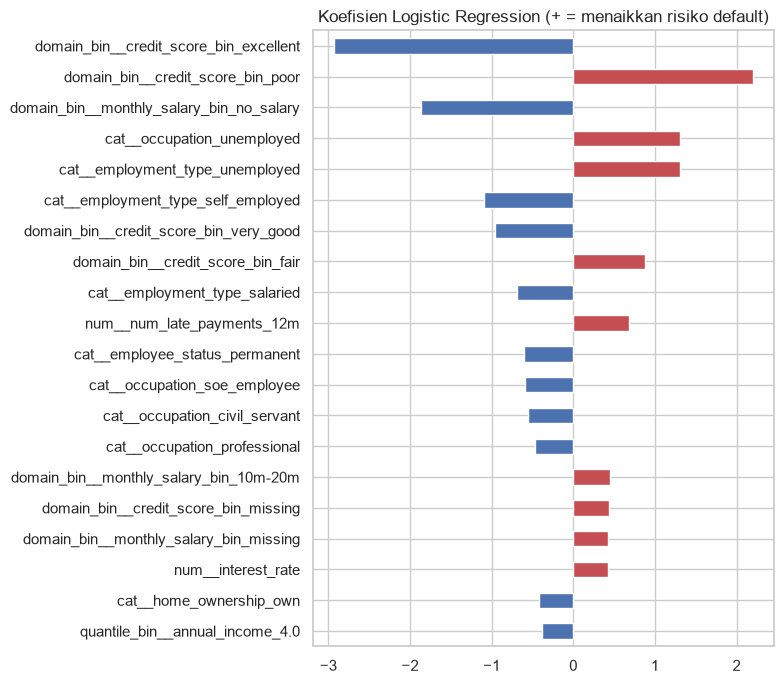

In [39]:
estimator = best_model.named_steps["model"]
feat_names = best_model.named_steps["preprocess"].get_feature_names_out()

if hasattr(estimator, "coef_"):
    importance = pd.Series(estimator.coef_[0], index=feat_names)
    title = "Koefisien Logistic Regression (+ = menaikkan risiko default)"
else:
    importance = pd.Series(estimator.feature_importances_, index=feat_names)
    title = "Feature importance Random Forest"

top = importance.reindex(importance.abs().sort_values(ascending=False).index).head(20)
fig, ax = plt.subplots(figsize=(8, 7))
top.plot.barh(ax=ax, color=np.where(top > 0, "#C44E52", "#4C72B0"))
ax.invert_yaxis()
ax.set_title(title)
plt.tight_layout()
plt.show()

**⚠️ Cara membaca bobot kolom pekerjaan (multikolinearitas)**

Informasi pekerjaan muncul di beberapa kolom yang saling terkait:
- nasabah yang tidak bekerja **selalu** punya `occupation_unemployed = 1`, `employment_type_unemployed = 1`, dan (jika gaji dilaporkan) `monthly_salary_bin_no_salary = 1` sekaligus;
- `employee_status_not_applicable` selalu sama dengan "bukan `salaried`";
- `monthly_salary` dan `annual_income` berkorelasi 0,99.

Karena kolom-kolom ini selalu muncul bersama, Logistic Regression **membagi** efeknya ke beberapa bobot, dan bobot satu kolom bisa terlihat aneh kalau dibaca sendirian. Contohnya `monthly_salary_bin_no_salary` bernilai **negatif**, padahal default rate nasabah tanpa gaji 55%. Itu karena efek “tidak bekerja” sudah diambil oleh `occupation_unemployed` (+1,31) dan `employment_type_unemployed` (+1,31). Efek bersihnya tetap **menaikkan** risiko: +1,31 + 1,31 − 1,86 = **+0,76**.

Hal ini **tidak mengganggu prediksi** (ROC-AUC tetap 0,88), tetapi untuk penjelasan ke tim risk sebaiknya bobot dibaca **per kelompok** (semua kolom pekerjaan bersama-sama), atau salah satu kolom yang redundan dihapus jika perlu model scorecard yang mudah diaudit.

### Permutation Importance (per fitur asli)

Koefisien di atas dihitung per **kolom hasil one-hot** dan terpengaruh multikolinearitas. **Permutation importance** mengukur kontribusi setiap **fitur asli** (18 kolom) dengan cara langsung: nilai satu kolom diacak di test set (semua dummy-nya ikut teracak), lalu dilihat **berapa besar ROC-AUC turun**. Proses ini diulang 10× untuk mendapatkan rata-rata ± std.

- Penurunan besar berarti model sangat bergantung pada fitur itu.
- Penurunan ≈ 0 (atau error bar menyentuh 0) berarti fitur tidak berkontribusi nyata.
- ⚠️ Fitur yang saling berkorelasi (gaji ↔ pendapatan, occupation ↔ employment_type) bisa saling “menggantikan” saat salah satunya diacak, sehingga importance masing-masing tampak lebih kecil dari kontribusi gabungannya.

> **🔄 Alur data: Permutation Importance**
>
> - **Input:** `best_model`, `X_test` (18 kolom mentah), `y_test`.
> - **Proses:**
>   1. Untuk setiap fitur asli: nilai kolom itu diacak antar nasabah, lalu pipeline lengkap (termasuk binning/one-hot) memprediksi ulang dan ROC-AUC dihitung.
>   2. Penurunan AUC dibanding AUC asli = importance. Diulang 10× per fitur untuk mean ± std.
>   3. Fitur dianggap berkontribusi nyata jika batas bawah 95% CI penurunan AUC > 0.
> - **Output:** `perm_df` + grafik. Terpenting: `credit_score` (AUC turun 0,10), `num_late_payments_12m` (0,047), `employment_type` (0,024), `interest_rate` (0,020), `monthly_salary` (0,020), `occupation` (0,015). **Tidak berkontribusi nyata**: `marital_status`, `education`, `loan_purpose`.
> - **Berikutnya:** Uji ketahanan model terhadap waktu (backtesting).

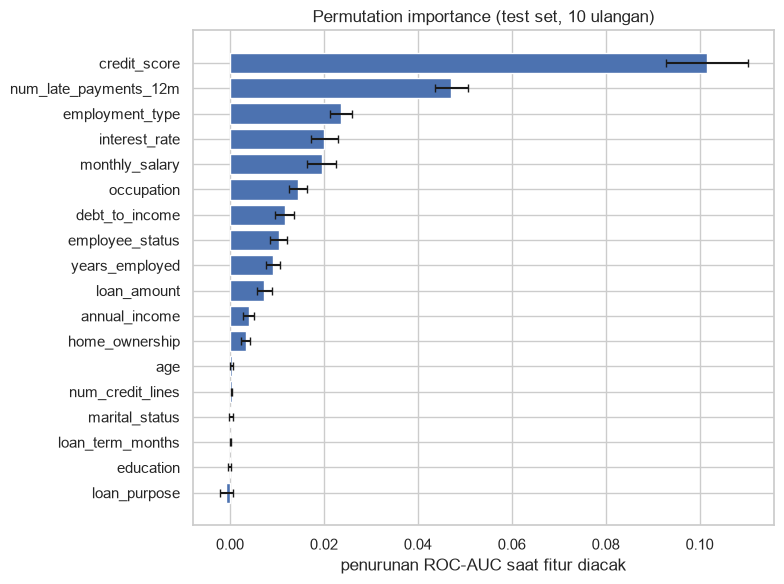

,penurunan_auc_mean,std,ci95_lower,berkontribusi_nyata
credit_score,0.1015,0.0087,0.0961,ya
num_late_payments_12m,0.0472,0.0034,0.0450,ya
employment_type,0.0237,0.0024,0.0222,ya
interest_rate,0.0200,0.0029,0.0183,ya
monthly_salary,0.0195,0.0031,0.0176,ya
occupation,0.0145,0.0020,0.0132,ya
debt_to_income,0.0116,0.0019,0.0104,ya
employee_status,0.0104,0.0019,0.0092,ya
years_employed,0.0092,0.0015,0.0083,ya
loan_amount,0.0073,0.0017,0.0063,ya


In [40]:
perm = permutation_importance(best_model, X_test, y_test, scoring="roc_auc", n_repeats=10,
                              random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.DataFrame({"penurunan_auc_mean": perm.importances_mean, "std": perm.importances_std}, index=FEATURES)
perm_df["ci95_lower"] = perm_df["penurunan_auc_mean"] - 1.96 * perm_df["std"] / np.sqrt(10)
perm_df["berkontribusi_nyata"] = np.where(perm_df["ci95_lower"] > 0, "ya", "tidak")
perm_df = perm_df.sort_values("penurunan_auc_mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(perm_df.index, perm_df["penurunan_auc_mean"], xerr=perm_df["std"], color="#4C72B0", capsize=3)
ax.invert_yaxis()
ax.set_xlabel("penurunan ROC-AUC saat fitur diacak")
ax.set_title("Permutation importance (test set, 10 ulangan)")
plt.tight_layout()
plt.show()
display(perm_df.round(4))

## 16. Backtesting (Out-of-Time & Walk-Forward)

Semua evaluasi sebelumnya bersifat **in-time**: train dan test diambil acak dari periode yang sama. Padahal di produksi, model dilatih dengan data **masa lalu** lalu dipakai untuk nasabah **masa depan**, dan populasi pemohon bisa berubah (kondisi ekonomi, strategi marketing, produk baru).

**Backtesting** mensimulasikan kondisi itu memakai kolom `application_date` (Jan 2023 – Des 2025). Kolom ini **tidak** dipakai sebagai fitur model.

| # | Analisis | Pertanyaan |
|---|---|---|
| 16.1 | Timeline portofolio | Apakah populasi & default rate berubah dari waktu ke waktu? |
| 16.2 | **Out-of-time (OOT) validation** | Model dilatih s.d. Jun 2025 dan diuji di Jul–Des 2025. Apakah performanya bertahan? |
| 16.3 | **Walk-forward backtest** (expanding window) | Jika model dilatih ulang setiap kuartal, bagaimana performa di kuartal berikutnya? |
| 16.4 | **Backtest kalibrasi per grade** (uji binomial, traffic light Basel) | Apakah PD tiap grade risiko sesuai default aktual? |
| 16.5 | **Stabilitas populasi** (PSI skor & CSI fitur) | Seberapa jauh distribusi skor & fitur bergeser? |

> Penting: model di Bagian 8–15 dilatih dari split **acak** (train-nya juga berisi data 2025). Karena itu backtest **melatih ulang** model dengan konfigurasi yang sama (`clone(best_model)`), hanya dengan data sebelum periode uji. Threshold juga dihitung ulang dari data pengembangan saja.

### 16.1 Timeline Portofolio

> **🔄 Alur data: Timeline Portofolio**
>
> - **Input:** `df` (termasuk `application_date`).
> - **Proses:**
>   1. `df_bt` = salinan `df` + kolom `month` & `quarter` dari tanggal pengajuan (`df` asli tidak berubah).
>   2. Per kuartal dihitung: jumlah aplikasi, default rate (+ CI Wilson), rata-rata credit score, % pekerja gig/retail/unemployed, dan median gaji.
>   3. **Spearman** antara urutan kuartal dan default rate menguji ada tidaknya tren. **Chi-square** menguji apakah default rate semua kuartal sama.
> - **Output:** `df_bt`, `timeline` (12 kuartal) + grafik. Default rate naik **15,9% → 27,0%** (Spearman ρ = +0,92, p < 0,001; χ² homogenitas p < 0,001). Credit score rata-rata turun 710 → 679, porsi gig/retail/unemployed naik 21% → 30%.
> - **Berikutnya:** Data dibagi berdasarkan waktu untuk validasi out-of-time.

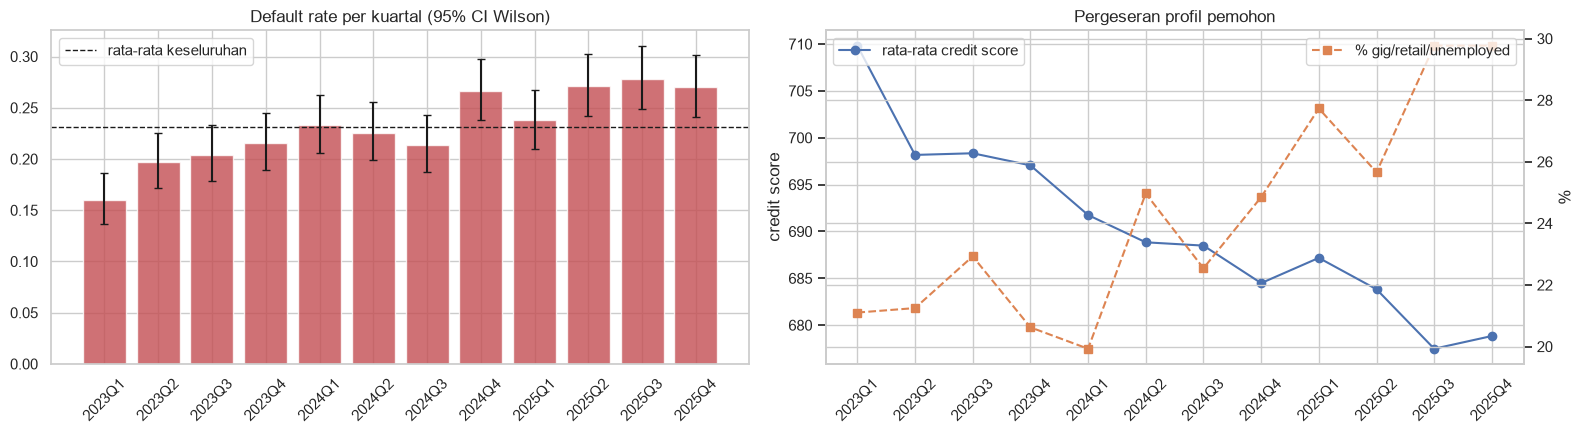

,n,defaults,default_rate,avg_credit_score,pct_gig_unemployed,median_salary,dr_ci_lower,dr_ci_upper
quarter,,,,,,,,
2023Q1,834,133,0.159,709.831,0.211,8.470,0.136,0.186
2023Q2,833,164,0.197,698.165,0.212,8.390,0.171,0.225
2023Q3,833,170,0.204,698.343,0.229,8.010,0.178,0.233
2023Q4,834,180,0.216,697.053,0.206,8.560,0.189,0.245
2024Q1,833,194,0.233,691.752,0.199,8.710,0.205,0.263
2024Q2,833,188,0.226,688.839,0.250,8.395,0.199,0.255
2024Q3,834,178,0.213,688.488,0.225,7.900,0.187,0.243
2024Q4,833,222,0.267,684.483,0.248,7.930,0.238,0.298
2025Q1,833,198,0.238,687.177,0.277,7.635,0.210,0.268


Tren default rate (Spearman ρ) = +0.923, p = <0,001
Homogenitas default rate antar kuartal (χ²) = 66.9, p = <0,001


In [41]:
dates = pd.to_datetime(df[DATE_COL])
df_bt = df.assign(month=dates.dt.to_period("M"), quarter=dates.dt.to_period("Q"))

timeline = df_bt.groupby("quarter").agg(
    n=(TARGET, "size"),
    defaults=(TARGET, "sum"),
    default_rate=(TARGET, "mean"),
    avg_credit_score=("credit_score", "mean"),
    pct_gig_unemployed=("occupation", lambda s: s.isin(["driver_ojol", "retail_service", "unemployed"]).mean()),
    median_salary=("monthly_salary", "median"),
)
timeline[["dr_ci_lower", "dr_ci_upper"]] = [wilson_ci(d, n) for d, n in zip(timeline["defaults"], timeline["n"])]

# uji tren: apakah default rate naik seiring waktu? (Spearman antara urutan kuartal dan default rate)
trend_rho, trend_p = stats.spearmanr(np.arange(len(timeline)), timeline["default_rate"])
# uji homogenitas: apakah default rate antar kuartal sama? (chi-square)
chi2_q, p_q, _, _ = stats.chi2_contingency(pd.crosstab(df_bt["quarter"], df_bt[TARGET]))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
x = timeline.index.astype(str)
axes[0].bar(x, timeline["default_rate"], color="#C44E52", alpha=0.8,
            yerr=[timeline["default_rate"] - timeline["dr_ci_lower"], timeline["dr_ci_upper"] - timeline["default_rate"]], capsize=3)
axes[0].axhline(df[TARGET].mean(), color="k", ls="--", lw=1, label="rata-rata keseluruhan")
axes[0].set_title("Default rate per kuartal (95% CI Wilson)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()
ax2 = axes[1]
ax2.plot(x, timeline["avg_credit_score"], "o-", color="#4C72B0", label="rata-rata credit score")
ax2.set_ylabel("credit score")
ax3 = ax2.twinx()
ax3.plot(x, timeline["pct_gig_unemployed"] * 100, "s--", color="#DD8452", label="% gig/retail/unemployed")
ax3.set_ylabel("%")
ax2.set_title("Pergeseran profil pemohon")
ax2.tick_params(axis="x", rotation=45)
ax2.legend(loc="upper left")
ax3.legend(loc="upper right")
plt.tight_layout()
plt.show()

display(timeline.round(3))
print(f"Tren default rate (Spearman ρ) = {trend_rho:+.3f}, p = {fmt_p(trend_p)}")
print(f"Homogenitas default rate antar kuartal (χ²) = {chi2_q:.1f}, p = {fmt_p(p_q)}")

### 16.2 Out-of-Time (OOT) Validation

```
2023Q1 ─────────────── 2025Q2 │ 2025Q3 ── 2025Q4
   development (dev)          │   out-of-time (OOT)
   → fit model + threshold    │   → hanya diprediksi & dinilai
```

Pembandingnya adalah **estimasi in-time**, yaitu prediksi out-of-fold 5-fold CV di data dev. Jika performa OOT jauh di bawah in-time, model tidak *robust* terhadap perubahan waktu.

> **🔄 Alur data: Out-of-Time Validation**
>
> - **Input:** `df_bt`, konfigurasi `best_model`.
> - **Proses:**
>   1. Split **berdasarkan waktu**: dev = 2023Q1–2025Q2, OOT = 2025Q3–2025Q4.
>   2. Di dev: OOF 5-fold → estimasi in-time + `BT_THRESHOLD` (max F1). Data OOT tidak dipakai sama sekali.
>   3. `bt_model` = clone(best_model) dilatih di seluruh dev, lalu memprediksi OOT.
>   4. Metrik in-time vs OOT dibandingkan dengan bootstrap CI (500×). Selisih AUC diuji dengan z-test dua sampel independen. Kalibrasi OOT diuji dengan uji binomial.
> - **Output:** `X_dev` (8.334 baris), `X_oot` (1.666), `bt_model`, `BT_THRESHOLD` = 0,340, `oot_proba`, `oot_compare`. AUC in-time 0,884 → OOT **0,871** (Δ −0,013, p = 0,23, tidak signifikan). Kalibrasi OOT: 457 default aktual vs 449 diharapkan, p = 0,66 → 🟢.
> - **Berikutnya:** Ulangi untuk setiap kuartal (walk-forward).

In [42]:
OOT_START = pd.Period("2025Q3", freq="Q")
dev_mask = (df_bt["quarter"] < OOT_START).to_numpy()
X_dev, y_dev = df_bt.loc[dev_mask, FEATURES], df_bt.loc[dev_mask, TARGET]
X_oot, y_oot = df_bt.loc[~dev_mask, FEATURES], df_bt.loc[~dev_mask, TARGET]

dev_oof = cross_val_predict(clone(best_model), X_dev, y_dev, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
p_d, r_d, t_d = precision_recall_curve(y_dev, dev_oof)
f1_d = 2 * p_d[:-1] * r_d[:-1] / np.clip(p_d[:-1] + r_d[:-1], 1e-12, None)
BT_THRESHOLD = float(t_d[np.argmax(f1_d)])

bt_model = clone(best_model).fit(X_dev, y_dev)
dev_score = bt_model.predict_proba(X_dev)[:, 1]
oot_proba = bt_model.predict_proba(X_oot)[:, 1]

intime_ci = bootstrap_ci(y_dev, dev_oof, BT_THRESHOLD, n_boot=500, seed=RANDOM_STATE)
oot_ci = bootstrap_ci(y_oot, oot_proba, BT_THRESHOLD, n_boot=500, seed=RANDOM_STATE)
oot_compare = pd.DataFrame({
    "in-time (OOF dev)": intime_ci["estimate"],
    "in-time CI": intime_ci.apply(lambda r: f"{r.ci_lower:.3f}–{r.ci_upper:.3f}", axis=1),
    "OOT": oot_ci["estimate"],
    "OOT CI": oot_ci.apply(lambda r: f"{r.ci_lower:.3f}–{r.ci_upper:.3f}", axis=1),
})
oot_compare["selisih (OOT − in-time)"] = oot_compare["OOT"] - oot_compare["in-time (OOF dev)"]

# sampel dev & OOT berbeda (independen) -> bandingkan AUC dengan z-test dua sampel
auc_dev, lo_dev, hi_dev = delong_auc_ci(y_dev, dev_oof)
auc_oot, lo_oot, hi_oot = delong_auc_ci(y_oot, oot_proba)
se_dev, se_oot = (hi_dev - lo_dev) / (2 * 1.96), (hi_oot - lo_oot) / (2 * 1.96)
z_auc = (auc_oot - auc_dev) / np.sqrt(se_dev**2 + se_oot**2)
p_auc_drift = 2 * stats.norm.sf(abs(z_auc))
oot_binom = binomial_backtest(len(y_oot), int(y_oot.sum()), float(oot_proba.mean()))

print(f"Dev : {dev_mask.sum():,} baris ({df_bt.loc[dev_mask, 'quarter'].min()}–{df_bt.loc[dev_mask, 'quarter'].max()}), default rate {y_dev.mean():.3f}")
print(f"OOT : {(~dev_mask).sum():,} baris ({OOT_START}–{df_bt['quarter'].max()}), default rate {y_oot.mean():.3f}")
print(f"Threshold backtest (F1 OOF dev) = {BT_THRESHOLD:.3f}\n")
display(oot_compare.round(4))
print(f"Uji perubahan AUC (z-test dua sampel independen): z = {z_auc:+.2f}, p = {fmt_p(p_auc_drift)}")
print(f"Uji binomial OOT: default aktual {oot_binom['defaults']} vs diharapkan {oot_binom['mean_pd'] * oot_binom['n']:.0f} "
      f"(PD rata-rata {oot_binom['mean_pd']:.3f} vs DR {oot_binom['observed_dr']:.3f}), p = {fmt_p(oot_binom['p_two_sided'])} → {oot_binom['traffic_light'].upper()}")

Dev : 8,334 baris (2023Q1–2025Q2), default rate 0.222
OOT : 1,666 baris (2025Q3–2025Q4), default rate 0.274
Threshold backtest (F1 OOF dev) = 0.340



,in-time (OOF dev),in-time CI,OOT,OOT CI,selisih (OOT − in-time)
roc_auc,0.8837,0.875–0.892,0.8711,0.850–0.890,-0.0126
gini,0.7674,0.751–0.784,0.7422,0.701–0.780,-0.0252
ks,0.6137,0.597–0.635,0.5901,0.551–0.643,-0.0237
pr_auc,0.7161,0.699–0.734,0.7531,0.719–0.788,0.0370
brier,0.1063,0.103–0.110,0.1216,0.112–0.131,0.0153
f1,0.6480,0.632–0.664,0.6776,0.647–0.710,0.0297
recall,0.6794,0.659–0.699,0.7221,0.683–0.766,0.0427
precision,0.6193,0.602–0.637,0.6383,0.605–0.675,0.0190


Uji perubahan AUC (z-test dua sampel independen): z = -1.20, p = 0.231
Uji binomial OOT: default aktual 457 vs diharapkan 449 (PD rata-rata 0.269 vs DR 0.274), p = 0.659 → GREEN


### 16.3 Walk-Forward Backtest (Expanding Window)

Simulasi siklus hidup model yang **dilatih ulang setiap kuartal**:

```
iterasi 1: train 2023Q1–2023Q4 → uji 2024Q1
iterasi 2: train 2023Q1–2024Q1 → uji 2024Q2
...
iterasi 8: train 2023Q1–2025Q3 → uji 2025Q4
```

Untuk setiap kuartal uji dihitung:
- **diskriminasi**: AUC (CI DeLong), Gini, KS
- **kalibrasi**: PD rata-rata vs default rate aktual + **uji binomial** dengan traffic light (🟢 p ≥ 0,05, 🟡 0,01–0,05, 🔴 < 0,01)
- **stabilitas**: PSI skor kuartal uji vs data train-nya

> **🔄 Alur data: Walk-Forward Backtest**
>
> - **Input:** `df_bt` (12 kuartal), konfigurasi `best_model`, `BT_THRESHOLD`.
> - **Proses:**
>   1. Untuk 8 kuartal uji (2024Q1–2025Q4): model dilatih dengan **semua data sebelum** kuartal itu (expanding window), lalu memprediksi kuartal tersebut.
>   2. Per kuartal dihitung AUC (+ CI DeLong), Gini, KS, Brier, recall, precision, PD rata-rata vs default rate, uji binomial + traffic light, dan PSI skor vs data train-nya.
>   3. AUC 8 kuartal dirangkum (mean & CI), dan trennya diuji dengan regresi linear.
> - **Output:** `walk_forward` (8 kuartal). AUC **0,868–0,889** (rata-rata 0,876) tanpa tren (slope −0,0001/kuartal, p = 0,94). Traffic light **8/8 hijau**. PSI skor 0,013–0,044.
> - **Berikutnya:** Hasil walk-forward divisualisasikan.

In [43]:
quarters = sorted(df_bt["quarter"].unique())
wf_rows = []
for q in quarters[4:]:
    tr = (df_bt["quarter"] < q).to_numpy()
    te = (df_bt["quarter"] == q).to_numpy()
    m = clone(best_model).fit(df_bt.loc[tr, FEATURES], df_bt.loc[tr, TARGET])
    p_train = m.predict_proba(df_bt.loc[tr, FEATURES])[:, 1]
    p_q = m.predict_proba(df_bt.loc[te, FEATURES])[:, 1]
    y_q = df_bt.loc[te, TARGET].to_numpy()
    auc, lo, hi = delong_auc_ci(y_q, p_q)
    met = classification_metrics(y_q, p_q, BT_THRESHOLD)
    bt = binomial_backtest(len(y_q), int(y_q.sum()), float(p_q.mean()))
    wf_rows.append({
        "kuartal_uji": str(q), "n_train": int(tr.sum()), "n_uji": int(te.sum()),
        "default_rate": y_q.mean(), "mean_pd": p_q.mean(),
        "auc": auc, "auc_ci_lower": lo, "auc_ci_upper": hi,
        "gini": met["gini"], "ks": met["ks"], "brier": met["brier"],
        "recall": met["recall"], "precision": met["precision"],
        "binom_p": bt["p_two_sided"], "traffic_light": bt["traffic_light"],
        "psi_skor": psi(p_train, p_q),
    })
walk_forward = pd.DataFrame(wf_rows).set_index("kuartal_uji")
display(walk_forward.round(4))

wf_auc_mean, wf_auc_lo, wf_auc_hi = mean_ci(walk_forward["auc"])
print(f"AUC walk-forward: rata-rata {wf_auc_mean:.4f} (95% CI {wf_auc_lo:.4f}–{wf_auc_hi:.4f}), "
      f"min {walk_forward['auc'].min():.4f}, max {walk_forward['auc'].max():.4f}")
print("Traffic light kalibrasi:", walk_forward["traffic_light"].value_counts().to_dict())
slope_auc = stats.linregress(np.arange(len(walk_forward)), walk_forward["auc"])
print(f"Tren AUC antar kuartal: slope {slope_auc.slope:+.4f}/kuartal, p = {fmt_p(slope_auc.pvalue)}")

,n_train,n_uji,default_rate,mean_pd,auc,auc_ci_lower,auc_ci_upper,gini,ks,brier,recall,precision,binom_p,traffic_light,psi_skor
kuartal_uji,,,,,,,,,,,,,,,
2024Q1,3334,833,0.2329,0.2105,0.8874,0.8628,0.9120,0.7748,0.6147,0.1086,0.6649,0.6582,0.1159,green,0.0132
2024Q2,4167,833,0.2257,0.2409,0.8677,0.8391,0.8964,0.7355,0.5755,0.1134,0.7074,0.5708,0.3115,green,0.0331
2024Q3,5000,834,0.2134,0.2322,0.8678,0.8411,0.8946,0.7357,0.5872,0.1168,0.6124,0.5396,0.2039,green,0.0285
2024Q4,5834,833,0.2665,0.2483,0.8703,0.8452,0.8954,0.7406,0.5768,0.1262,0.6622,0.6229,0.2289,green,0.0435
2025Q1,6667,833,0.2377,0.2413,0.8825,0.8574,0.9077,0.7651,0.6036,0.1114,0.6970,0.6026,0.8396,green,0.0168
2025Q2,7500,834,0.2710,0.2510,0.8888,0.8652,0.9124,0.7776,0.6363,0.1183,0.7080,0.6667,0.1875,green,0.0273
2025Q3,8334,833,0.2785,0.2711,0.8716,0.8451,0.8982,0.7433,0.5937,0.1234,0.7155,0.6360,0.6401,green,0.0363
2025Q4,9167,833,0.2701,0.2683,0.8725,0.8458,0.8993,0.7451,0.6003,0.1191,0.7378,0.6614,0.9066,green,0.0309


AUC walk-forward: rata-rata 0.8761 (95% CI 0.8688–0.8834), min 0.8677, max 0.8888
Traffic light kalibrasi: {'green': 8}
Tren AUC antar kuartal: slope -0.0001/kuartal, p = 0.942


> **🔄 Alur data: Grafik Walk-Forward**
>
> - **Input:** `walk_forward`.
> - **Proses:**
>   1. 4 panel: (1) AUC dengan pita CI + Gini + KS; (2) PD rata-rata (berwarna sesuai traffic light) vs default rate aktual ± CI; (3) PSI skor dengan garis 0,1 & 0,25; (4) recall & precision.
> - **Output:** Grafik tren performa per kuartal (lihat interpretasi di akhir Bagian 16).
> - **Berikutnya:** Kalibrasi diuji lebih detail per grade risiko.

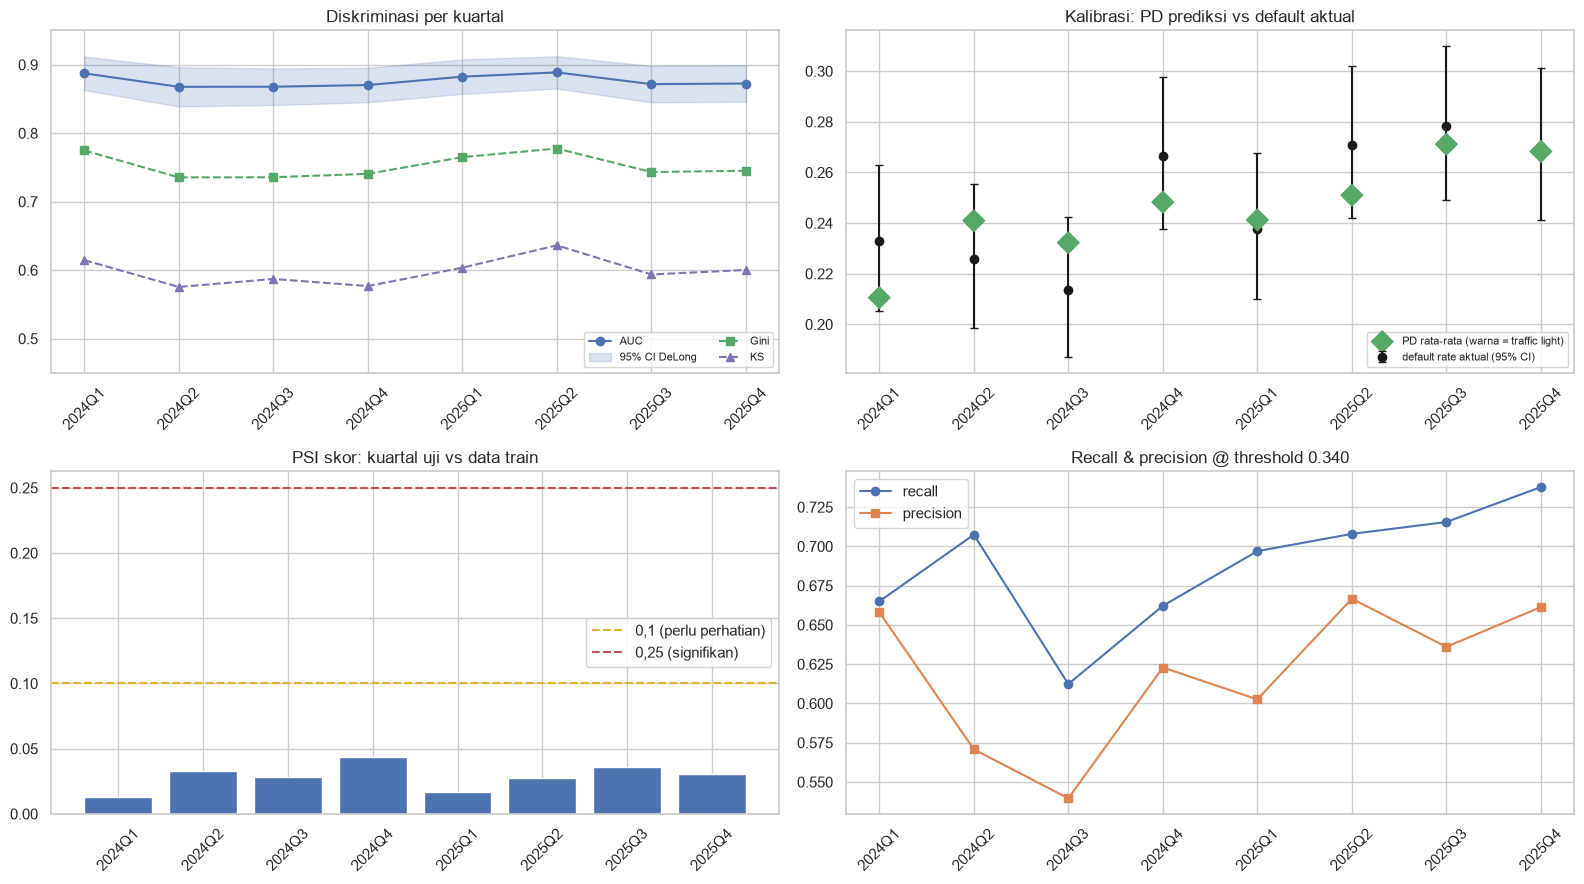

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
x = np.arange(len(walk_forward))
labels = walk_forward.index

axes[0, 0].plot(x, walk_forward["auc"], "o-", color="#4C72B0", label="AUC")
axes[0, 0].fill_between(x, walk_forward["auc_ci_lower"], walk_forward["auc_ci_upper"], alpha=0.2, color="#4C72B0", label="95% CI DeLong")
axes[0, 0].plot(x, walk_forward["gini"], "s--", color="#55A868", label="Gini")
axes[0, 0].plot(x, walk_forward["ks"], "^--", color="#8172B2", label="KS")
axes[0, 0].set_title("Diskriminasi per kuartal")
axes[0, 0].set_ylim(0.45, 0.95)
axes[0, 0].legend(loc="lower right", ncol=2, fontsize=8)

dr_ci = np.array([wilson_ci(round(r.default_rate * r.n_uji), r.n_uji) for r in walk_forward.itertuples()])
colors = walk_forward["traffic_light"].map({"green": "#55A868", "yellow": "#E1B12C", "red": "#C44E52"})
axes[0, 1].errorbar(x, walk_forward["default_rate"], yerr=[walk_forward["default_rate"] - dr_ci[:, 0], dr_ci[:, 1] - walk_forward["default_rate"]],
                    fmt="o", color="k", capsize=3, label="default rate aktual (95% CI)")
axes[0, 1].scatter(x, walk_forward["mean_pd"], s=120, marker="D", c=colors, zorder=3, label="PD rata-rata (warna = traffic light)")
axes[0, 1].set_title("Kalibrasi: PD prediksi vs default aktual")
axes[0, 1].legend(loc="lower right", fontsize=8)

axes[1, 0].bar(x, walk_forward["psi_skor"], color="#4C72B0")
axes[1, 0].axhline(0.1, color="#E1B12C", ls="--", label="0,1 (perlu perhatian)")
axes[1, 0].axhline(0.25, color="#C44E52", ls="--", label="0,25 (signifikan)")
axes[1, 0].set_title("PSI skor: kuartal uji vs data train")
axes[1, 0].legend()

axes[1, 1].plot(x, walk_forward["recall"], "o-", label="recall")
axes[1, 1].plot(x, walk_forward["precision"], "s-", label="precision")
axes[1, 1].set_title(f"Recall & precision @ threshold {BT_THRESHOLD:.3f}")
axes[1, 1].legend()
for ax in axes.ravel():
    ax.set_xticks(x, labels, rotation=45)
plt.tight_layout()
plt.show()

### 16.4 Backtest Kalibrasi per Grade Risiko (OOT)

Bank biasanya mengelompokkan PD ke dalam **grade** (master scale). Untuk setiap grade di periode OOT diuji:
- **Uji binomial**: apakah jumlah default aktual konsisten dengan PD rata-rata grade itu? (traffic light Basel)
- **Monotonisitas**: default rate harus naik dari grade A ke F (diuji dengan Spearman).

> **🔄 Alur data: Backtest Kalibrasi per Grade**
>
> - **Input:** `oot_proba`, `y_oot`.
> - **Proses:**
>   1. PD OOT dikelompokkan ke 6 grade master scale: A (<5%) … F (≥50%).
>   2. Per grade: jumlah nasabah, PD rata-rata, default rate (+ CI Wilson), default aktual vs diharapkan, **uji binomial** dua sisi, dan traffic light.
>   3. Monotonisitas diuji dengan Spearman (urutan grade vs default rate).
> - **Output:** `grade_backtest` (6 grade) + grafik. **Semua grade hijau**. Default rate naik monoton dari A 2,5% ke F 74,7% (ρ = +1,0).
> - **Berikutnya:** Cek pergeseran populasi (PSI/CSI).

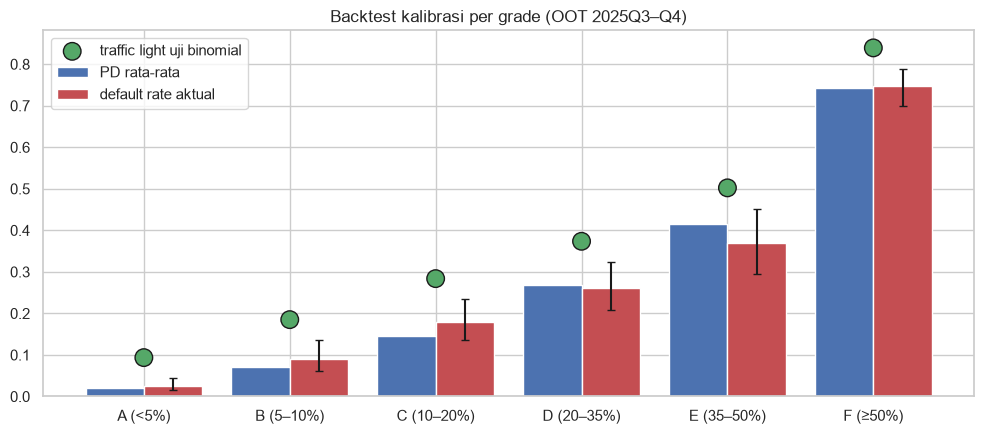

,n,porsi,pd_rata2,default_rate,dr_ci_lower,dr_ci_upper,default_aktual,default_diharapkan,binom_p,traffic_light
grade,,,,,,,,,,
A (<5%),476,0.2857,0.0208,0.0252,0.0145,0.0435,12,9.8853,0.5168,green
B (5–10%),231,0.1387,0.0711,0.0909,0.0602,0.1350,21,16.4281,0.2475,green
C (10–20%),234,0.1405,0.1449,0.1795,0.1356,0.2337,42,33.9045,0.1370,green
D (20–35%),218,0.1309,0.2686,0.2615,0.2076,0.3236,57,58.5559,0.8786,green
E (35–50%),143,0.0858,0.4159,0.3706,0.2958,0.4522,53,59.4778,0.3087,green
F (≥50%),364,0.2185,0.7435,0.7473,0.7002,0.7892,272,270.6311,0.9046,green


Monotonisitas default rate antar grade: Spearman ρ = +1.000, p = <0,001


In [45]:
PD_GRADES = {"edges": [0, 0.05, 0.10, 0.20, 0.35, 0.50, 1.0],
             "labels": ["A (<5%)", "B (5–10%)", "C (10–20%)", "D (20–35%)", "E (35–50%)", "F (≥50%)"]}
oot_grade = pd.cut(oot_proba, PD_GRADES["edges"], labels=PD_GRADES["labels"], include_lowest=True, right=False)
grade_rows = []
for g in PD_GRADES["labels"]:
    mask = np.asarray(oot_grade == g)
    if mask.sum() == 0:
        continue
    bt = binomial_backtest(int(mask.sum()), int(y_oot.values[mask].sum()), float(oot_proba[mask].mean()))
    lo, hi = wilson_ci(bt["defaults"], bt["n"])
    grade_rows.append({"grade": g, "n": bt["n"], "porsi": bt["n"] / len(y_oot), "pd_rata2": bt["mean_pd"],
                       "default_rate": bt["observed_dr"], "dr_ci_lower": lo, "dr_ci_upper": hi,
                       "default_aktual": bt["defaults"], "default_diharapkan": bt["mean_pd"] * bt["n"],
                       "binom_p": bt["p_two_sided"], "traffic_light": bt["traffic_light"]})
grade_backtest = pd.DataFrame(grade_rows).set_index("grade")
rho_grade, p_grade = stats.spearmanr(np.arange(len(grade_backtest)), grade_backtest["default_rate"])

fig, ax = plt.subplots(figsize=(10, 4.5))
xg = np.arange(len(grade_backtest))
ax.bar(xg - 0.2, grade_backtest["pd_rata2"], width=0.4, label="PD rata-rata", color="#4C72B0")
ax.bar(xg + 0.2, grade_backtest["default_rate"], width=0.4, label="default rate aktual", color="#C44E52",
       yerr=[grade_backtest["default_rate"] - grade_backtest["dr_ci_lower"], grade_backtest["dr_ci_upper"] - grade_backtest["default_rate"]], capsize=3)
tl_colors = grade_backtest["traffic_light"].map({"green": "#55A868", "yellow": "#E1B12C", "red": "#C44E52"})
marker_y = np.maximum(grade_backtest["pd_rata2"], grade_backtest["dr_ci_upper"]) + 0.05
ax.scatter(xg, marker_y, s=160, c=tl_colors, edgecolors="k", zorder=3, label="traffic light uji binomial")
ax.set_xticks(xg, grade_backtest.index)
ax.set_title("Backtest kalibrasi per grade (OOT 2025Q3–Q4)")
ax.legend()
plt.tight_layout()
plt.show()
display(grade_backtest.round(4))
print(f"Monotonisitas default rate antar grade: Spearman ρ = {rho_grade:+.3f}, p = {fmt_p(p_grade)}")

### 16.5 Stabilitas Populasi: PSI & CSI

- **PSI (Population Stability Index)** skor: membandingkan distribusi PD di OOT dengan dev.
- **CSI (Characteristic Stability Index)**: rumus yang sama, tetapi untuk **setiap fitur**. CSI menunjukkan fitur mana yang menyebabkan pergeseran.

Aturan umum industri: **< 0,1 stabil**, **0,1–0,25 perlu perhatian**, **> 0,25 bergeser signifikan** (model perlu ditinjau ulang).

> **🔄 Alur data: PSI Skor & CSI Fitur**
>
> - **Input:** `dev_score` (PD dev dari `bt_model`), `oot_proba`, `X_dev`, `X_oot`.
> - **Proses:**
>   1. **PSI skor**: PD dev dibagi 10 bin kuantil, lalu proporsi nasabah OOT per bin yang sama dihitung. PSI = Σ (%OOT − %dev) × ln(%OOT / %dev).
>   2. **CSI** dihitung dengan rumus yang sama untuk setiap fitur: numerik memakai 10 kuantil dev, kategorikal per kategori.
>   3. Persentase missing dev vs OOT juga ditampilkan.
> - **Output:** `score_psi` = **0,034**, `csi_table`. CSI tertinggi `credit_score` 0,040. Semua fitur < 0,1 (stabil).
> - **Berikutnya:** Semua bukti statistik dirangkum (Bagian 17).

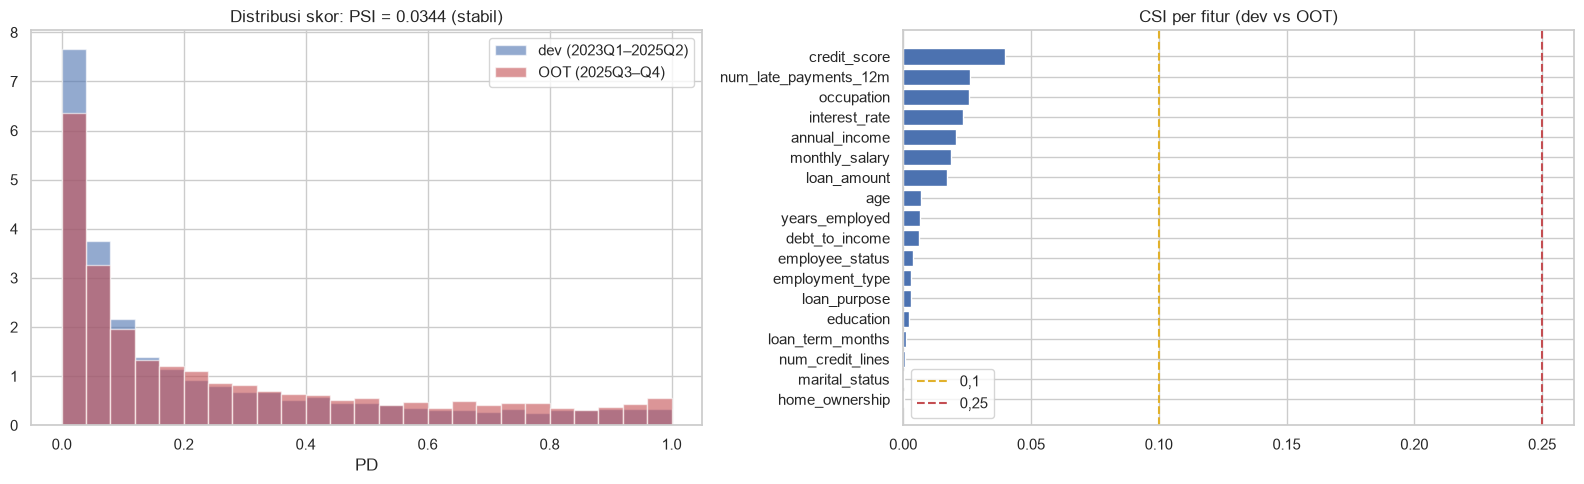

,CSI,status,missing_dev,missing_oot
fitur,,,,
credit_score,0.0398,stabil,0.0292,0.0264
num_late_payments_12m,0.0263,stabil,0.0000,0.0000
occupation,0.0257,stabil,0.0000,0.0000
interest_rate,0.0233,stabil,0.0000,0.0000
annual_income,0.0208,stabil,0.0000,0.0000
monthly_salary,0.0188,stabil,0.0281,0.0240
loan_amount,0.0173,stabil,0.0000,0.0000
age,0.0070,stabil,0.0000,0.0000
years_employed,0.0065,stabil,0.0362,0.0372


In [46]:
score_psi = psi(dev_score, oot_proba)
csi_rows = []
for col in FEATURES:
    if col in CATEGORICAL_COLS:
        value = psi_categorical(X_dev[col], X_oot[col])
    else:
        value = psi(X_dev[col].dropna(), X_oot[col].dropna())
    csi_rows.append({"fitur": col, "CSI": value, "status": stability_label(value),
                     "missing_dev": X_dev[col].isna().mean(), "missing_oot": X_oot[col].isna().mean()})
csi_table = pd.DataFrame(csi_rows).set_index("fitur").sort_values("CSI", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bins = np.linspace(0, 1, 26)
axes[0].hist(dev_score, bins=bins, density=True, alpha=0.6, label="dev (2023Q1–2025Q2)", color="#4C72B0")
axes[0].hist(oot_proba, bins=bins, density=True, alpha=0.6, label="OOT (2025Q3–Q4)", color="#C44E52")
axes[0].set_title(f"Distribusi skor: PSI = {score_psi:.4f} ({stability_label(score_psi)})")
axes[0].set_xlabel("PD")
axes[0].legend()
axes[1].barh(csi_table.index, csi_table["CSI"], color="#4C72B0")
axes[1].axvline(0.1, color="#E1B12C", ls="--", label="0,1")
axes[1].axvline(0.25, color="#C44E52", ls="--", label="0,25")
axes[1].invert_yaxis()
axes[1].set_title("CSI per fitur (dev vs OOT)")
axes[1].legend()
plt.tight_layout()
plt.show()
display(csi_table.round(4))

### Interpretasi Backtesting

**16.1 Populasi berubah: default rate naik secara signifikan**
- Default rate naik dari **15,9%** (2023Q1) ke **27–28%** (2025Q3–Q4). Tren ini signifikan (Spearman ρ = +0,92, p < 0,001), dan uji χ² menolak bahwa default rate semua kuartal sama (χ² = 66,9, p < 0,001).
- Penyebabnya terlihat di profil pemohon: rata-rata credit score turun **710 → 679**, porsi pekerja gig/retail/unemployed naik **21% → 30%**, dan median gaji turun 8,5 → 7,7 jt. Ini adalah **covariate shift**: populasinya yang berubah.

**16.2 Out-of-time: performa bertahan**
- AUC OOT **0,871** (CI 0,850–0,890) vs in-time 0,884. Turun 0,013, tetapi **tidak signifikan** (z = −1,20, p = 0,23). Gini 0,742 dan KS 0,590 tetap di level “sangat baik”.
- PR-AUC dan recall OOT justru **naik**. Ini **bukan** bukti model membaik: PR-AUC bergantung pada prevalensi, dan prevalensi OOT lebih tinggi (27,4% vs 22,2%). Brier yang naik (0,106 → 0,122) juga sebagian karena prevalensi, sebab batas atas Brier = p(1−p) ikut naik.
- **Kalibrasi OOT 🟢**: 457 default aktual vs 449 diharapkan (PD 0,269 vs DR 0,274, p = 0,66). Model dilatih pada data dev dengan default rate 22,2%, tetapi secara otomatis memberi PD lebih tinggi (26,9%) di OOT karena profil pemohonnya memang lebih buruk. Jadi kenaikan default rate **dijelaskan oleh fitur**, dan modelnya tidak perlu diubah.

**16.3 Walk-forward: tidak ada degradasi**
- AUC di 8 kuartal: **0,868–0,889** (rata-rata 0,876, CI 0,869–0,883). Tidak ada tren menurun (slope −0,0001/kuartal, p = 0,94).
- Uji binomial: **8/8 kuartal hijau**, dan PD rata-rata mengikuti kenaikan default rate dari kuartal ke kuartal.
- PSI skor per kuartal 0,013–0,044, semuanya **stabil**.

**16.4 Kalibrasi per grade**
- **Semua 6 grade hijau**. Default rate naik **monoton** dari A (2,5%) ke F (74,7%) dengan Spearman ρ = +1,0, jadi master scale berfungsi.
- Grade A mencakup 28,6% portofolio OOT dengan default rate hanya 2,5%, kandidat untuk *fast-track approval*.
- Grade B–C sedikit *under-predict* (C: PD 14,5% vs aktual 18,0%, p = 0,14). Ini masih hijau tetapi sejalan dengan desil ke-7 di Bagian 14.4, jadi **layak dipantau**.

**16.5 Stabilitas**
- PSI skor dev → OOT **0,034**. CSI tertinggi ada di `credit_score` (0,040). **Semua fitur < 0,1** (stabil).
- Pergeseran di 16.1 **signifikan secara statistik** (χ² p < 0,001) tetapi **kecil secara distribusi** (PSI < 0,1). Perbedaan antara “signifikan” dan “material” ini penting: dengan sampel besar, perubahan kecil pun signifikan.

**Batasan backtest ini**
1. Hyperparameter `best_model` dipilih dari split acak yang mencakup periode OOT (sedikit *look-ahead*). Karena hasil nested CV menunjukkan performa tidak sensitif terhadap hyperparameter, dampaknya minimal.
2. Data sintetis hanya mengandung **covariate shift**. Di data nyata bisa terjadi **concept drift**, yaitu hubungan fitur → default berubah, misalnya karena krisis ekonomi. Concept drift akan muncul sebagai lampu kuning/merah di uji binomial **walaupun PSI stabil**. Karena itu keduanya harus dimonitor bersama.
3. Label default di data nyata butuh waktu untuk *matang* (mis. 12 bulan sejak pencairan). Backtest di produksi harus memakai vintage yang sudah matang.

## 17. Ringkasan Evaluasi Statistik & Kesimpulan

Tabel berikut merangkum **semua bukti statistik** dari Bagian 4–16 dalam satu tempat. Setiap baris berisi nilai, confidence interval (jika ada), patokan yang dipakai, dan status ✅ (memenuhi) / ⚠️ (perlu perhatian) / ❌ (tidak memenuhi). Ringkasan ini juga disimpan ke `model.json` (`metadata.evaluation`) agar ikut terdokumentasi bersama model.

> **🔄 Alur data: Ringkasan Evaluasi Statistik**
>
> - **Input:** Hasil dari Bagian 4, 10, 14, dan 16 (`num_tests`, `cat_tests`, `iv_summary`, `vif_table`, `rep_summary`, `nested`, `learning`, `cv_tests`, `final_ci`, `dl`, `mc`, `hl`, `cal`, `walk_forward`, `grade_backtest`, `csi_table`, dll.).
> - **Proses:**
>   1. Setiap bukti dibandingkan dengan patokan (mis. Gini > 0,5; HL p > 0,05; PSI < 0,1) dan diberi status ✅ / ⚠️ / ❌.
>   2. Semua baris disusun menjadi tabel `evaluation_summary`.
>   3. Angka kunci dikemas ke `EVALUATION_FOR_METADATA` (dict, semua float) untuk disimpan di `model.json`.
> - **Output:** `evaluation_summary` (24 baris): **22 ✅, 2 ⚠️, 0 ❌**. `EVALUATION_FOR_METADATA` siap disimpan.
> - **Berikutnya:** Model + ringkasan evaluasi diekspor ke JSON (Bagian 18).

In [47]:
def verdict(ok: bool, warn: bool = False) -> str:
    return "✅" if ok else ("⚠️" if warn else "❌")


best_rep = rep_summary.loc[(best_name, "roc_auc")]
ks_ci = final_ci.loc["ks"]
gini_ci = final_ci.loc["gini"]
cv_p = cv_tests.loc["Corrected resampled t-test (utama)", "p_value"]
n_red = int((walk_forward["traffic_light"] == "red").sum())
n_yellow = int((walk_forward["traffic_light"] == "yellow").sum())
max_csi = csi_table["CSI"].max()
max_csi_feature = csi_table["CSI"].idxmax()

rows = [
    ("Data", "Fitur signifikan (Holm, α=5%)", f"{(num_tests['p_holm'] < 0.05).sum() + (cat_tests['p_holm'] < 0.05).sum()} dari {len(FEATURES)}", "", "mayoritas signifikan", verdict(True)),
    ("Data", "Fitur IV ≥ 0,1 (sedang–kuat)", f"{(iv_summary['IV'] >= 0.1).sum()} fitur", "", "ada fitur kuat", verdict((iv_summary['IV'] >= 0.1).sum() > 0)),
    ("Data", "VIF maksimum", f"{vif_table['VIF'].max():.1f} ({vif_table['VIF'].idxmax()})", "", "< 10", verdict(vif_table['VIF'].max() < 10, warn=True)),
    ("Cross-validation", "Repeated CV ROC-AUC (25 skor)", f"{best_rep['mean']:.4f} ± {best_rep['std']:.4f}", f"{best_rep['ci95_lower']:.4f}–{best_rep['ci95_upper']:.4f}", "std < 0,02 (stabil)", verdict(best_rep['std'] < 0.02)),
    ("Cross-validation", "Nested CV ROC-AUC", f"{nested_mean:.4f}", f"{nested_lo:.4f}–{nested_hi:.4f}", "≈ CV biasa", verdict(abs(optimism) < 0.01, warn=True)),
    ("Cross-validation", "Optimisme tuning", f"{optimism:+.4f}", "", "|x| < 0,01", verdict(abs(optimism) < 0.01, warn=True)),
    ("Cross-validation", "Gap train–validasi (learning curve)", f"{learning['gap'].iloc[-1]:.4f}", "", "< 0,03 (tidak overfit)", verdict(learning['gap'].iloc[-1] < 0.03, warn=True)),
    ("Pemilihan model", f"{name_a} vs {name_b} (corrected t-test)", f"Δ AUC {corrected['mean_diff']:+.4f}", f"p = {cv_p:.4f}", "p < 0,05", verdict(cv_p < 0.05, warn=True)),
    ("Pemilihan model", f"{best_name} vs {other_name} di test (DeLong)", f"Δ AUC {dl['diff']:+.4f}", f"p = {dl['p_value']:.4f}", "p < 0,05", verdict(dl['p_value'] < 0.05, warn=True)),
    ("Diskriminasi (test)", "ROC-AUC", f"{auc_point:.4f}", f"{auc_lo:.4f}–{auc_hi:.4f}", "> 0,75", verdict(auc_lo > 0.75)),
    ("Diskriminasi (test)", "Gini", f"{gini_ci['estimate']:.4f}", f"{gini_ci['ci_lower']:.4f}–{gini_ci['ci_upper']:.4f}", "> 0,5 baik, > 0,6 sangat baik", verdict(gini_ci['ci_lower'] > 0.5)),
    ("Diskriminasi (test)", "KS", f"{ks_ci['estimate']:.4f}", f"{ks_ci['ci_lower']:.4f}–{ks_ci['ci_upper']:.4f}", "> 0,4", verdict(ks_ci['ci_lower'] > 0.4, warn=ks_ci['estimate'] > 0.4)),
    ("Diskriminasi (test)", "PR-AUC vs baseline", f"{final_ci.loc['pr_auc', 'estimate']:.4f} vs {y_test.mean():.3f}", f"{final_ci.loc['pr_auc', 'ci_lower']:.4f}–{final_ci.loc['pr_auc', 'ci_upper']:.4f}", "> 2× baseline", verdict(final_ci.loc['pr_auc', 'ci_lower'] > 2 * y_test.mean())),
    ("Kalibrasi (test)", "Brier Skill Score", f"{BSS:.4f}", "", "> 0", verdict(BSS > 0)),
    ("Kalibrasi (test)", "Hosmer-Lemeshow", f"χ² = {hl['statistic']:.2f}", f"p = {hl['p_value']:.4f}", "p > 0,05", verdict(hl['p_value'] > 0.05, warn=hl['p_value'] > 0.01)),
    ("Kalibrasi (test)", "Calibration slope", f"{cal['slope']:.3f}", "", "0,9–1,1", verdict(0.9 <= cal['slope'] <= 1.1, warn=0.8 <= cal['slope'] <= 1.2)),
    ("Backtest", "AUC OOT (2025Q3–Q4)", f"{auc_oot:.4f}", f"{lo_oot:.4f}–{hi_oot:.4f}", "turun < 0,03 vs in-time", verdict(auc_dev - auc_oot < 0.03, warn=auc_dev - auc_oot < 0.05)),
    ("Backtest", "Perubahan AUC in-time → OOT", f"{auc_oot - auc_dev:+.4f}", f"p = {p_auc_drift:.4f}", "tidak signifikan", verdict(p_auc_drift > 0.05, warn=True)),
    ("Backtest", "Kalibrasi OOT (binomial)", f"PD {oot_binom['mean_pd']:.3f} vs DR {oot_binom['observed_dr']:.3f}", f"p = {oot_binom['p_two_sided']:.4f}", "traffic light hijau", verdict(oot_binom['traffic_light'] == 'green', warn=oot_binom['traffic_light'] == 'yellow')),
    ("Backtest", "Walk-forward AUC (8 kuartal)", f"{wf_auc_mean:.4f} (min {walk_forward['auc'].min():.4f})", f"{wf_auc_lo:.4f}–{wf_auc_hi:.4f}", "semua > 0,75", verdict(walk_forward['auc'].min() > 0.75)),
    ("Backtest", "Walk-forward traffic light", f"🟢 {len(walk_forward) - n_red - n_yellow} | 🟡 {n_yellow} | 🔴 {n_red}", "", "tidak ada merah", verdict(n_red == 0 and n_yellow == 0, warn=n_red == 0)),
    ("Backtest", "Monotonisitas grade (OOT)", f"ρ = {rho_grade:+.3f}", f"p = {p_grade:.4f}", "ρ > 0 signifikan", verdict(rho_grade > 0.8)),
    ("Stabilitas", "PSI skor dev → OOT", f"{score_psi:.4f}", "", "< 0,1", verdict(score_psi < 0.1, warn=score_psi < 0.25)),
    ("Stabilitas", "CSI maksimum", f"{max_csi:.4f} ({max_csi_feature})", "", "< 0,1", verdict(max_csi < 0.1, warn=max_csi < 0.25)),
]
evaluation_summary = pd.DataFrame(rows, columns=["aspek", "pengujian", "nilai", "CI / p-value", "patokan", "status"])
display(evaluation_summary.set_index(["aspek", "pengujian"]))
print("Rekap status:", evaluation_summary["status"].value_counts().to_dict())

EVALUATION_FOR_METADATA = {
    "repeated_cv_auc": {"mean": float(best_rep["mean"]), "std": float(best_rep["std"]),
                        "ci95": [float(best_rep["ci95_lower"]), float(best_rep["ci95_upper"])]},
    "nested_cv_auc": {"mean": float(nested_mean), "ci95": [float(nested_lo), float(nested_hi)], "optimism": float(optimism)},
    "model_comparison": {"corrected_ttest_p": float(cv_p), "delong_test_p": float(dl["p_value"]), "mcnemar_p": float(mc["p_value"])},
    "test_ci95": {m: [float(final_ci.loc[m, "ci_lower"]), float(final_ci.loc[m, "ci_upper"])] for m in ["roc_auc", "gini", "ks", "pr_auc", "recall", "precision"]},
    "calibration": {"brier": float(brier), "brier_skill_score": float(BSS), "hosmer_lemeshow_p": float(hl["p_value"]),
                    "slope": float(cal["slope"]), "intercept": float(cal["intercept"])},
    "backtest": {"oot_period": f"{OOT_START}–{df_bt['quarter'].max()}", "oot_auc": float(auc_oot), "oot_auc_ci95": [float(lo_oot), float(hi_oot)],
                 "intime_auc": float(auc_dev), "oot_binomial_p": float(oot_binom["p_two_sided"]), "oot_traffic_light": oot_binom["traffic_light"],
                 "walk_forward_auc_mean": float(wf_auc_mean), "walk_forward_auc_min": float(walk_forward["auc"].min()),
                 "walk_forward_traffic_lights": {k: int(v) for k, v in walk_forward["traffic_light"].value_counts().items()},
                 "score_psi": float(score_psi), "max_csi": {"feature": max_csi_feature, "value": float(max_csi)}},
    "cost_threshold_5to1": float(COST_THRESHOLD),
}

nilai  \
aspek               pengujian                                                                        
Data                Fitur signifikan (Holm, α=5%)                                       15 dari 18   
                    Fitur IV ≥ 0,1 (sedang–kuat)                                           9 fitur   
                    VIF maksimum                                              25.5 (annual_income)   
Cross-validation    Repeated CV ROC-AUC (25 skor)                                  0.8812 ± 0.0060   
                    Nested CV ROC-AUC                                                       0.8808   
                    Optimisme tuning                                                       +0.0010   
                    Gap train–validasi (learning curve)                                     0.0057   
Pemilihan model     logistic_regression vs random_forest (corrected t-test)          Δ AUC +0.0048   
                    logistic_regression vs random_forest di test (DeLong)            Δ AUC +0.0058   
Diskriminasi (test) ROC-AUC                                                                 0.8839   
                    Gini                                                                    0.7678   
                    KS                                                                      0.6098   
                    PR-AUC vs baseline                                             0.7220 vs 0.231   
Kalibrasi (test)    Brier Skill Score                                                       0.3840   
                    Hosmer-Lemeshow                                                     χ² = 11.73   
                    Calibration slope                                                        0.974   
Backtest            AUC OOT (2025Q3–Q4)                                                     0.8711   
                    Perubahan AUC in-time → OOT                                            -0.0126   
                    Kalibrasi OOT (binomial)                                  PD 0.269 vs DR 0.274   
                    Walk-forward AUC (8 kuartal)                               0.8761 (min 0.8677)   
                    Walk-forward traffic light                                     🟢 8 | 🟡 0 | 🔴 0   
                    Monotonisitas grade (OOT)                                           ρ = +1.000   
Stabilitas          PSI skor dev → OOT                                                      0.0344   
                    CSI maksimum                                             0.0398 (credit_score)   

                                                                              CI / p-value  \
aspek               pengujian                                                                
Data                Fitur signifikan (Holm, α=5%)                                            
                    Fitur IV ≥ 0,1 (sedang–kuat)                                             
                    VIF maksimum                                                             
Cross-validation    Repeated CV ROC-AUC (25 skor)                            0.8746–0.8879   
                    Nested CV ROC-AUC                                        0.8635–0.8982   
                    Optimisme tuning                                                         
                    Gap train–validasi (learning curve)                                      
Pemilihan model     logistic_regression vs random_forest (corrected t-test)     p = 0.0161   
                    logistic_regression vs random_forest di test (DeLong)       p = 0.0620   
Diskriminasi (test) ROC-AUC                                                  0.8675–0.9003   
                    Gini                                                     0.7364–0.8005   
                    KS                                                       0.5808–0.6514   
                    PR-AUC vs baseline                                       0.6861–0.7579   
Kalibrasi (test)    Brier Skil

Rekap status: {'✅': 22, '⚠️': 2}


### Kesimpulan Akhir

**Hasil: 22 ✅ · 2 ⚠️ · 0 ❌**

**1. Model layak dipakai**, didukung bukti dari 4 sisi:

| Sisi | Bukti utama |
|---|---|
| **Diskriminasi** | Gini 0,77 (CI 0,74–0,80), KS 0,61 (CI 0,58–0,65): batas bawah CI pun “sangat baik” |
| **Kalibrasi** | PD 22,6% vs DR 23,1%; Hosmer-Lemeshow p = 0,16; slope 0,97; BSS 0,38 |
| **Stabilitas & reliabilitas** | Repeated CV std 0,006; optimisme nested CV hanya 0,001; gap learning curve 0,006 |
| **Ketahanan terhadap waktu** | AUC OOT 0,871 (turun tidak signifikan, p = 0,23); walk-forward 8/8 hijau tanpa tren menurun; PSI 0,034 |

**2. Dua catatan ⚠️ (tidak menghalangi, tetapi perlu diketahui)**
- **VIF gaji–pendapatan = 25.** Ini hanya memengaruhi interpretasi koefisien, bukan prediksi.
- **LR vs RF tidak signifikan di test set** (p = 0,062), walaupun signifikan di repeated CV (p = 0,016). Selisihnya kecil. LR dipilih karena sedikit lebih baik, lebih terkalibrasi, mudah diaudit, dan jauh lebih ringan.

**3. Rekomendasi sebelum dan sesudah produksi**
1. **Tetapkan threshold bersama tim risk** berdasarkan biaya nyata (LGD × EAD vs margin). Contoh rasio 5:1 menghasilkan threshold 0,15 (approval 58%, bad rate 4,5%). Threshold F1 0,30 lebih longgar (approval 73%, bad rate 9,1%).
2. **Monitoring bulanan** dengan patokan yang sama seperti backtest ini:
   - PSI skor & CSI fitur: alarm di 0,1 (investigasi) dan 0,25 (tinjau ulang model).
   - Uji binomial per grade: kuning/merah 2 periode berturut-turut → **rekalibrasi** intercept.
   - AUC/Gini pada vintage yang sudah matang: turun > 0,03 atau Gini < 0,6 → **retrain**.
3. **Sederhanakan untuk audit (opsional):** buang salah satu dari pasangan gaji/pendapatan dan fitur dengan IV < 0,02 serta permutation importance ≈ 0 (`education`, `marital_status`, `loan_purpose`), lalu ulangi seluruh prosedur evaluasi notebook ini untuk memastikan performanya tidak turun.
4. **Validasi dengan data riil.** Data di proyek ini sintetis. Model kredit nyata juga memerlukan *reject inference* (label hanya ada untuk nasabah yang disetujui), pengujian *fairness* antar segmen, uji concept drift, dan validasi independen oleh fungsi *model risk management*.

## 18. Simpan Model dalam Format JSON

Seluruh pipeline diekspor ke **satu file `models/model.json`** oleh `src/json_model.py`, bukan pickle/joblib. Isinya:

| Bagian | Isi |
|---|---|
| `metadata` | nama model, versi, fitur, kategori valid, threshold, metrik CV & test, versi library |
| `preprocessing` | parameter setiap langkah: batas bin domain, batas bin kuantil, nilai imputasi, mean/scale, daftar kategori one-hot |
| `feature_names_out` | 64 nama kolom hasil transformasi (urutan input model) |
| `model` | Logistic Regression: `coef` + `intercept`; Random Forest: struktur setiap pohon |

**Kenapa JSON?**
- **Aman**: tidak mengeksekusi kode saat di-load (pickle bisa menjalankan kode berbahaya)
- **Portable**: tidak terikat versi scikit-learn/Python, dan bisa dibaca bahasa lain (Java, Go, JS)
- **Transparan**: bisa dibaca dan di-diff, cocok untuk audit model kredit oleh tim risk/regulator
- **API lebih ringan**: inferensi cukup numpy + pandas, tanpa scikit-learn

> **🔄 Alur data: Ekspor Model ke JSON**
>
> - **Input:** `best_model` (sudah di-fit) + hasil-hasil sebelumnya (`THRESHOLD`, `cv_summary`, `test_summary`, `searches`).
> - **Proses:**
>   1. Menyusun `metadata`: nama & versi model, 18 fitur, kategori valid, threshold, metrik CV & test, versi library, dan **`evaluation`** (ringkasan uji statistik & backtest dari Bagian 17).
>   2. `export_pipeline()` membaca **parameter yang sudah dipelajari** dari setiap langkah pipeline: batas bin, median imputasi, mean/std scaler, daftar kategori one-hot, `coef_`/`intercept_`.
>   3. `save_json()` menulis semuanya ke satu file.
> - **Output:** `model_json` (dict di memori) dan file **`models/model.json` (±11 KB)**.
> - **Berikutnya:** Isi file diperiksa.

In [48]:
cat_encoder = best_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
now = datetime.now(timezone.utc)
metadata = {
    "model_name": best_name,
    "model_version": now.strftime("%Y%m%d%H%M%S"),
    "trained_at": now.isoformat(timespec="seconds"),
    "features": FEATURES,
    "numeric_features": list(DOMAIN_BINS) + QUANTILE_BIN_COLS + NUMERIC_COLS,
    "categorical_features": {
        col: [c for c in cats.tolist() if c != "missing"] for col, cats in zip(CATEGORICAL_COLS, cat_encoder.categories_)
    },
    "n_features_after_preprocessing": int(len(feat_names)),
    "target": TARGET,
    "labels": {str(k): v for k, v in LABELS.items()},
    "threshold": THRESHOLD,
    "best_params": best_search.best_params_,
    "selection_metric": PRIMARY_METRIC,
    "compared_models": {name: round(float(gs.best_score_), 4) for name, gs in searches.items()},
    "cv_metrics": {k.replace("cv_", ""): round(float(v), 4) for k, v in cv_summary.loc[best_name].items() if not k.endswith("_std")},
    "test_metrics": {k: round(float(v), 4) for k, v in test_summary.iloc[-1].items()},
    "evaluation": EVALUATION_FOR_METADATA,
    "library_versions": {
        "python": platform.python_version(),
        "scikit-learn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
    },
}

model_json = export_pipeline(best_model, metadata)
model_path = MODEL_DIR / "model.json"
save_json(model_json, model_path)

print(f"Model JSON -> {model_path} ({model_path.stat().st_size / 1024:.1f} KB)")
print("Bagian file:", list(model_json))
print(json.dumps({k: metadata[k] for k in ["model_name", "threshold", "cv_metrics", "test_metrics"]}, indent=2))

Model JSON -> /Users/ikhsannur1996/Documents/data-science/credit_classification/models/model.json (11.0 KB)
Bagian file: ['format', 'format_version', 'metadata', 'preprocessing', 'feature_names_out', 'model']
{
  "model_name": "logistic_regression",
  "threshold": 0.302,
  "cv_metrics": {
    "roc_auc": 0.8819,
    "average_precision": 0.7255,
    "f1": 0.6199,
    "recall": 0.5384,
    "precision": 0.7308
  },
  "test_metrics": {
    "roc_auc": 0.8839,
    "pr_auc": 0.722,
    "f1": 0.6554,
    "recall": 0.7143,
    "precision": 0.6055,
    "accuracy": 0.8265
  }
}


### Isi `model.json`

> **🔄 Alur data: Isi model.json**
>
> - **Input:** `model_json`.
> - **Proses:**
>   1. Mencetak ringkasan tiap blok preprocessing dan bagian `model`.
> - **Output:** Terlihat parameter yang dipelajari dari `X_train`, mis. median `annual_income` = 118,6 (pengisi jika kosong), batas bin gaji, batas kuantil pendapatan, mean & std 7 kolom numerik, kategori one-hot (`education` punya kategori `missing`).
> - **Berikutnya:** Bobot model ditampilkan sebagai tabel.

In [49]:
for step in model_json["preprocessing"]:
    detail = {k: v for k, v in step.items() if k not in ("name", "type", "columns")}
    print(f"[{step['name']}] {step['type']} -> {step['columns']}")
    print("   ", json.dumps(detail)[:300], "...\n" if len(json.dumps(detail)) > 300 else "\n")

print("model:", json.dumps(model_json["model"])[:400], "...")

[domain_bin] domain_bin_onehot -> ['age', 'credit_score', 'monthly_salary']
    {"bins": {"age": {"edges": [null, 25.0, 35.0, 45.0, 55.0, null], "labels": ["18-25", "26-35", "36-45", "46-55", "56+"]}, "credit_score": {"edges": [null, 579.0, 669.0, 739.0, 799.0, null], "labels": ["poor", "fair", "good", "very_good", "excellent"]}, "monthly_salary": {"edges": [null, 0.0, 3.5, 5.0 ...

[quantile_bin] quantile_bin_onehot -> ['annual_income']
    {"impute_values": [118.6], "bin_edges": [[1.1, 72.25, 102.9, 136.6, 192.6, 1771.9]]} 

[num] impute_standard_scale -> ['years_employed', 'debt_to_income', 'num_credit_lines', 'num_late_payments_12m', 'loan_amount', 'loan_term_months', 'interest_rate']
    {"impute_values": [5.5, 0.287, 5.0, 0.0, 70.7, 36.0, 12.88], "mean": [7.301725, 0.30570549999999996, 4.98575, 0.7875, 92.83043750000002, 37.857, 12.89317125], "scale": [6.858865760778162, 0.14425941050673263, 1.9882899530752551, 1.214225576241911, 87.69956898302632, 14.808225788392074, 2.326772266

> **🔄 Alur data: Bobot Model dari JSON**
>
> - **Input:** `model_json['feature_names_out']` dan `model_json['model']['coef']`.
> - **Proses:**
>   1. Memasangkan 64 nama kolom dengan 64 koefisien, lalu diurutkan.
> - **Output:** Tabel 15 koefisien terbesar, sama dengan grafik interpretasi di Bagian 15 karena sumbernya sama.
> - **Berikutnya:** Membuktikan bahwa file JSON menghasilkan prediksi yang sama.

In [50]:
# Bobot model per kolom hasil transformasi (sumber yang sama dengan file JSON)
if model_json["model"]["type"] == "logistic_regression":
    weights = pd.DataFrame({"feature": model_json["feature_names_out"], "coef": model_json["model"]["coef"]})
    display(weights.sort_values("coef", key=abs, ascending=False).head(15).round(4))

,feature,coef
5,domain_bin__credit_score_bin_excellent,-2.9290
9,domain_bin__credit_score_bin_poor,2.2027
17,domain_bin__monthly_salary_bin_no_salary,-1.8643
38,cat__occupation_unemployed,1.3087
41,cat__employment_type_unemployed,1.3087
40,cat__employment_type_self_employed,-1.0900
10,domain_bin__credit_score_bin_very_good,-0.9527
6,domain_bin__credit_score_bin_fair,0.8809
39,cat__employment_type_salaried,-0.6928
26,num__num_late_payments_12m,0.6884


## 19. Validasi: Model JSON Harus Identik dengan Pipeline scikit-learn

`JsonModel` melakukan ulang semua langkah (binning, one-hot, imputasi, scaling, prediksi) hanya dengan numpy/pandas. Hasilnya dicek terhadap pipeline asli di seluruh test set, ditambah kasus khusus: nilai kosong dan kategori yang tidak dikenal.

> **🔄 Alur data: Validasi Model JSON**
>
> - **Input:** File `models/model.json` (dibaca ulang dari disk), `X_test`, `best_model`.
> - **Proses:**
>   1. `JsonModel` mengulang semua langkah (binning, one-hot, imputasi, scaling, sigmoid) **hanya dengan numpy/pandas**.
>   2. Dibandingkan dengan pipeline scikit-learn: (1) 64 kolom hasil transformasi, (2) probabilitas, (3) 50 baris kasus khusus: `credit_score`/`years_employed`/`monthly_salary`/`education` dikosongkan dan `loan_purpose` diganti kategori tak dikenal `wedding`.
> - **Output:** Selisih maksimum **0** di ketiga uji. Prediksi kelas identik dengan `y_pred`.
> - **Berikutnya:** `model.json` terbukti aman dipakai API sebagai pengganti pipeline scikit-learn.

In [51]:
json_model = JsonModel.load(model_path)

# 1) Transformasi fitur identik
diff_transform = np.abs(json_model.transform(X_test) - best_model.named_steps["preprocess"].transform(X_test)).max()
# 2) Probabilitas identik
diff_proba = np.abs(json_model.predict_proba(X_test) - best_model.predict_proba(X_test)).max()
# 3) Kasus khusus: semua nilai opsional kosong + kategori tak dikenal
edge = X_test.head(50).copy()
edge[["credit_score", "years_employed", "monthly_salary", "education"]] = np.nan
edge["loan_purpose"] = "wedding"
diff_edge = np.abs(json_model.predict_proba(edge) - best_model.predict_proba(edge)).max()

print(f"Max selisih transformasi : {diff_transform:.2e}")
print(f"Max selisih probabilitas : {diff_proba:.2e}")
print(f"Max selisih kasus khusus : {diff_edge:.2e}")
assert max(diff_transform, diff_proba, diff_edge) < 1e-9, "Model JSON tidak identik dengan pipeline!"
assert np.array_equal(json_model.predict(X_test), y_pred), "Prediksi kelas berbeda!"
print("✅ Model JSON identik dengan pipeline scikit-learn")

Max selisih transformasi : 0.00e+00
Max selisih probabilitas : 0.00e+00
Max selisih kasus khusus : 0.00e+00
✅ Model JSON identik dengan pipeline scikit-learn


### Contoh Request API

> **🔄 Alur data: Buat Contoh Request API**
>
> - **Input:** `X_test`, `test_proba`, `json_model`.
> - **Proses:**
>   1. Mengambil nasabah test dengan P(default) tertinggi dan terendah.
>   2. `to_payload` mengubah 1 baris jadi dict JSON: `NaN` → `null`, tipe numpy → tipe Python.
>   3. Menulis file contoh request, lalu memprediksi ulang **dari dict** memakai `JsonModel`, persis seperti yang dilakukan API.
> - **Output:** File `sample_request.json` (1 nasabah) dan `sample_batch_request.json` (2 nasabah). P(default) = 0,9962 → DEFAULT (nasabah *unemployed*, skor kredit 492, 5× telat bayar) dan 0,0003 → NO DEFAULT.
> - **Berikutnya:** File-file ini dipakai untuk mencoba API (`curl ... -d @sample_request.json`) dan di unit test.

In [52]:
def to_payload(row: pd.Series) -> dict:
    # NaN -> None agar valid sebagai JSON
    return {k: (None if pd.isna(v) else (v.item() if hasattr(v, "item") else v)) for k, v in row.items()}


test_proba_s = pd.Series(test_proba, index=X_test.index)
high_risk = X_test.loc[test_proba_s.idxmax()]
low_risk = X_test.loc[test_proba_s.idxmin()]

(PROJECT_DIR / "sample_request.json").write_text(json.dumps(to_payload(high_risk), indent=2))
(PROJECT_DIR / "sample_batch_request.json").write_text(
    json.dumps({"instances": [to_payload(high_risk), to_payload(low_risk)]}, indent=2)
)

for label, row in [("risiko tinggi", high_risk), ("risiko rendah", low_risk)]:
    p = json_model.predict_proba(pd.DataFrame([to_payload(row)]))[0, 1]
    print(f"Sampel {label:<14} -> P(default) = {p:.4f} -> {'DEFAULT' if p >= THRESHOLD else 'NO DEFAULT'}")

Sampel risiko tinggi  -> P(default) = 0.9962 -> DEFAULT
Sampel risiko rendah  -> P(default) = 0.0003 -> NO DEFAULT


## 20. Langkah Berikutnya: Serving via API

```bash
# lokal
uvicorn app.main:app --reload

# Docker
docker build -t credit-default-api .
docker run -d -p 8000:8000 --name credit-default-api credit-default-api
```

Buka **http://localhost:8000/docs**, atau:

```bash
curl -X POST http://localhost:8000/predict -H "Content-Type: application/json" -d @sample_request.json
```

Panduan lengkap ada di `README.md`.

### Alur data di dalam API (`app/main.py`)

Saat API menerima request, data melewati langkah yang **sama persis** dengan Bagian 6, tetapi memakai parameter dari `model.json`:

```
Request JSON (18 field)
   │ 1. Pydantic (app/schemas.py): cek field lengkap, tipe, rentang (mis. credit_score 300–850),
   │    kategori valid, konsistensi pekerjaan (unemployed ⇔ unemployed, employee_status hanya
   │    untuk salaried); field asing ditolak → kalau gagal: HTTP 422
   ▼
DataFrame 1 baris (n baris untuk /predict/batch), urutan kolom = metadata.features
   │ 2. null → NaN
   ▼
JsonModel.transform (src/json_model.py)
   │ 3. binning age, credit_score & monthly_salary → one-hot   (batas dari model.json)
   │ 4. isi NaN annual_income (median 118,6) → bin kuantil → one-hot
   │ 5. isi NaN numerik (median) → (x − mean) / std
   │ 6. isi NaN kategori ('missing') → one-hot; kategori tak dikenal → semua 0
   ▼
Matriks 1 × 64
   │ 7. z = X · coef + intercept ;  p = 1 / (1 + e^(−z))
   ▼
p = P(default)
   │ 8. prediction = p ≥ 0,302 ; risk_band: high (≥ threshold), medium (≥ threshold/2), low
   ▼
Response: {"prediction", "label", "probability_default", "risk_band", "threshold"}
```

**Siklus berikutnya:** data baru masuk → jalankan ulang notebook (*Run All*) → `model.json` baru (versi berubah) → restart/rebuild API. Kode API tidak perlu diubah selama 18 kolom inputnya sama.